In [22]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import uproot3 as uproot
import pandas as pd
import numpy as np
import math
from tqdm import tqdm

import xgboost as xgb

import kdar_functions as kdar
import general_functions as utils

import importlib



In [23]:
importlib.reload(kdar)
importlib.reload(utils)

<module 'general_functions' from '/Users/bbogart/Documents/analysisCode/kdar_bdt/general_functions.py'>

In [24]:
single_run = False

more_gibuu = True


In [26]:

model_hiE = xgb.Booster({'nthread': 4})  # init model
model_hiE.load_model('model_hiE_1.json')  # load data

model_lowE = xgb.Booster({'nthread': 4})  # init model
model_lowE.load_model('model_lowE_1.json')  # load data

model_hiE_genie_only = xgb.Booster({'nthread': 4})  # init model
model_hiE_genie_only.load_model('model_hiE_genie_only_1.json')  # load data

model_lowE_genie_only = xgb.Booster({'nthread': 4})  # init model
model_lowE_genie_only.load_model('model_lowE_genie_only_1.json')  # load data

lowE_cut = 0.8
hiE_cut = 0.9

bdt_query = f"kdar_score_hiE<{hiE_cut} and kdar_score_lowE<{hiE_cut}"


In [44]:
def plot_eff(truth_vars,sig_query,sel_query,bins_list,xlabels=[],ylabel="Efficiency",adjusty=False):    
    

    
    sig_test_df = kdar_overlay_df.query(sig_query).copy()
    sig_sel_test_df = kdar_overlay_df.query(sig_query).query(sel_query).copy()
    
    sig_nuwro_df = nuwro_df.query(sig_query).copy()
    sig_sel_nuwro_df = nuwro_df.query(sig_query).query(sel_query).copy()
    
    sig_gibuu_df = gibuu_df.query(sig_query).copy()
    sig_sel_gibuu_df = gibuu_df.query(sig_query).query(sel_query).copy()
    
    presel_eff = []
    nuwro_presel_eff = []
    gibuu_presel_eff = []
    
    for i in range(len(truth_vars)):
        
        var = truth_vars[i]
        bins = bins_list[i]
        test_sig, x = np.histogram( np.clip(sig_test_df[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_test_df['net_weight'].to_numpy())
        test_sig_sel, x = np.histogram( np.clip(sig_sel_test_df[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_sel_test_df['net_weight'].to_numpy())
        nuwro_sig, x = np.histogram( np.clip(sig_nuwro_df[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_nuwro_df['net_weight'].to_numpy())
        nuwro_sig_sel, x = np.histogram( np.clip(sig_sel_nuwro_df[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_sel_nuwro_df['net_weight'].to_numpy())
        gibuu_sig, x = np.histogram( np.clip(sig_gibuu_df[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_gibuu_df['net_weight'].to_numpy())
        gibuu_sig_sel, x = np.histogram( np.clip(sig_sel_gibuu_df[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_sel_gibuu_df['net_weight'].to_numpy())
        if var == "true_angle_P_deg":
            test_sig, x = np.histogram( np.clip(sig_test_df.query("truth_prim_p_energy>0")[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_test_df.query("truth_prim_p_energy>0")['net_weight'].to_numpy())
            test_sig_sel, x = np.histogram( np.clip(sig_sel_test_df.query("truth_prim_p_energy>0")[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_sel_test_df.query("truth_prim_p_energy>0")['net_weight'].to_numpy())
            nuwro_sig, x = np.histogram( np.clip(sig_nuwro_df.query("truth_prim_p_energy>0")[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_nuwro_df.query("truth_prim_p_energy>0")['net_weight'].to_numpy())
            nuwro_sig_sel, x = np.histogram( np.clip(sig_sel_nuwro_df.query("truth_prim_p_energy>0")[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_sel_nuwro_df.query("truth_prim_p_energy>0")['net_weight'].to_numpy())
            gibuu_sig, x = np.histogram( np.clip(sig_gibuu_df.query("truth_prim_p_energy>0")[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_gibuu_df.query("truth_prim_p_energy>0")['net_weight'].to_numpy())
            gibuu_sig_sel, x = np.histogram( np.clip(sig_sel_gibuu_df.query("truth_prim_p_energy>0")[var].to_numpy(),bins[0],bins[-1]),bins=bins,weights=sig_sel_gibuu_df.query("truth_prim_p_energy>0")['net_weight'].to_numpy())
            
        test_eff = []
        test_err = np.nan_to_num(utils.wilson_err(test_sig_sel, test_sig),nan=0)
        
        nuwro_eff = []
        nuwro_err = np.nan_to_num(utils.wilson_err(nuwro_sig_sel, nuwro_sig),nan=0)
        
        gibuu_eff = []
        temp_sig_query = sig_query
        if var == "true_angle_P_deg":
            temp_sig_query+=" and truth_prim_p_energy>0"
        gibuu_err = np.nan_to_num(kdar.bootstrap_err(gibuu_df, var, bins, temp_sig_query, sel_query, n_replicates=300, confidence_level=68,weight_var="net_weight"),nan=0)
        
        err_truth = utils.get_x_err_Enu(utils.get_bin_centers(bins),bins)
    
        for b in range(len(bins)-1):
            if test_sig[b]==0: test_eff.append(np.nan)
            else: test_eff.append(test_sig_sel[b]/test_sig[b])
            if nuwro_sig[b]==0: nuwro_eff.append(np.nan)
            else: nuwro_eff.append(nuwro_sig_sel[b]/nuwro_sig[b])
            if gibuu_sig[b]==0: gibuu_eff.append(np.nan)
            else: gibuu_eff.append(gibuu_sig_sel[b]/gibuu_sig[b])

        test_sig = np.nan_to_num(test_sig,nan=0)
        nuwro_eff = np.nan_to_num(nuwro_eff,nan=0)
        gibuu_eff = np.nan_to_num(gibuu_eff,nan=0)
                
        plt.figure()
        plt.errorbar(utils.get_bin_centers(bins),test_eff,xerr=err_truth,yerr=test_err,label='GENIE', ms=10, fmt='o',lw=4.5,color='black')
        plt.errorbar(utils.get_bin_centers(bins),nuwro_eff,xerr=err_truth,yerr=nuwro_err,label='NuWro', ms=10, fmt='<',lw=3.5,color='red')
        plt.errorbar(utils.get_bin_centers(bins),gibuu_eff,xerr=err_truth,yerr=gibuu_err,label='GiBUU', ms=10, fmt='>',lw=2.5,color='dodgerblue')
        #plt.errorbar(utils.get_bin_centers(bins),test_eff,xerr=err_truth,yerr=test_err,label='GENIE', ms=0, fmt='o',lw=4.5,color='black')
        #plt.errorbar(utils.get_bin_centers(bins),nuwro_eff,xerr=err_truth,yerr=nuwro_err,label='NuWro', ms=0, fmt='o',lw=3.5,color='red')
        #plt.errorbar(utils.get_bin_centers(bins),gibuu_eff,xerr=err_truth,yerr=gibuu_err,label='GiBUU', ms=0, fmt='o',lw=2.5,color='dodgerblue')
        plt.ylim(0,1.05)
        if adjusty!=False: plt.ylim(0,adjusty)
        plt.xlabel(xlabels[i])
        plt.ylabel(ylabel)
        plt.legend()
        plt.show()
    
        


In [28]:
f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/prodgenie_UseGroundStateRemnant_kdar_overlay_run4b_train.root")["wcpselection"]
f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
f_kdar_overlay_eval = f_kdar_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
f_kdar_overlay_pot = f_kdar_overlay["T_pot"].pandas.df("pot_tor875good", flatten=False)
kdar_overlay_POT = np.sum(f_kdar_overlay_pot["pot_tor875good"].to_numpy())
kdar_overlay_df = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)

kdar_overlay_df["horncur"] = ["RHC" for i in range(kdar_overlay_df.shape[0])]

del f_kdar_overlay
del f_kdar_overlay_bdt
del f_kdar_overlay_eval
del f_kdar_overlay_pfeval
del f_kdar_overlay_kine

if not single_run: 
    f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/prodgenie_UseGroundStateRemnant_kdar_overlay_run1_train.root")["wcpselection"]
    f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
    f_kdar_overlay_eval = f_kdar_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
    f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
    f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
    f_kdar_overlay_pot = f_kdar_overlay["T_pot"].pandas.df("pot_tor875good", flatten=False)
    kdar_overlay_POT = np.sum(f_kdar_overlay_pot["pot_tor875good"].to_numpy())
    kdar_overlay_df_2 = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)

    kdar_overlay_df_2["horncur"] = ["FHC" for i in range(kdar_overlay_df_2.shape[0])]
    
    del f_kdar_overlay
    del f_kdar_overlay_bdt
    del f_kdar_overlay_eval
    del f_kdar_overlay_pfeval
    del f_kdar_overlay_kine

    kdar_overlay_df = pd.concat([kdar_overlay_df, kdar_overlay_df_2], sort=False)

kdar_overlay_df = kdar.apply_goodruns(kdar_overlay_df)

kdar_overlay_df["net_weight"] = kdar_overlay_df["weight_cv"].to_numpy()*kdar_overlay_df["weight_spline"].to_numpy()
print("All events",kdar_overlay_df.shape[0],np.sum(kdar_overlay_df["net_weight"].to_numpy()))

kdar_overlay_df["rse_num"] = (kdar_overlay_df["run"].to_numpy() * 100_000_000_000
                         + kdar_overlay_df["subrun"].to_numpy() * 1_000_000
                         + kdar_overlay_df["event"].to_numpy())
kdar_overlay_df = kdar_overlay_df.drop_duplicates(subset=['rse_num'])
print("Duplicates Dropped",kdar_overlay_df.shape[0],np.sum(kdar_overlay_df["net_weight"].to_numpy()))

kdar_overlay_df = kdar_overlay_df.query("truth_vtxInside==1")
print("In FV",kdar_overlay_df.shape[0],np.sum(kdar_overlay_df["net_weight"].to_numpy()))

kdar_overlay_df["isEXT"] = [0 for i in range(kdar_overlay_df.shape[0])]
kdar_overlay_df["isDirt"] = [0 for i in range(kdar_overlay_df.shape[0])]
kdar_overlay_df["WC_file"] = ["numi_kdar_overlay" for i in range(kdar_overlay_df.shape[0])]
kdar_overlay_df["POTscaled"] = [1 for i in range(kdar_overlay_df.shape[0])]
kdar_overlay_df["is_KDAR"] = [1 for i in range(kdar_overlay_df.shape[0])]

All events 90014 91586.64
Duplicates Dropped 90014 91586.64
In FV 84722 86146.2


In [29]:
f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/prodnuwro_kdar_overlay_run4b_train.root")["wcpselection"]
f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
f_kdar_overlay_eval = f_kdar_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
nuwro_df = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)

nuwro_df["horncur"] = ["RHC" for i in range(nuwro_df.shape[0])]

del f_kdar_overlay
del f_kdar_overlay_bdt
del f_kdar_overlay_eval
del f_kdar_overlay_pfeval
del f_kdar_overlay_kine

if not single_run: 
    f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/prodnuwro_kdar_overlay_run1_train.root")["wcpselection"]
    f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
    f_kdar_overlay_eval = f_kdar_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
    f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
    f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
    nuwro_df_2 = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)

    nuwro_df_2["horncur"] = ["FHC" for i in range(nuwro_df_2.shape[0])]
    
    del f_kdar_overlay
    del f_kdar_overlay_bdt
    del f_kdar_overlay_eval
    del f_kdar_overlay_pfeval
    del f_kdar_overlay_kine

    nuwro_df = pd.concat([nuwro_df, nuwro_df_2], sort=False)

nuwro_df = kdar.apply_goodruns(nuwro_df)

nuwro_df["net_weight"] = [1 for i in range(nuwro_df.shape[0])]
print("All events",nuwro_df.shape[0],np.sum(nuwro_df["net_weight"].to_numpy()))

nuwro_df["rse_num"] = (nuwro_df["run"].to_numpy() * 100_000_000_000
                         + nuwro_df["subrun"].to_numpy() * 1_000_000
                         + nuwro_df["event"].to_numpy())
nuwro_df = nuwro_df.drop_duplicates(subset=['rse_num'])
print("Duplicates Dropped",nuwro_df.shape[0],np.sum(nuwro_df["net_weight"].to_numpy()))

nuwro_df = nuwro_df.query("truth_vtxInside==1")
print("In FV",nuwro_df.shape[0],np.sum(nuwro_df["net_weight"].to_numpy()))

nuwro_df["isEXT"] = [0 for i in range(nuwro_df.shape[0])]
nuwro_df["isDirt"] = [0 for i in range(nuwro_df.shape[0])]
nuwro_df["WC_file"] = ["numi_kdar_overlay" for i in range(nuwro_df.shape[0])]
nuwro_df["POTscaled"] = [1 for i in range(nuwro_df.shape[0])]
nuwro_df["is_KDAR"] = [1 for i in range(nuwro_df.shape[0])]


All events 91017 91017
Duplicates Dropped 91017 91017
In FV 37514 37514


In [30]:
f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/prodgibuu_kdar_overlay_run4b_train.root")["wcpselection"]
f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
f_kdar_overlay_eval = f_kdar_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
gibuu_df = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)

gibuu_df["horncur"] = ["RHC" for i in range(gibuu_df.shape[0])]

del f_kdar_overlay
del f_kdar_overlay_bdt
del f_kdar_overlay_eval
del f_kdar_overlay_pfeval
del f_kdar_overlay_kine

if not single_run: 
    f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/prodgibuu_kdar_overlay_run1_train.root")["wcpselection"]
    f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
    f_kdar_overlay_eval = f_kdar_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
    f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
    f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
    gibuu_df_2 = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)

    gibuu_df_2["horncur"] = ["FHC" for i in range(gibuu_df_2.shape[0])]
    
    del f_kdar_overlay
    del f_kdar_overlay_bdt
    del f_kdar_overlay_eval
    del f_kdar_overlay_pfeval
    del f_kdar_overlay_kine
    
    gibuu_df = pd.concat([gibuu_df, gibuu_df_2], sort=False)

if more_gibuu:
    f_kdar_overlay = uproot.open("/Users/bbogart/Documents/data/KDAR_MCC9.10/prodgibuu_kdar_overlay_run4b_train_add.root")["wcpselection"]
    f_kdar_overlay_bdt = f_kdar_overlay["T_BDTvars"].pandas.df(kdar.bdt_vars+kdar.ssm_bdt_vars, flatten=False)
    f_kdar_overlay_eval = f_kdar_overlay["T_eval"].pandas.df(kdar.eval_vars+kdar.eval_mc_vars+["weight_spline","weight_cv"], flatten=False)
    f_kdar_overlay_pfeval = f_kdar_overlay["T_PFeval"].pandas.df(kdar.pf_eval_vars+kdar.pf_eval_mc_vars, flatten=False)
    f_kdar_overlay_kine = f_kdar_overlay["T_KINEvars"].pandas.df(kdar.kine_vars+kdar.kine_mc_vars, flatten=False)
    gibuu_df_2 = pd.concat([f_kdar_overlay_bdt, f_kdar_overlay_eval, f_kdar_overlay_pfeval, f_kdar_overlay_kine], axis=1, sort=False)
    
    gibuu_df_2["horncur"] = ["RHC" for i in range(gibuu_df_2.shape[0])]
    
    del f_kdar_overlay
    del f_kdar_overlay_bdt
    del f_kdar_overlay_eval
    del f_kdar_overlay_pfeval
    del f_kdar_overlay_kine

    gibuu_df = pd.concat([gibuu_df, gibuu_df_2], sort=False)

gibuu_df = kdar.apply_goodruns(gibuu_df)

gibuu_df["net_weight"] = gibuu_df["truth_nuTime"].to_numpy()
print("All events",gibuu_df.shape[0],np.sum(gibuu_df["net_weight"].to_numpy()))

gibuu_df["rse_num"] = (gibuu_df["run"].to_numpy() * 100_000_000_000
                         + gibuu_df["subrun"].to_numpy() * 1_000_000
                         + gibuu_df["event"].to_numpy())
gibuu_df = gibuu_df.drop_duplicates(subset=['rse_num'])
print("Duplicates Dropped",gibuu_df.shape[0],np.sum(gibuu_df["net_weight"].to_numpy()))

gibuu_df = gibuu_df.query("truth_vtxInside==1")
print("In FV",gibuu_df.shape[0],np.sum(gibuu_df["net_weight"].to_numpy()))

gibuu_df["isEXT"] = [0 for i in range(gibuu_df.shape[0])]
gibuu_df["isDirt"] = [0 for i in range(gibuu_df.shape[0])]
gibuu_df["WC_file"] = ["numi_kdar_overlay" for i in range(gibuu_df.shape[0])]
gibuu_df["POTscaled"] = [1 for i in range(gibuu_df.shape[0])]
gibuu_df["is_KDAR"] = [1 for i in range(gibuu_df.shape[0])]


All events 203065 0.0023433245
Duplicates Dropped 203065 0.0023433245
In FV 191392 0.0022078804


In [31]:
print( np.sqrt(np.sum( gibuu_df["net_weight"].to_numpy()*gibuu_df["net_weight"].to_numpy() ))/np.sum( gibuu_df["net_weight"].to_numpy() ) )

print( np.sqrt(len( gibuu_df["net_weight"].to_numpy()*gibuu_df["net_weight"].to_numpy() ))/len( gibuu_df["net_weight"].to_numpy() ) )


0.0141595565
0.0022857993750135287


In [32]:
n=5000
print( np.sqrt(n)/n  )

n=203065
print( np.sqrt(n)/n  )
n/=40
print( np.sqrt(n)/n  )

0.01414213562373095
0.0022191285573251343
0.014035001323741914


In [33]:

kdar_overlay_df = kdar.add_ntrue_nu_angle(kdar_overlay_df)
kdar_overlay_df = kdar.add_truth_muon_info(kdar_overlay_df)
kdar_overlay_df = kdar.add_truth_proton_info(kdar_overlay_df)
kdar_overlay_df = kdar.add_truth_ssm_info(kdar_overlay_df)

nuwro_df = kdar.add_ntrue_nu_angle(nuwro_df)
nuwro_df = kdar.add_truth_muon_info(nuwro_df)
nuwro_df = kdar.add_truth_proton_info(nuwro_df)
nuwro_df = kdar.add_truth_ssm_info(nuwro_df)

gibuu_df = kdar.add_ntrue_nu_angle(gibuu_df)
gibuu_df = kdar.add_truth_muon_info(gibuu_df)
gibuu_df = kdar.add_truth_proton_info(gibuu_df)
gibuu_df = kdar.add_truth_ssm_info(gibuu_df)


 32%|██████████▌                      | 61280/191392 [00:01<00:02, 61376.25it/s]/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:1431: RuntimeWarning: invalid value encountered in arccos
  13791, 13792, 13793, 13794, 13797, 13799, 13800, 13801, 13802, 13803, 13805, 13806, 13807, 13809, 13810, 13811, 13812, 13860, 13861, 13862, 13864,
100%|████████████████████████████████| 191392/191392 [00:03<00:00, 60672.73it/s]


In [34]:

kdar_overlay_df = kdar.add_ssm_kine_info(kdar_overlay_df)
kdar_overlay_df = kdar.add_ssm_reco_proton_info(kdar_overlay_df)
kdar_overlay_df = kdar.add_reco_proton_muon(kdar_overlay_df)
kdar_overlay_df = kdar.add_ssm_reco_dirt_vars(kdar_overlay_df)

nuwro_df = kdar.add_ssm_kine_info(nuwro_df)
nuwro_df = kdar.add_ssm_reco_proton_info(nuwro_df)
nuwro_df = kdar.add_reco_proton_muon(nuwro_df)
nuwro_df = kdar.add_ssm_reco_dirt_vars(nuwro_df)

gibuu_df = kdar.add_ssm_kine_info(gibuu_df)
gibuu_df = kdar.add_ssm_reco_proton_info(gibuu_df)
gibuu_df = kdar.add_reco_proton_muon(gibuu_df)
gibuu_df = kdar.add_ssm_reco_dirt_vars(gibuu_df)


100%|█████████████████████████████████| 84722/84722 [00:00<00:00, 631599.40it/s]
/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:1645: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  11971, 11972, 11973, 11974, 11976, 11977, 11979, 11981, 11984, 11988, 11989, 11990, 11991, 11993, 11994, 11995, 11996, 11998, 12000, 12001, 12002,
/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:1646: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  12004, 12005, 12006, 12008, 12009, 12010, 12011, 12012, 12013, 12015, 12

In [35]:

kdar_overlay_df = kdar.add_bdt_scores(kdar_overlay_df,model_lowE,kdar.train_vars_nokineprim,"kdar_score_lowE")
kdar_overlay_df = kdar.add_bdt_scores(kdar_overlay_df,model_hiE,kdar.train_vars_nokineprim,"kdar_score_hiE")

nuwro_df = kdar.add_bdt_scores(nuwro_df,model_lowE,kdar.train_vars_nokineprim,"kdar_score_lowE")
nuwro_df = kdar.add_bdt_scores(nuwro_df,model_hiE,kdar.train_vars_nokineprim,"kdar_score_hiE")

gibuu_df = kdar.add_bdt_scores(gibuu_df,model_lowE,kdar.train_vars_nokineprim,"kdar_score_lowE")
gibuu_df = kdar.add_bdt_scores(gibuu_df,model_hiE,kdar.train_vars_nokineprim,"kdar_score_hiE")


/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:1034: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  true_sqrtQ2.append(-999)
100%|█████████████████████████████████| 84722/84722 [00:00<00:00, 877129.76it/s]
/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:1034: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  true_sqrtQ2.append(-999)
100%|█████████████████████████████████| 84722/84722 [00:00<00:00, 874866.62it/s]
/Users/bbogart/Documents/analysisCode/kdar_bdt/kdar_functions.py:1034: PerformanceWarnin

In [12]:

print("Reg gensel all")
print("Reg gensel all Emu<40")
print("")

print("GENIE")
print(np.sum(kdar_overlay_df.query("is_KDAR==1").query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1")["net_weight"].to_numpy()))
print(np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_Emuon<40").query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_Emuon<40")["net_weight"].to_numpy()))

print("")
print("NuWro")
print(np.sum(nuwro_df.query("is_KDAR==1").query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1")["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query("truth_Emuon<40").query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_Emuon<40")["net_weight"].to_numpy()))

print("")
print("GiBUU")
print(np.sum(gibuu_df.query("is_KDAR==1").query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1")["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query("truth_Emuon<40").query("kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_Emuon<40")["net_weight"].to_numpy()))


Reg gensel all
Reg gensel all Emu<40

GENIE
0.47745067
0.16739133

NuWro
0.43855627232499866
0.20124188540784646

GiBUU
0.551569
0.15507638


In [13]:

print("Reg gensel all")
print("Reg gensel all Emu<40")
print("")

print("GENIE")
print(np.sum(kdar_overlay_df.query("is_KDAR==1").query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1")["net_weight"].to_numpy()))
print(np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_Emuon<40").query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_Emuon<40")["net_weight"].to_numpy()))

print("")
print("NuWro")
print(np.sum(nuwro_df.query("is_KDAR==1").query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1")["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query("truth_Emuon<40").query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_Emuon<40")["net_weight"].to_numpy()))

print("")
print("GiBUU")
print(np.sum(gibuu_df.query("is_KDAR==1").query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1")["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query("truth_Emuon<40").query("ssm_kine_reco_Enu>0")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_Emuon<40")["net_weight"].to_numpy()))



Reg gensel all
Reg gensel all Emu<40

GENIE
0.519742
0.31078446

NuWro
0.49170976168896946
0.35591306802145073

GiBUU
0.57468295
0.32255432


In [14]:

print("Reg tagger all")
print("Reg gensel only pdg=13")
print("")

print("GENIE")
eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query("ssm_kine_energy>0")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query("ssm_kine_energy>0").query("ssm_pdg==13")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").shape[0]))

print("")
print("NuWro")
print(np.sum(nuwro_df.query("is_KDAR==1").query("ssm_kine_energy>0")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1")["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query("ssm_kine_energy>0").query("ssm_pdg==13")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1")["net_weight"].to_numpy()))


print("")
print("GiBUU")
print(np.sum(gibuu_df.query("is_KDAR==1").query("ssm_kine_energy>0")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1")["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query("ssm_kine_energy>0").query("ssm_pdg==13")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1")["net_weight"].to_numpy()))




Reg tagger all
Reg gensel only pdg=13

GENIE
0.39245948 0.0016775942812241147
0.25605807 0.001499479908595208

NuWro
0.36924881377619023
0.2400437170123154

GiBUU
0.5049315
0.37471357


In [15]:
print("Reg presel all")
print("")

print("GENIE")
print(np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1")["net_weight"].to_numpy()))

print("")
print("NuWro")
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1")["net_weight"].to_numpy()))

print("")
print("GiBUU")
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query)["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1")["net_weight"].to_numpy()))


Reg presel all

GENIE
0.325742

NuWro
0.30708535480087434

GiBUU
0.4068431


In [16]:
print("Presel Np")
print("Presel 0p")
print("")

print("GENIE")
eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>35")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy>35")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<35")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").shape[0]))

print("")
print("NuWro")
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>35")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy>35")["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<35")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy<35")["net_weight"].to_numpy()))


print("")
print("GiBUU")
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>35")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy>35")["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<35")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy<35")["net_weight"].to_numpy()))



Presel Np
Presel 0p

GENIE
0.27774948 0.0022531186888717827
0.3868672 0.0016732472860299234

NuWro
0.2379038491266038
0.3812337769923234

GiBUU
0.25689554
0.43549997


In [147]:
print("Presel Np sel Np wi 35 MeV Thresh")
print("Presel 0p sel 0p wi 35 MeV Thresh")
print("")

print("GENIE")
eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>35").query("ssm_prim_track1_kine_energy_range>35")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy>35")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<35").query("ssm_prim_track1_kine_energy_range<35")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").shape[0]))

print("")
print("NuWro")
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>35").query("ssm_prim_track1_kine_energy_range>35")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy>35")["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<35").query("ssm_prim_track1_kine_energy_range<35")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy<35")["net_weight"].to_numpy()))


print("")
print("GiBUU")
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>35").query("ssm_prim_track1_kine_energy_range>35")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy>35")["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<35").query("ssm_prim_track1_kine_energy_range<35")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy<35")["net_weight"].to_numpy()))


Reg gensel Np sel Np wi 35 MeV Thresh
Reg gensel 0p sel 0p wi 35 MeV Thresh

GENIE
0.036478974 0.0009431166603265142
0.38013962 0.0016677095176360426

NuWro
0.031586540938836505
0.37283923344562875

GiBUU
0.019979652
0.4283704


In [146]:
print("Presel Np sel Np wi 0 MeV Thresh")
print("Presel 0p sel 0p wi 0 MeV Thresh")
print("")

print("GENIE")
eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>35").query("ssm_prim_track1_kine_energy_range>0")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy>35")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<35").query("ssm_prim_track1_kine_energy_range<0")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").shape[0]))

print("")
print("NuWro")
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>35").query("ssm_prim_track1_kine_energy_range>0")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy>35")["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<35").query("ssm_prim_track1_kine_energy_range<0")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy<35")["net_weight"].to_numpy()))


print("")
print("GiBUU")
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>35").query("ssm_prim_track1_kine_energy_range>0")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy>35")["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<35").query("ssm_prim_track1_kine_energy_range<0")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy<35")["net_weight"].to_numpy()))


Reg gensel Np sel Np wi 0 MeV Thresh
Reg gensel 0p sel 0p wi 0 MeV Thresh

GENIE
0.061930172 0.0012125013727790539
0.360816 0.001649900454574649

NuWro
0.053176688823620345
0.35411719224609267

GiBUU
0.054117784
0.41295475


In [145]:
print("Presel Np sel Np wi 0 MeV Thresh")
print("Presel 0p sel 0p wi 0 MeV Thresh")
print("")

print("GENIE")
eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>35").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy>35")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<35").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").shape[0]))

print("")
print("NuWro")
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>35").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy>35")["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<35").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy<35")["net_weight"].to_numpy()))


print("")
print("GiBUU")
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>35").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy>35")["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<35").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy<35")["net_weight"].to_numpy()))


Reg gensel Np sel Np wi 0 MeV Thresh
Reg gensel 0p sel 0p wi 0 MeV Thresh

GENIE
0.21002212 0.002049054441346885
0.1124238 0.0010852601457998097

NuWro
0.17617354562786625
0.15690064615894406

GiBUU
0.20388716
0.22127804


In [150]:
print("Presel Np wi 35 MeV thresh sel Np wi 0 MeV Thresh")
print("Presel 0p wi 35 MeV thresh sel 0p wi 0 MeV Thresh")
print("Presel Np wi 35 MeV thresh sel 0p wi 0 MeV Thresh")
print("Presel 0p wi 35 MeV thresh sel Np wi 0 MeV Thresh")
print("")

print("GENIE")
eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>35").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy>35")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<35").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>35").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy>35")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<35").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").shape[0]))


print("")
print("NuWro")
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>35").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy>35")["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<35").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy<35")["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>35").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy>35")["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<35").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy<35")["net_weight"].to_numpy()))


print("")
print("GiBUU")
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>35").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy>35")["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<35").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy<35")["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>35").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy>35")["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<35").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy<35")["net_weight"].to_numpy()))



Presel Np wi 35 MeV thresh sel Np wi 0 MeV Thresh
Presel 0p wi 35 MeV thresh sel 0p wi 0 MeV Thresh
Presel Np wi 35 MeV thresh sel 0p wi 0 MeV Thresh
Presel 0p wi 35 MeV thresh sel Np wi 0 MeV Thresh

GENIE
0.21002212 0.002049054441346885
0.1124238 0.0010852601457998097
0.067727365 0.001264058194404059
0.27444336 0.001533076843064182

NuWro
0.17617354562786625
0.15690064615894406
0.06173030349873757
0.22433313083337936

GiBUU
0.20388716
0.22127804
0.05300837
0.2142219


In [151]:
print("Purity wrt Presel Np wi 35 MeV thresh sel Np wi 0 MeV Thresh")
print("Purity wrt Presel 0p wi 35 MeV thresh sel 0p wi 0 MeV Thresh")
print("Purity wrt Presel Np wi 35 MeV thresh sel 0p wi 0 MeV Thresh")
print("Purity wrt Presel 0p wi 35 MeV thresh sel Np wi 0 MeV Thresh")
print("")

print("GENIE")
eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>35").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>35")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<35").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<35")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>35").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>35")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<35").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<35")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").shape[0]))

print("")
print("NuWro")
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>35").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy>35").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<35").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy<35").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>35").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy>35").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<35").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy<35").query(kdar.presel_query)["net_weight"].to_numpy()))


print("")
print("GiBUU")
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>35").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy>35").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<35").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy<35").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>35").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy>35").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<35").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy<35").query(kdar.presel_query)["net_weight"].to_numpy()))


Purity wrt Presel Np wi 35 MeV thresh sel Np wi 0 MeV Thresh
Purity wrt Presel 0p wi 35 MeV thresh sel 0p wi 0 MeV Thresh
Purity wrt Presel Np wi 35 MeV thresh sel 0p wi 0 MeV Thresh
Purity wrt Presel 0p wi 35 MeV thresh sel Np wi 0 MeV Thresh

GENIE
0.7561566 0.0021601050574853384
0.29060048 0.0015598955117046925
0.24384336 0.0021601050127678023
0.7093994 0.0015598957005881512

NuWro
0.740524149880875
0.4115601912212082
0.259475850119125
0.5884398087787919

GiBUU
0.79365784
0.50810117
0.20634212
0.49189875


In [144]:
print("Presel Np wi 20 MeV thresh sel Np wi 0 MeV Thresh")
print("Presel 0p wi 20 MeV thresh sel 0p wi 0 MeV Thresh")
print("Presel Np wi 20 MeV thresh sel 0p wi 0 MeV Thresh")
print("Presel 0p wi 20 MeV thresh sel Np wi 0 MeV Thresh")
print("")

print("GENIE")
eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>20").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy>20")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<20").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<20")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>20").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy>20")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<20").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<20")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").shape[0]))


print("")
print("NuWro")
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>20").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy>20")["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<20").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy<20")["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>20").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy>20")["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<20").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy<20")["net_weight"].to_numpy()))


print("")
print("GiBUU")
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>20").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy>20")["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<20").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy<20")["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>20").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy>20")["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<20").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy<20")["net_weight"].to_numpy()))



Reg gensel Np wi 20 MeV thresh sel Np wi 0 MeV Thresh
Reg gensel 0p wi 20 MeV thresh sel 0p wi 0 MeV Thresh
Reg gensel Np wi 20 MeV thresh sel 0p wi 0 MeV Thresh
Reg gensel 0p wi 20 MeV thresh sel Np wi 0 MeV Thresh

GENIE
0.24151805 0.002153083802127663
0.15151112 0.0012318199387832938
0.06899897 0.0012749991536577746
0.22732863 0.0014398802564127033

NuWro
0.2160260944745736
0.19763009612197546
0.06500039298907491
0.16440172356645674

GiBUU
0.26593858
0.25486472
0.075259075
0.18539418


In [149]:
print("Purity wrt Presel Np wi 20 MeV thresh sel Np wi 0 MeV Thresh")
print("Purity wrt Presel 0p wi 20 MeV thresh sel 0p wi 0 MeV Thresh")
print("Purity wrt Presel Np wi 20 MeV thresh sel 0p wi 0 MeV Thresh")
print("Purity wrt Presel 0p wi 20 MeV thresh sel Np wi 0 MeV Thresh")
print("")

print("GENIE")
eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>20").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>20")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<20").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<20")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>20").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>20")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<20").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<20")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").shape[0]))

print("")
print("NuWro")
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>20").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy>20").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<20").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy<20").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>20").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy>20").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<20").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy<20").query(kdar.presel_query)["net_weight"].to_numpy()))


print("")
print("GiBUU")
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>20").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy>20").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<20").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy<20").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>20").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy>20").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<20").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy<20").query(kdar.presel_query)["net_weight"].to_numpy()))


Purity wrt Presel Np wi 20 MeV thresh sel Np wi 0 MeV Thresh
Purity wrt Presel 0p wi 20 MeV thresh sel 0p wi 0 MeV Thresh
Purity wrt Presel Np wi 20 MeV thresh sel 0p wi 0 MeV Thresh
Purity wrt Presel 0p wi 20 MeV thresh sel Np wi 0 MeV Thresh

GENIE
0.77779335 0.002091337630267216
0.39993456 0.0016830447954246193
0.22220674 0.002091337930802851
0.60006535 0.001683044858167347

NuWro
0.7687036778072996
0.5458915083543144
0.23129632219270033
0.4541084916456855

GiBUU
0.7794269
0.57889736
0.22057329
0.42110258


In [143]:
print("Presel Np wi 15 MeV thresh sel Np wi 0 MeV Thresh")
print("Presel 0p wi 15 MeV thresh sel 0p wi 0 MeV Thresh")
print("Presel Np wi 15 MeV thresh sel 0p wi 0 MeV Thresh")
print("Presel 0p wi 15 MeV thresh sel Np wi 0 MeV Thresh")
print("")

print("GENIE")
eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>15").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy>15")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<15").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<15")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>15").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy>15")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<15").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<15")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").shape[0]))

print("")
print("NuWro")
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>15").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy>15")["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<15").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy<15")["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>15").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy>15")["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<15").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy<15")["net_weight"].to_numpy()))


print("")
print("GiBUU")
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>15").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy>15")["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<15").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy<15")["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>15").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy>15")["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<15").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy<15")["net_weight"].to_numpy()))



Reg gensel Np wi 15 MeV thresh sel Np wi 0 MeV Thresh
Reg gensel 0p wi 15 MeV thresh sel 0p wi 0 MeV Thresh
Reg gensel Np wi 15 MeV thresh sel 0p wi 0 MeV Thresh
Reg gensel 0p wi 15 MeV thresh sel Np wi 0 MeV Thresh

GENIE
0.24502875 0.002163651151354066
0.18144421 0.001324029319692751
0.07080672 0.0012903388649776744
0.20050049 0.0013755257314880625

NuWro
0.21920349154391708
0.21349436071464217
0.06910347335879251
0.14512426389859268

GiBUU
0.27470803
0.27250364
0.082788974
0.16896182


In [142]:
print("Purity wrt Presel Np wi 15 MeV thresh sel Np wi 0 MeV Thresh")
print("Purity wrt Presel 0p wi 15 MeV thresh sel 0p wi 0 MeV Thresh")
print("Purity wrt Presel Np wi 15 MeV thresh sel 0p wi 0 MeV Thresh")
print("Purity wrt Presel 0p wi 15 MeV thresh sel Np wi 0 MeV Thresh")
print("")

print("GENIE")
eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>15").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>15")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<15").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<15")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>15").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>15")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<15").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<15")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").shape[0]))

print("")
print("NuWro")
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>15").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy>15").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<15").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy<15").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>15").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy>15").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<15").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy<15").query(kdar.presel_query)["net_weight"].to_numpy()))


print("")
print("GiBUU")
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>15").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy>15").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<15").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy<15").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>15").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy>15").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<15").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy<15").query(kdar.presel_query)["net_weight"].to_numpy()))


Purity wrt Reg gensel Np wi 15 MeV thresh sel Np wi 0 MeV Thresh
Purity wrt Reg gensel 0p wi 15 MeV thresh sel 0p wi 0 MeV Thresh
Purity wrt Reg gensel Np wi 15 MeV thresh sel 0p wi 0 MeV Thresh
Purity wrt Reg gensel 0p wi 15 MeV thresh sel Np wi 0 MeV Thresh

GENIE
0.7758114 0.0020979656361405576
0.4750536 0.0017156578759743458
0.22418861 0.0020979655865657598
0.52494633 0.0017156578862039878

NuWro
0.7603128548000505
0.5953242415808516
0.23968714519994955
0.4046757584191483

GiBUU
0.76842046
0.6172705
0.23157947
0.3827294


In [139]:
print("Presel Np wi 10 MeV thresh sel Np wi 0 MeV Thresh")
print("Presel 0p wi 10 MeV thresh sel 0p wi 0 MeV Thresh")
print("Presel Np wi 10 MeV thresh sel 0p wi 0 MeV Thresh")
print("Presel 0p wi 10 MeV thresh sel Np wi 0 MeV Thresh")
print("")

print("GENIE")
eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>10").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy>10")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<10").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<10")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>10").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy>10")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<10").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<10")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").shape[0]))

print("")
print("NuWro")
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>10").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy>10")["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<10").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy<10")["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>10").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy>10")["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<10").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy<10")["net_weight"].to_numpy()))


print("")
print("GiBUU")
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>10").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy>10")["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<10").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy<10")["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>10").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy>10")["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<10").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy<10")["net_weight"].to_numpy()))



Reg gensel Np wi 10 MeV thresh sel Np wi 0 MeV Thresh
Reg gensel 0p wi 10 MeV thresh sel 0p wi 0 MeV Thresh
Reg gensel Np wi 10 MeV thresh sel 0p wi 0 MeV Thresh
Reg gensel 0p wi 10 MeV thresh sel Np wi 0 MeV Thresh

GENIE
0.24406968 0.0021607837760652822
0.20487204 0.0013866337305707532
0.076124705 0.001334083463380025
0.17874727 0.0013163155715719239

NuWro
0.21819835601670934
0.22796934865900384
0.0759331626465436
0.12822477650063857

GiBUU
0.27035475
0.289047
0.096840136
0.15635726


In [138]:
print("Purity wrt Presel Np wi 10 MeV thresh sel Np wi 0 MeV Thresh")
print("Purity wrt Presel 0p wi 10 MeV thresh sel 0p wi 0 MeV Thresh")
print("Purity wrt Presel Np wi 10 MeV thresh sel 0p wi 0 MeV Thresh")
print("Purity wrt Presel 0p wi 10 MeV thresh sel Np wi 0 MeV Thresh")
print("")

print("GENIE")
eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>10").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>10")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<10").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<10")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>10").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>10")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<10").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<10")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").shape[0]))

print("")
print("NuWro")
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>10").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy>10").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<10").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy<10").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>10").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy>10").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<10").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy<10").query(kdar.presel_query)["net_weight"].to_numpy()))


print("")
print("GiBUU")
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>10").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy>10").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<10").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy<10").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>10").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy>10").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<10").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy<10").query(kdar.presel_query)["net_weight"].to_numpy()))


Purity wrt Reg gensel Np wi 10 MeV thresh sel Np wi 0 MeV Thresh
Purity wrt Reg gensel 0p wi 10 MeV thresh sel 0p wi 0 MeV Thresh
Purity wrt Reg gensel Np wi 10 MeV thresh sel 0p wi 0 MeV Thresh
Purity wrt Reg gensel 0p wi 10 MeV thresh sel Np wi 0 MeV Thresh

GENIE
0.7622547 0.002141507144853256
0.5340504 0.001713809295029214
0.23774529 0.002141507144853256
0.46594962 0.0017138093020181893

NuWro
0.7418394227465354
0.6400143420580854
0.25816057725346464
0.35998565794191467

GiBUU
0.73627055
0.6489543
0.26372954
0.3510457


In [140]:
print("Presel Np wi 1 MeV thresh sel Np wi 0 MeV Thresh")
print("Presel 0p wi 1 MeV thresh sel 0p wi 0 MeV Thresh")
print("Presel Np wi 1 MeV thresh sel 0p wi 0 MeV Thresh")
print("Presel 0p wi 1 MeV thresh sel Np wi 0 MeV Thresh")
print("")

print("GENIE")
eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>1").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy>1")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<1").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<1")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>1").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy>1")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<1").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<1")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").shape[0]))

print("")
print("NuWro")
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>1").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy>1")["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<1").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy<1")["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>1").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy>1")["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<1").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy<1")["net_weight"].to_numpy()))


print("")
print("GiBUU")
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>1").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy>1")["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<1").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy<1")["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>1").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy>1")["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<1").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy<1")["net_weight"].to_numpy()))



Reg gensel Np wi 1 MeV thresh sel Np wi 0 MeV Thresh
Reg gensel 0p wi 1 MeV thresh sel 0p wi 0 MeV Thresh
Reg gensel Np wi 1 MeV thresh sel 0p wi 0 MeV Thresh
Reg gensel 0p wi 1 MeV thresh sel Np wi 0 MeV Thresh

GENIE
0.23955399 0.002147085838881332
0.23300615 0.001452384257127327
0.08609455 0.0014110811073467483
0.10327857 0.001045528275407102

NuWro
0.20745279109690404
0.23041845493562232
0.0941218256082401
0.12660944206008584

GiBUU
0.24493347
0.29826924
0.12709615
0.1624601


In [141]:
print("Purity wrt Presel Np wi 1 MeV thresh sel Np wi 0 MeV Thresh")
print("Purity wrt Presel 0p wi 1 MeV thresh sel 0p wi 0 MeV Thresh")
print("Purity wrt Presel Np wi 1 MeV thresh sel 0p wi 0 MeV Thresh")
print("Purity wrt Presel 0p wi 1 MeV thresh sel Np wi 0 MeV Thresh")
print("")

print("GENIE")
eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>1").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>1")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<1").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<1")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>1").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>1")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").query("truth_prim_p_energy<35").shape[0]))

eff = np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<1").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(kdar_overlay_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<1")["net_weight"].to_numpy())
print(eff,np.sqrt(eff*(1-eff)/kdar_overlay_df.query("is_KDAR==1").shape[0]))

print("")
print("NuWro")
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>1").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy>1").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<1").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy<1").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>1").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy>1").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(nuwro_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<1").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(nuwro_df.query("is_KDAR==1").query("truth_prim_p_energy<1").query(kdar.presel_query)["net_weight"].to_numpy()))


print("")
print("GiBUU")
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>1").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy>1").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<1").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy<1").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy>1").query("ssm_prim_track1_kine_energy_range<0 and ssm_vtx_activity==0")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy>1").query(kdar.presel_query)["net_weight"].to_numpy()))
print(np.sum(gibuu_df.query("is_KDAR==1").query(kdar.presel_query).query("truth_prim_p_energy<1").query("ssm_prim_track1_kine_energy_range>0 or ssm_vtx_activity==1")["net_weight"].to_numpy())/np.sum(gibuu_df.query("is_KDAR==1").query("truth_prim_p_energy<1").query(kdar.presel_query)["net_weight"].to_numpy()))



Purity wrt Reg gensel Np wi 1 MeV thresh sel Np wi 0 MeV Thresh
Purity wrt Reg gensel 0p wi 1 MeV thresh sel 0p wi 0 MeV Thresh
Purity wrt Reg gensel Np wi 1 MeV thresh sel 0p wi 0 MeV Thresh
Purity wrt Reg gensel 0p wi 1 MeV thresh sel Np wi 0 MeV Thresh

GENIE
0.7356212 0.0022184719206182553
0.69288355 0.0015848332155124552
0.26437876 0.002218471840517314
0.30711645 0.0015848332155124552

NuWro
0.687898714299735
0.6453794139744553
0.312101285700265
0.3546205860255447

GiBUU
0.658371
0.6473849
0.34162915
0.352615


Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.42it/s]


[[0.04641567530303166, 0.03817830733487325, 0.026424403860350568, 0.029110857928960815, 0.02920796927147118, 0.024846073501462063, 0.024726674843354668, 0.019331271762418223, 0.020233870083732453, 0.01669086166609801, 0.019067347743122798, 0.021193827719296565, 0.02959366355623516], [0.050000116800916344, 0.03490679973447827, 0.025894223687677215, 0.022556316797240378, 0.0274784440018061, 0.018125708093046866, 0.02341248176208799, 0.018700233408968203, 0.015638999251659347, 0.01789736391137353, 0.0190167011884117, 0.024621840250967697, 0.031780295817724236]]


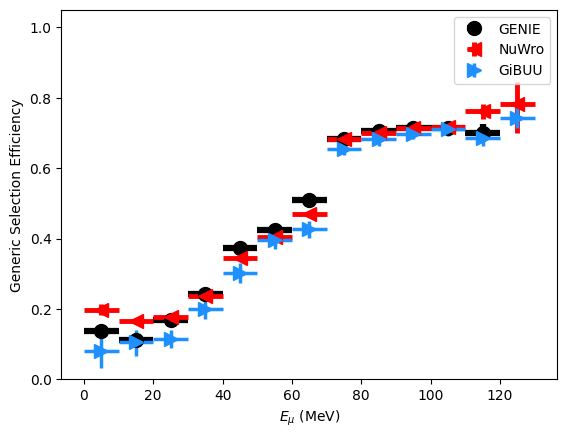

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.45it/s]


[[0.06563850243886316, 0.030651006580870832, 0.02057828052941435, 0.01646645107823852, 0.015178383246032712, 0.016796213410067096, 0.021911340898728537, 0.022719060621670895, 0.036901576582110907], [0.06769483089447026, 0.025059357291773776, 0.02111130135586381, 0.0175062413110868, 0.018476912026605286, 0.016045643820168487, 0.018528293131796714, 0.023437348971226124, 0.03260358414212905]]


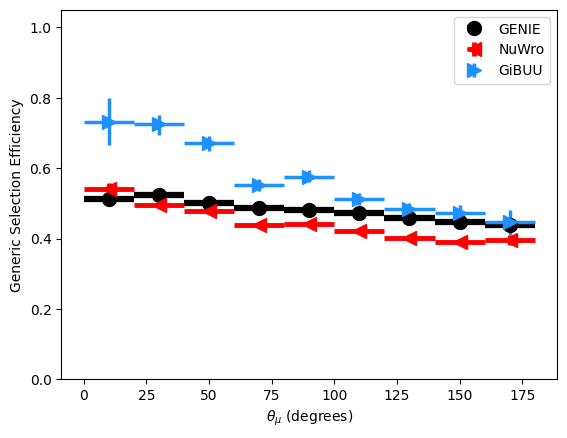

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.40it/s]


[[0.010164022206064383, 0.018095375000808822, 0.022549927159132455, 0.024019177278479242, 0.029949693858332627, 0.03968781354314732, 0.042647995816841144, 0.06558308979443142, 0.07401793936024542, 0.11948247988657515, 0.22878770033518475, 0.280251145362854, 0.5], [0.0103262619559642, 0.01898173655022939, 0.020455276139994316, 0.027585546096410285, 0.03330241255948568, 0.036825431913672824, 0.041863514169916405, 0.05919163548029388, 0.09989510411801544, 0.11530539890130359, 0.23787896633148198, 0.24641552130381206, 0]]


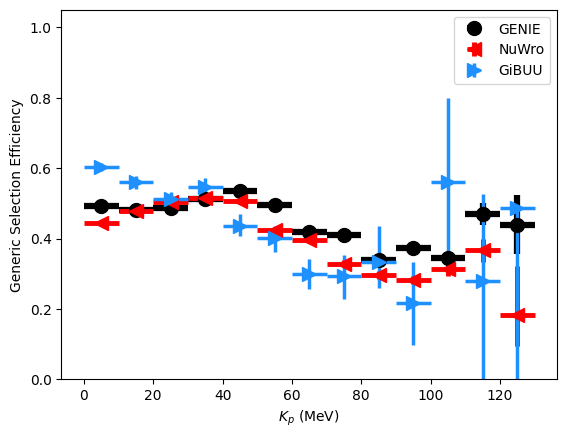

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.44it/s]


[[0.033925330254745534, 0.01886036861514684, 0.0167901031210953, 0.02023476762031501, 0.029125088604862404, 0.035246953106365, 0.03832785034603403, 0.05007810682282415, 0.09393203258514404], [0.025149446181008006, 0.020421435946816835, 0.01929003703816845, 0.023135117764742863, 0.02752842079831319, 0.028545622535051662, 0.0383051913543786, 0.0494624111387465, 0.07876533583590861]]


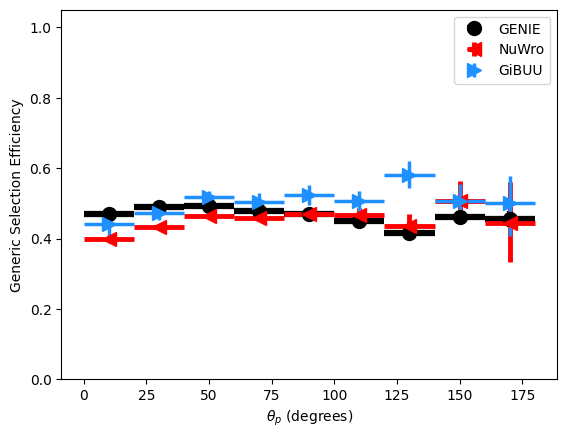

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:56<00:00,  5.33it/s]


[[0.1352805097897848, 0.06443234590383673, 0.022761485602732945, 0.017304475274782072, 0.01629966965105978, 0.016320293566184807, 0.0215420555687289, 0.019997218196269984, 0.02857196428101577, 0.02741766326620179, 0.03706908152383917, 0.03825885819838461], [0.1266242521149772, 0.06296833851812422, 0.02222078763176416, 0.015011428011831751, 0.016367513580743398, 0.01929620432434065, 0.0238086522266312, 0.02281049852329209, 0.022991187128633572, 0.02956327367310574, 0.03245062269644089, 0.0357396266238634]]


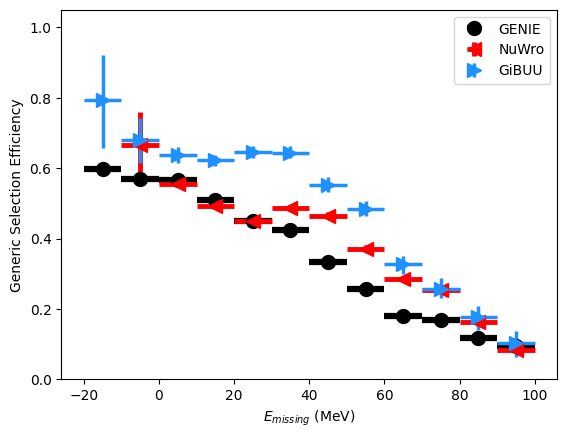

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:56<00:00,  5.28it/s]


[[0.05648511509273357, 0.03400130913807797, 0.028401124855935378, 0.023855978346245088, 0.020678294461877966, 0.017764156808656062, 0.015832894337310555, 0.01792883276607249, 0.024761471080779973, 0.0803393358769624], [0.07821260747455416, 0.04189346448544318, 0.03236434234763097, 0.022053286553931573, 0.02023549404079683, 0.01597639653042804, 0.015107369039309149, 0.016976515055282082, 0.02279606426197811, 0.09381358766126846]]


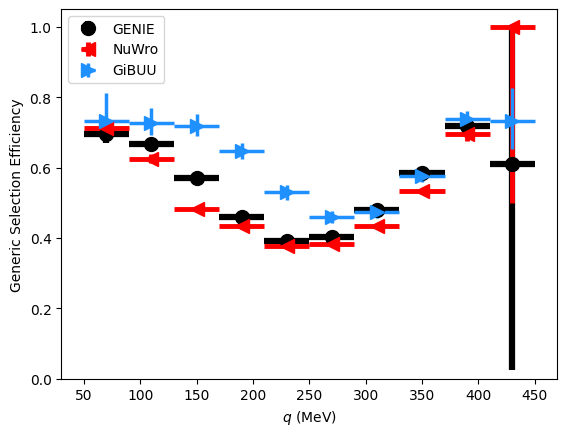

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:56<00:00,  5.33it/s]


[[0.6750869750976562, 0.10241602767597546, 0.0563549022925528, 0.03962886618996808, 0.030925990903012734, 0.024077698595071473, 0.01991267809620434, 0.01793214379877378, 0.01700543801195653, 0.015001249727042976, 0.024171409593580995, 0.04510234305489891, 0.534917743206023], [0.32491302490234375, 0.08515895488621938, 0.05224682590854701, 0.033724427223205566, 0.025337274772738283, 0.022530489617038407, 0.020547620848682224, 0.018846679358150542, 0.012790166586635843, 0.021417662827747597, 0.022862896119054454, 0.03664662882443215, 0.18508225679397583]]


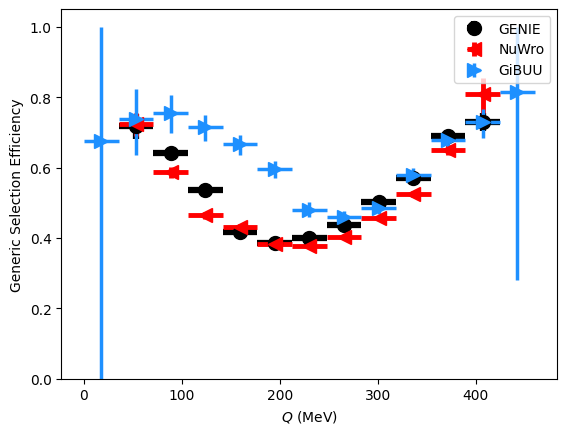

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.38it/s]


[[0.034000914945501726, 0.023674166415464493, 0.01876038276570957, 0.015495707718140128, 0.019788543752195853, 0.02143145478007147, 0.022969786634363942, 0.023365224266466866, 0.028636820554235776, 0.02562699025148582, 0.027164345039995277, 0.03566747400122629, 0.04722769359747569], [0.031024623605701906, 0.019255475832684166, 0.01932432450126853, 0.01735275991177021, 0.021333481728765813, 0.018596344471124904, 0.024184362920887326, 0.02087049402556168, 0.023573666535488924, 0.02932972465615491, 0.030872143758273435, 0.04104595992926116, 0.05580260943282733]]


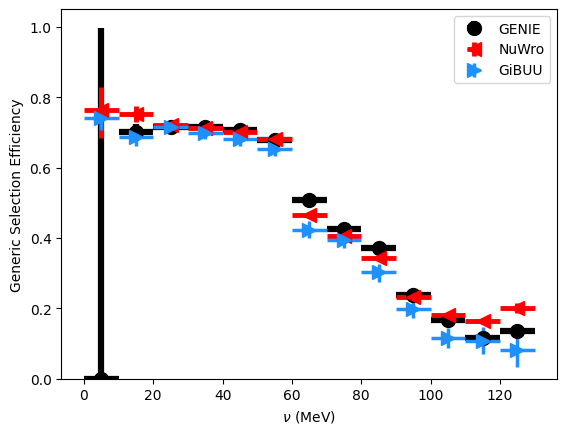

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.43it/s]


[[0.11014421961524268, 0.08234874010086057, 0.045385746218941425, 0.028961083439451252, 0.03019976318413864, 0.025471278171443457, 0.01950877125176126, 0.023913893418991583, 0.026027277991461872, 0.02367660970194896, 0.025562246546432243, 0.02765463914842725, 0.02773880938622464, 0.02769347002528455, 0.0355632654801451, 0.03147764679229892, 0.03444285944392178, 0.04383374947304819, 0.044978475129352824, 0.05816180906363477], [0.09591638644536338, 0.07765125989913946, 0.03944378093667267, 0.03958111626863292, 0.02676729724398652, 0.022987721755141077, 0.024104191935114316, 0.024976368140099514, 0.02120815644596652, 0.02476410013744157, 0.028034999457395626, 0.02664047800395497, 0.030666989268990807, 0.029462691984678546, 0.03134499326151374, 0.031792358556688716, 0.03816606213502827, 0.03691528226452856, 0.0495669703150905, 0.06402518806388247]]


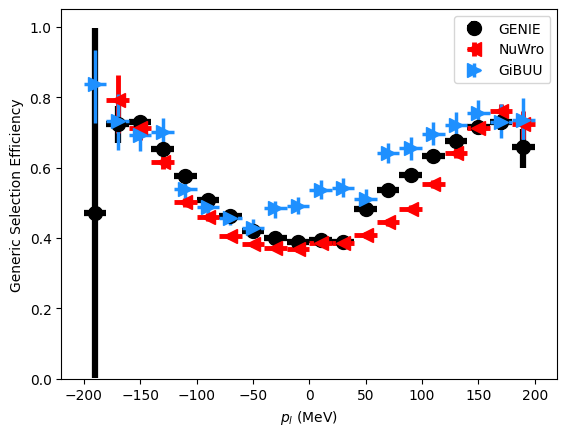

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.36it/s]


[[0.04660562335402127, 0.042205546452017406, 0.03130513207528879, 0.022008830678979074, 0.02248894963640874, 0.017870874350355725, 0.016790940493535356, 0.017496265702228952, 0.02146588316743292, 0.029633314912695607], [0.05723923476200332, 0.03232162329635063, 0.029278130634125543, 0.02962553858743866, 0.01834997960344037, 0.01935152513264482, 0.018184180179015574, 0.016007104107299108, 0.020466972182011878, 0.03144695473659076]]


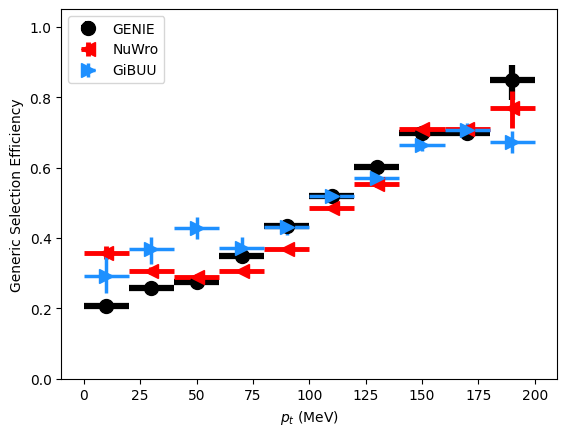

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.40it/s]


[[0.045049507170915604, 0.06257262080907822, 0.03964591026306152, 0.04001291286992091, 0.03532457956174312, 0.023693644164601207, 0.0264663296624133, 0.02474474245733088, 0.020803570172575503, 0.017367618924896577, 0.01777250646687245, 0.01607810521918751, 0.024997060878783728, 0.06118121017938338, 0.1361414988835653], [0.12695049282908427, 0.0722845220480646, 0.036246946879795613, 0.04041353491849678, 0.028494892502898606, 0.03186278526372699, 0.026623076781993937, 0.021150459196836335, 0.019314053609173376, 0.017730125592494872, 0.017103898541967588, 0.015953235005646937, 0.023685980325367062, 0.06467422946294143, 0.13528006974388573]]


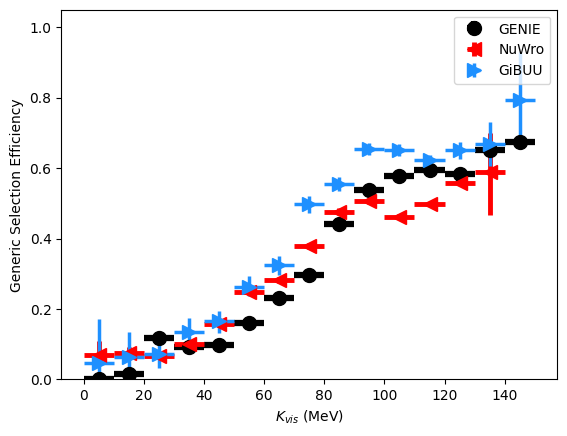

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:54<00:00,  5.46it/s]


[[0.006864080859665833], [0.007389372663346494]]


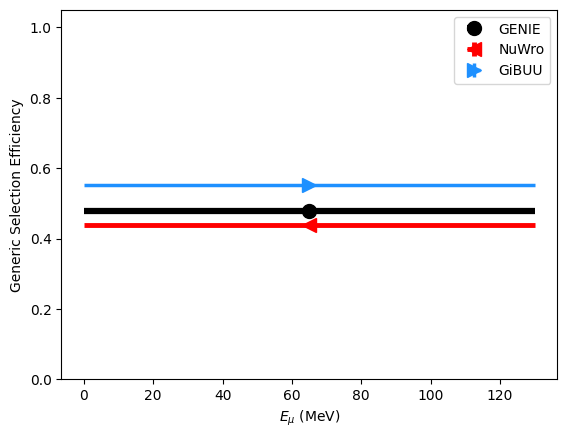

In [177]:

this_truth_vars = ["truth_Emuon","true_angle_deg","truth_prim_p_energy","true_angle_P_deg","true_Em","true_q","true_sqrtQ2","true_nu","true_pl","true_pt","true_KE","truth_Emuon"]
this_xlabels = [f"$E_\mu$ (MeV)","$\\theta_\mu$ (degrees)",f"$K_p$ (MeV)","$\\theta_p$ (degrees)","$E_{missing}$ (MeV)","$q$ (MeV)","$Q$ (MeV)","$\\nu$ (MeV)","$p_l$ (MeV)","$p_t$ (MeV)","$K_{vis}$ (MeV)",f"$E_\mu$ (MeV)"]

this_bins_list = []
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(0,180,10))
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(0,180,10))
this_bins_list.append(np.linspace(-20,100,13))
this_bins_list.append(np.linspace(50,450,11))
this_bins_list.append(np.linspace(0,460,14))
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(-200,200,21))
this_bins_list.append(np.linspace(0,200,11))
this_bins_list.append(np.linspace(0,150,16))
this_bins_list.append(np.linspace(0,130,2))

this_sig_query = "is_KDAR==1"
this_sel_query = "kine_reco_Enu>0"

plot_eff(this_truth_vars,this_sig_query,this_sel_query,this_bins_list,xlabels=this_xlabels,ylabel="Generic Selection Efficiency")


Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:56<00:00,  5.27it/s]


[[0.06979990899562835, 0.05282667634616389, 0.04463246482083583, 0.03274149681126509, 0.025248084916266678, 0.02036332039555805, 0.016712046627568755, 0.019567461112966145, 0.017518228122494928, 0.016826914241843016, 0.01756631931092867, 0.019434056161786617, 0.03155661922089259], [0.08845576603424021, 0.05830679046752729, 0.04081793352031876, 0.03042555441838607, 0.02544102612842475, 0.026514991450356906, 0.020463331778768412, 0.01703772750244259, 0.019833581616008233, 0.018417457524554592, 0.017466595714660138, 0.023972592991216346, 0.035255909929435725]]


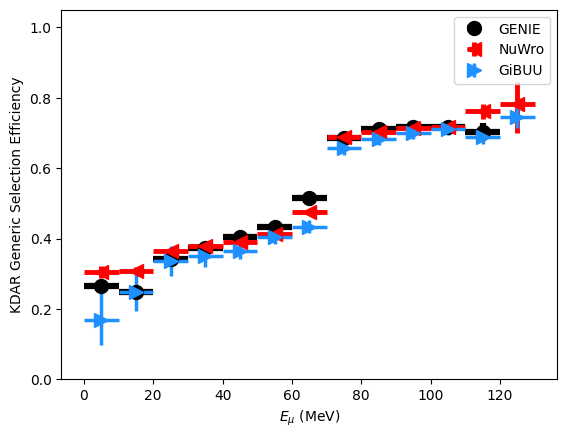

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:56<00:00,  5.34it/s]


[[0.06816299756368005, 0.02578561420708614, 0.020597945205394486, 0.018719905955915217, 0.01522488140542344, 0.01614454063132642, 0.019736207463088018, 0.02105398050243701, 0.037241815578729354], [0.07004838455014117, 0.031075200933408098, 0.018129305914286298, 0.01798088754413285, 0.017524261429119115, 0.01390784257635913, 0.019420518613312288, 0.024015665381589058, 0.031245904877367114]]


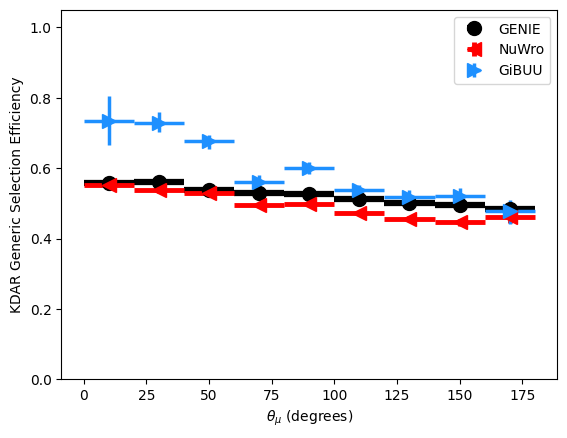

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.40it/s]


[[0.010082029924905256, 0.018411312247542666, 0.020220391285846406, 0.025736154451088344, 0.03149460056504644, 0.03863389577184406, 0.03941226980396523, 0.055081851001995696, 0.10007930795351666, 0.14305399931394136, 0.24921453441892338, 0.28938356041908264, 0.5], [0.01090495678722192, 0.020529251611293042, 0.02209195478242676, 0.024979572231050517, 0.031164594809440227, 0.043109198971250706, 0.04863495105191279, 0.05745981226636193, 0.08382873802349489, 0.1475442912843492, 0.22507117986679082, 0.21061643958091736, 0]]


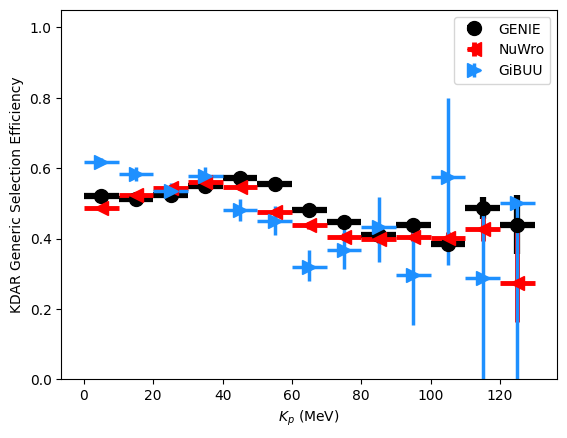

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:54<00:00,  5.52it/s]


[[0.031180306192048257, 0.020387760218955164, 0.019048606988590566, 0.022947674648951533, 0.024109650016998163, 0.0339314341545105, 0.03729323555704134, 0.036021189931722764, 0.10652033009270362], [0.02998321350786981, 0.021101156105474805, 0.0201071152933463, 0.01961892858222747, 0.025131288261343032, 0.026631115019368323, 0.04041863359521125, 0.04700870011223657, 0.08629620737499666]]


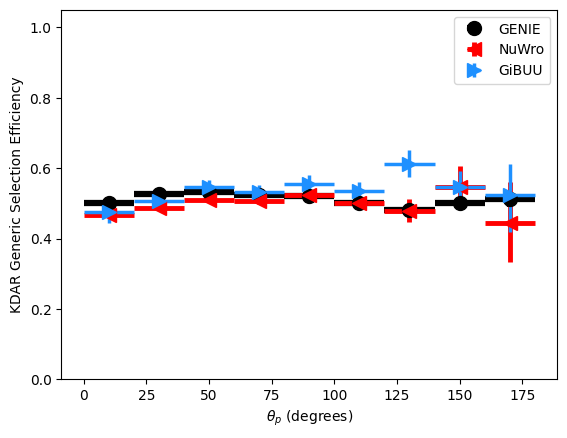

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:54<00:00,  5.49it/s]


[[0.11667263507843018, 0.05921122698200909, 0.021747945649283285, 0.017642917558498228, 0.01563904417374129, 0.017205182470749647, 0.01885694013381123, 0.025612843140742858, 0.02713409370554626, 0.03337966328236597, 0.042762424486056105, 0.05983510301312728], [0.11249403158823645, 0.05977876489074141, 0.020875881019097875, 0.014062815461081124, 0.01622748775336247, 0.01746539359165944, 0.021234241602071435, 0.01973123170333191, 0.02553025431099676, 0.030547631838739098, 0.046988336487514215, 0.05667978070932839]]


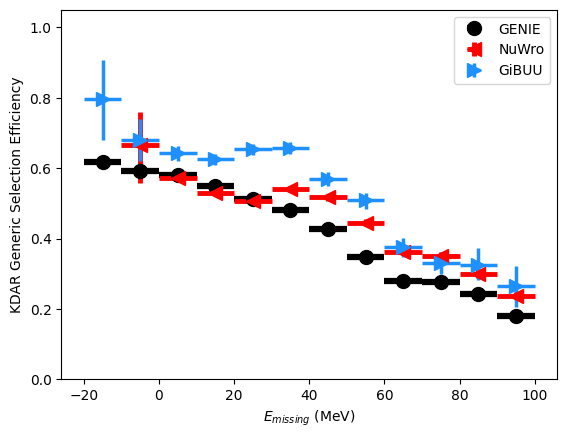

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.42it/s]


[[0.06620367368062341, 0.04007697416388467, 0.026081512447231003, 0.024188675994433417, 0.02089813758685266, 0.016900022712252827, 0.015157141562739007, 0.015359426475013649, 0.025451673401726604, 0.09338015611821948], [0.062001454524504784, 0.039095536355049365, 0.03122386953220857, 0.022624870072737613, 0.020222606427999557, 0.014241390512195418, 0.013700482496150967, 0.014917587146632494, 0.026985927866932657, 0.100534995396932]]


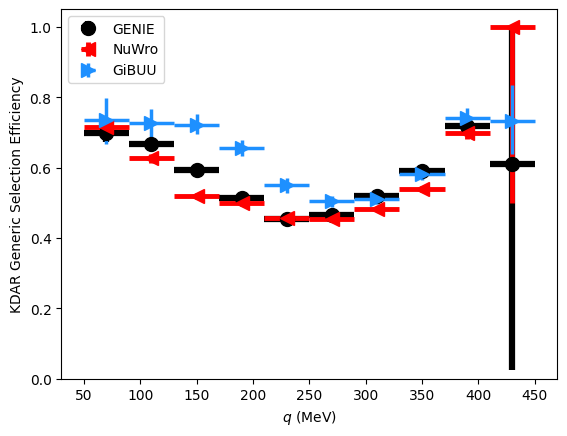

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:54<00:00,  5.48it/s]


[[0.6750869750976562, 0.09905223608016966, 0.04591915876634656, 0.037797840883995626, 0.02418632462207726, 0.02374826280641751, 0.019072295838875597, 0.016269874627815928, 0.014487713554095394, 0.015917356700017926, 0.02114755019499326, 0.03843525167583495, 0.8173500299453735], [0.32491302490234375, 0.09534776391983035, 0.053226951290579416, 0.03441128481949984, 0.027073906136030113, 0.023387598121626718, 0.019006098571349828, 0.014388602039841492, 0.01610249717985124, 0.018090109633845164, 0.023107244084208056, 0.034800162440852156, 0.18264997005462646]]


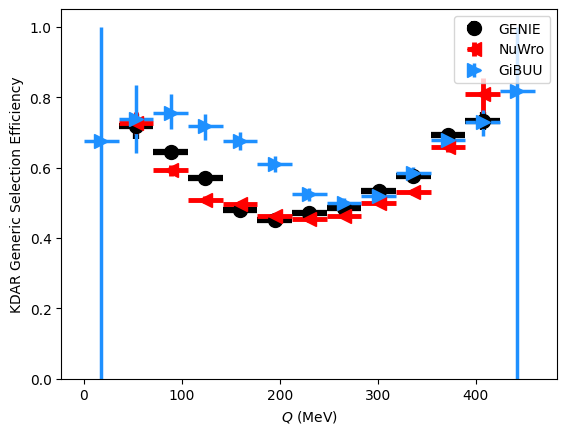

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.43it/s]


[[0.03336774850193458, 0.01841794381460038, 0.021090835499417926, 0.018164111979134923, 0.016974727872115514, 0.017791364396253728, 0.019978993250670096, 0.022487834954999175, 0.021784421405028287, 0.035641568308907356, 0.03765069203729016, 0.06069771164237153, 0.07805796238509091], [0.037551366218231075, 0.024281950119528495, 0.018874946804968706, 0.016739429038993725, 0.018264954327424587, 0.019560038912087352, 0.021451348487945887, 0.021688564843330427, 0.02630959910182251, 0.022654507124479417, 0.03804716724470042, 0.04330041379697863, 0.08217580384867529]]


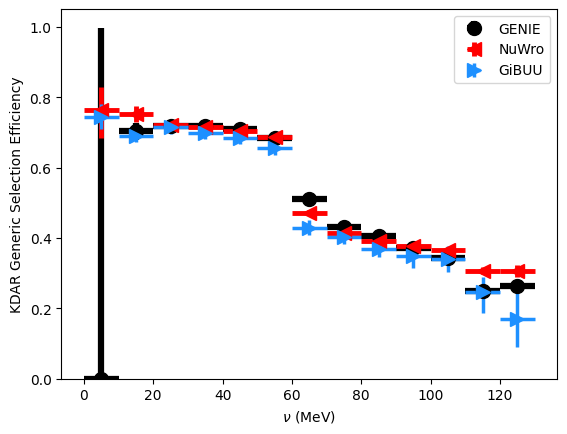

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.44it/s]


[[0.09030581967035922, 0.08587688236580404, 0.041117275066746006, 0.03502736496117842, 0.026719090471349904, 0.024542539275281716, 0.02820865716208021, 0.023880343907891288, 0.02462269197608602, 0.022076609992564666, 0.02850195097121988, 0.0342047559156925, 0.024213673559982773, 0.034405628885473494, 0.03104036497400553, 0.03721284261291313, 0.036921558364125695, 0.03909221559909759, 0.04994999183412263, 0.06679834922154748], [0.10353731758454265, 0.08272143477141247, 0.04070268071523986, 0.027274370147363558, 0.028522387347596156, 0.022634684411488193, 0.022809635289196883, 0.020967304706573486, 0.02233365615245353, 0.022425029612324843, 0.02400095034223859, 0.022048625104607367, 0.025352350303864957, 0.026931491367309435, 0.03543275245665678, 0.03247681740348396, 0.03545912769105697, 0.03506127156709371, 0.04978002628287048, 0.07243242000922179]]


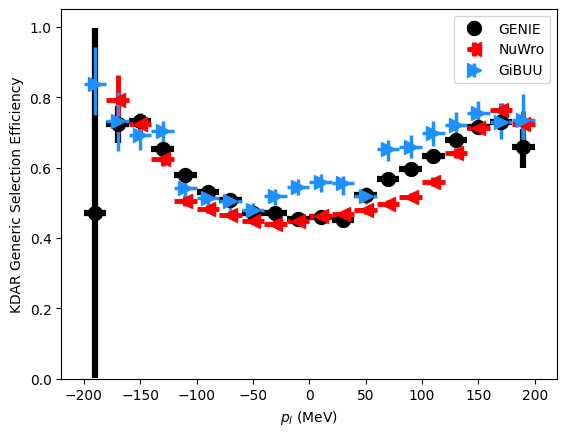

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.39it/s]


[[0.04677203925226692, 0.041992314403822284, 0.03651133311411153, 0.027813822458218118, 0.020753091156549497, 0.01902681772129966, 0.014928653320339103, 0.015372356551028088, 0.02126831385884287, 0.026194137364651704], [0.05200288296267369, 0.036622076997311404, 0.029258878792033483, 0.02514780157505314, 0.02192641183619981, 0.019962842371476275, 0.017008764475578864, 0.018123069739619524, 0.019650651371627803, 0.025148942355417314]]


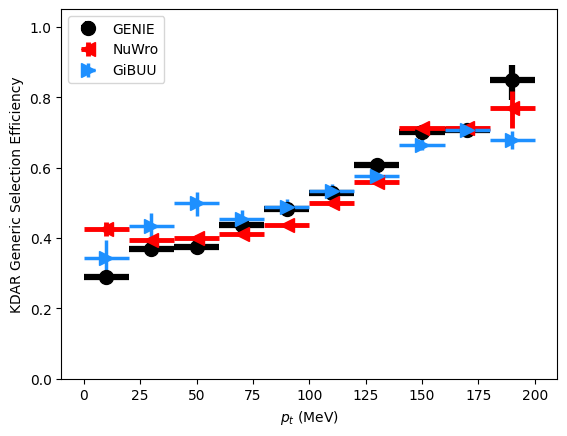

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:54<00:00,  5.47it/s]


[[0.07268879562616348, 0.08684385567903519, 0.0782441392992482, 0.05032492816712786, 0.03918268813472503, 0.033769304426490565, 0.025611087904248153, 0.022279719634262563, 0.01961141674998146, 0.017372624204743503, 0.015641618618901565, 0.016376294264484947, 0.020540299706695575, 0.07166336921223426, 0.1126765196139996], [0.13531120437383637, 0.07982281098763147, 0.07613814508303618, 0.049316837803109914, 0.04195306516670305, 0.02969397432686227, 0.028050398150680556, 0.024084378471986856, 0.022699021275109144, 0.01795516603038283, 0.016574502299786742, 0.013490814256360228, 0.023683629703118325, 0.051611484588935386, 0.1361922586665434]]


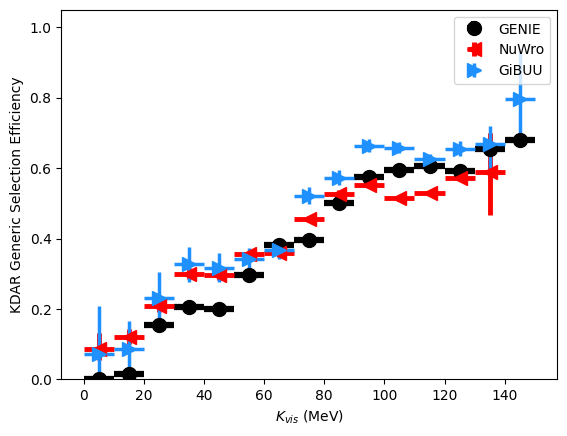

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:54<00:00,  5.46it/s]


[[0.007646343811698597], [0.007228238128100695]]


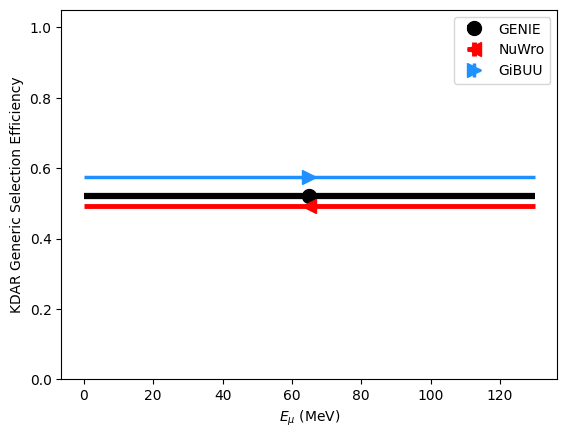

In [178]:
this_truth_vars = ["truth_Emuon","true_angle_deg","truth_prim_p_energy","true_angle_P_deg","true_Em","true_q","true_sqrtQ2","true_nu","true_pl","true_pt","true_KE","truth_Emuon"]
this_xlabels = [f"$E_\mu$ (MeV)","$\\theta_\mu$ (degrees)",f"$K_p$ (MeV)","$\\theta_p$ (degrees)","$E_{missing}$ (MeV)","$q$ (MeV)","$Q$ (MeV)","$\\nu$ (MeV)","$p_l$ (MeV)","$p_t$ (MeV)","$K_{vis}$ (MeV)",f"$E_\mu$ (MeV)"]

this_bins_list = []
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(0,180,10))
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(0,180,10))
this_bins_list.append(np.linspace(-20,100,13))
this_bins_list.append(np.linspace(50,450,11))
this_bins_list.append(np.linspace(0,460,14))
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(-200,200,21))
this_bins_list.append(np.linspace(0,200,11))
this_bins_list.append(np.linspace(0,150,16))
this_bins_list.append(np.linspace(0,130,2))

this_sig_query = "is_KDAR==1"
this_sel_query = "ssm_kine_reco_Enu>0"

plot_eff(this_truth_vars,this_sig_query,this_sel_query,this_bins_list,xlabels=this_xlabels,ylabel="KDAR Generic Selection Efficiency")

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.45it/s]


[[0.04337017252589717, 0.04433473443847963, 0.03566764914072476, 0.027754548267368673, 0.0227275359060109, 0.0210537407626904, 0.020897206277456337, 0.020071730420396117, 0.01708460596814687, 0.021300468723104538, 0.017638557882328154, 0.023919822446197503, 0.033847785259828456], [0.05596612523431363, 0.03122498570145041, 0.031187623246462515, 0.03040954933577919, 0.020791460751290236, 0.01953644077661193, 0.01925554577674987, 0.021380095051045434, 0.017402077735622745, 0.016033383504861054, 0.021022281583494506, 0.02891541415147658, 0.03907986894343629]]


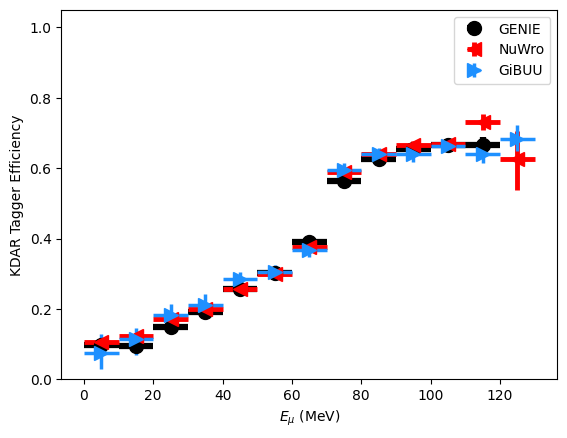

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.42it/s]


[[0.08830312693991316, 0.025809281468191836, 0.023610787227300367, 0.01765573919109298, 0.014921339689983104, 0.01662643960543808, 0.017814755386958203, 0.023465504602376286, 0.0348653113512703], [0.06546145418415894, 0.029482572330665313, 0.022447104768577475, 0.020610291742926723, 0.016821912288563, 0.01630537568214524, 0.02048335164117182, 0.02186741104258738, 0.0321423726520319]]


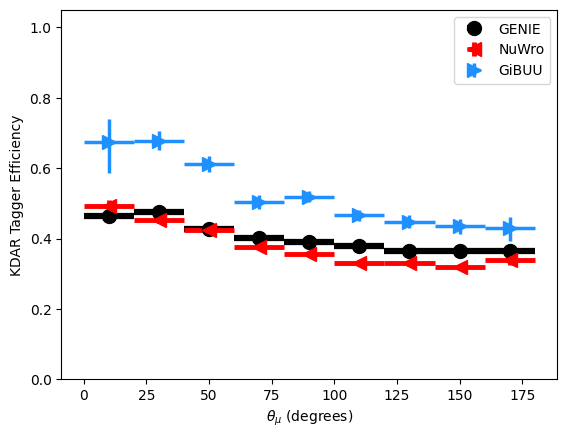

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.42it/s]


[[0.010398928343298919, 0.019961834898534758, 0.02088987208949805, 0.027727098549423013, 0.035000854542089066, 0.03306767948066133, 0.03295379264431217, 0.04620539932183816, 0.05403860820376355, 0.09842151403427124, 0.27106794714927673, 0.011796042323112488, 0.02777777798473835], [0.00955715727001083, 0.018874081543513666, 0.022292387059011376, 0.024543112802993705, 0.0304008213458552, 0.030527618891852237, 0.037020353170541614, 0.04428591722148961, 0.06504949480355632, 0.10157848596572877, 0.22893205285072327, 0, 0]]


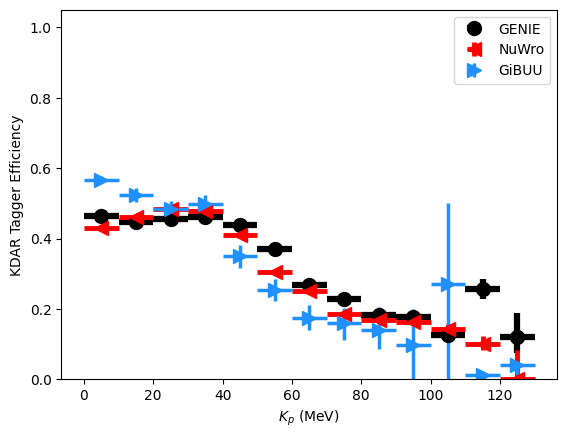

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.42it/s]


[[0.03222859549807361, 0.022233109735029177, 0.017421881163754704, 0.02285380175001006, 0.026030499389112116, 0.026352602976467354, 0.0401293135456271, 0.052121055475389144, 0.09886359728615862], [0.024778424214209283, 0.019517141033724816, 0.02079433773517575, 0.025034557254281498, 0.02492859498794353, 0.031217579060990097, 0.037921412929969756, 0.04167459332025969, 0.09256795966263975]]


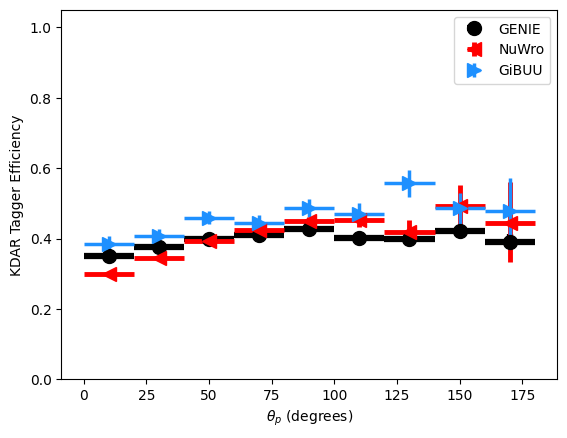

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:54<00:00,  5.48it/s]


[[0.1456297278404236, 0.06205096171452451, 0.023707578876457247, 0.017705545781985577, 0.016461170286518945, 0.019732709671324344, 0.0188350099368898, 0.021504560959946573, 0.02314808973005522, 0.02511831530062289, 0.03549186177568317, 0.050798821449279774], [0.14325916104846526, 0.06606097072423356, 0.024232505026995588, 0.01632291974149569, 0.01734630195939213, 0.02170614275786442, 0.022104837719577053, 0.026264452727338294, 0.026940531261639866, 0.0306333124778847, 0.03777546291372441, 0.052998646905150604]]


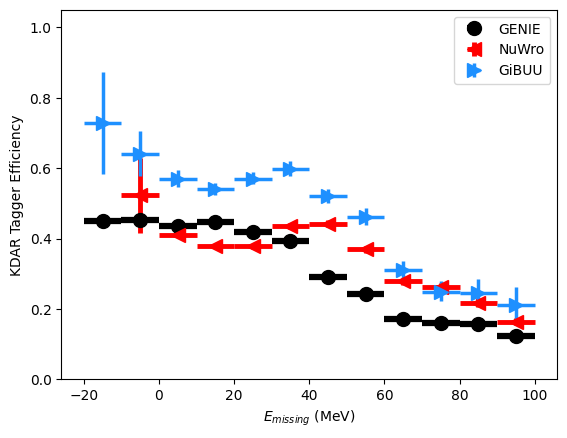

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.44it/s]


[[0.06383844614028933, 0.03820644002972229, 0.028303796709904905, 0.022464919183672882, 0.01902680556194347, 0.014360093618997372, 0.01743683029053844, 0.01870649984246131, 0.027173992406754333, 0.09238368272781372], [0.07543111907710198, 0.04185589650892829, 0.03185384700698113, 0.021295980963720984, 0.01961298210181084, 0.016411321091228503, 0.01387294932447819, 0.014612412714034906, 0.024947039339277555, 0.10079813545400451]]


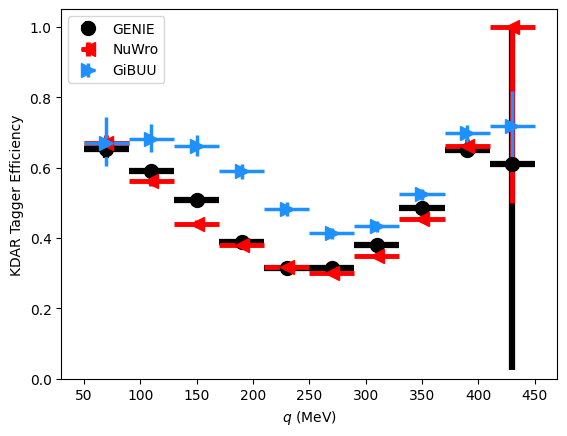

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.40it/s]


[[0.6333962678909302, 0.09772688563664755, 0.05631907328581198, 0.032175530086864135, 0.02806249812006467, 0.02259352720670682, 0.01928864901000471, 0.018071156771639896, 0.013884899712085397, 0.016278824796142954, 0.024154553489202923, 0.03893211589416978, 0.8078526854515076], [0.3666037321090698, 0.09703631195007945, 0.05500333108577271, 0.03780143905178157, 0.029223002539321863, 0.023469121382796443, 0.020539025445640013, 0.015489743866363315, 0.015479251377763237, 0.01920559907510333, 0.02151823487424731, 0.03467065260909985, 0.19214731454849243]]


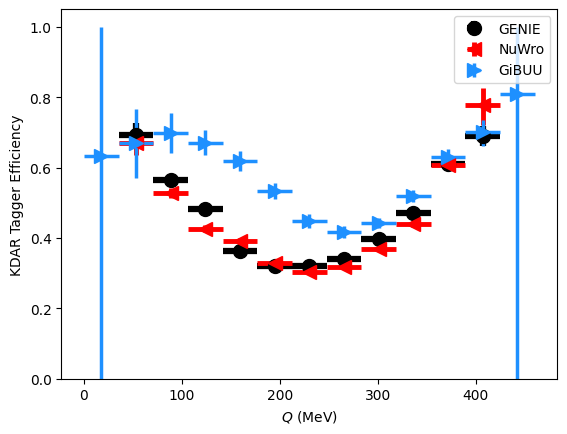

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.39it/s]


[[0.03630763433865292, 0.025466095292551727, 0.018881262633492768, 0.018732338026088646, 0.01782476348928186, 0.019819533517358545, 0.02040844719465673, 0.020411375729028902, 0.026348741246149332, 0.027613743323270212, 0.030256017823504566, 0.03976030063947891, 0.05057324117422094], [0.03802692878669034, 0.02480446778043599, 0.019028083424770137, 0.01950082049500612, 0.01986835708965451, 0.02059435368802065, 0.022108921335905585, 0.020213768468536397, 0.026658900859677037, 0.02815457507296726, 0.0342994789672863, 0.039589607677528116, 0.05042675882577896]]


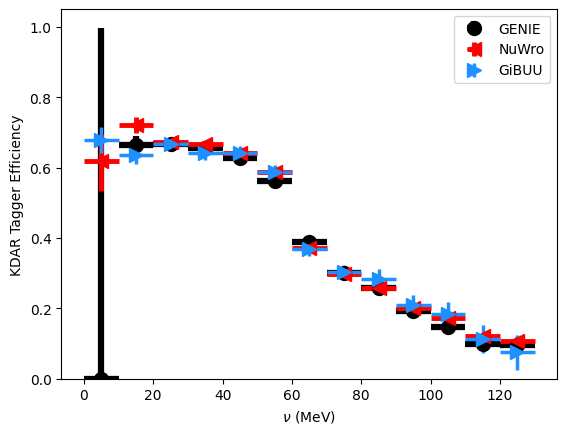

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:54<00:00,  5.48it/s]


[[0.12994782924652104, 0.08746768712194675, 0.04774901449100388, 0.034832109049885984, 0.02883518138216501, 0.02281671841553845, 0.024730499243315607, 0.02581800671584933, 0.018031375732870114, 0.026760782777648595, 0.028376164613418464, 0.03251644420896388, 0.029988366906702535, 0.026843592818627915, 0.03131049234874972, 0.03763272762298586, 0.039213105469775744, 0.03939125595301607, 0.04414675971294968, 0.07435634077369391], [0.1258416444376893, 0.08493842528416562, 0.04206023883011378, 0.0368398333785106, 0.03052098184065033, 0.025925675369641965, 0.02312119822166564, 0.02142253482962936, 0.020939051853088142, 0.01856296424027043, 0.02886903497274257, 0.028577349771409355, 0.03366126972347444, 0.033724850232573766, 0.032025439812748524, 0.039605077255063015, 0.03776222672039942, 0.04237248496567325, 0.04738227350386737, 0.07079745280115224]]


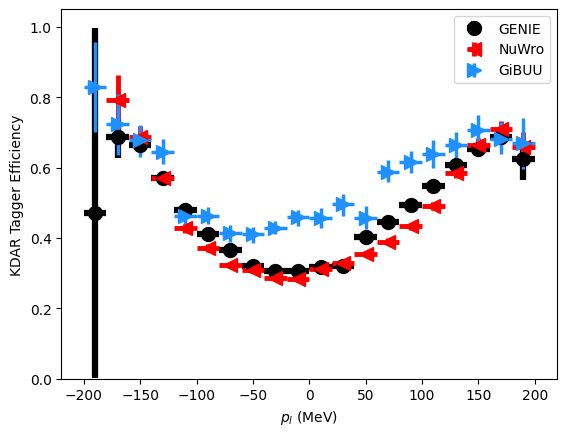

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:54<00:00,  5.51it/s]


[[0.04724727674972179, 0.04631309064798994, 0.02810747677639719, 0.02408189322577725, 0.024140934087991617, 0.016085248678998076, 0.014758304128088484, 0.01818047851570115, 0.01982564891601779, 0.031402406089825585], [0.05000430887395685, 0.040263603731908126, 0.031413353879350236, 0.024235791797118655, 0.018693966838529308, 0.016981284129165275, 0.01761855243590371, 0.017099692023693214, 0.022974197754998427, 0.029147469440584994]]


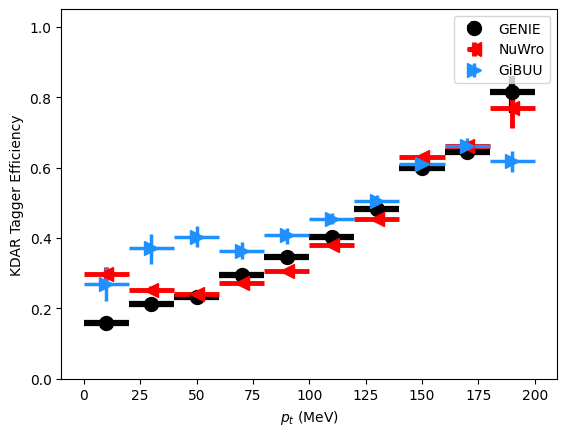

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:56<00:00,  5.35it/s]


[[0.033662132918834686, 0.05975647270679474, 0.06498052988733564, 0.04104025740300299, 0.03752570152282714, 0.02538862739466516, 0.019970339696080475, 0.021463034091173838, 0.019576490984497985, 0.018584275138516237, 0.01941271868131378, 0.015921833343399028, 0.024301350469282945, 0.06374669075012207, 0.14876952171325686], [0, 0.06657686062653856, 0.06397699907019333, 0.052540305256843556, 0.038377540885819295, 0.028256719064428337, 0.02666623341214952, 0.025249732395377256, 0.01769843140651417, 0.020804991593621258, 0.018301929241100967, 0.01135238758292112, 0.02568322842917725, 0.0721660076625763, 0.140119367175632]]


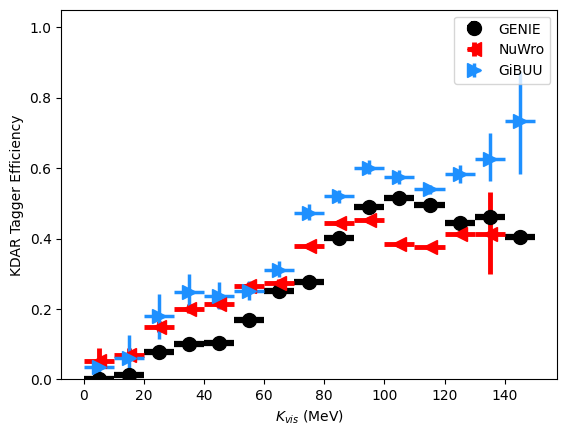

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.40it/s]


[[0.0074814760444842365], [0.007951471050054226]]


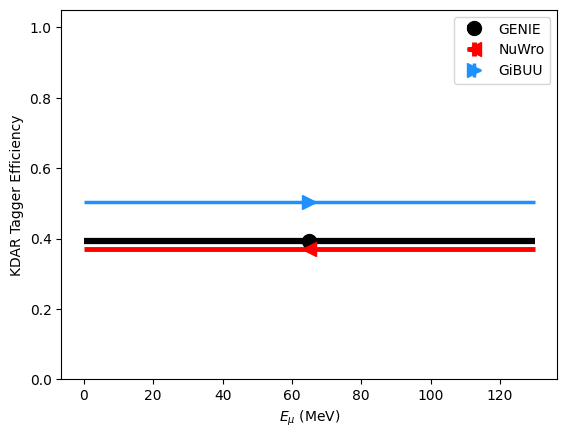

In [179]:
this_truth_vars = ["truth_Emuon","true_angle_deg","truth_prim_p_energy","true_angle_P_deg","true_Em","true_q","true_sqrtQ2","true_nu","true_pl","true_pt","true_KE","truth_Emuon"]
this_xlabels = [f"$E_\mu$ (MeV)","$\\theta_\mu$ (degrees)",f"$K_p$ (MeV)","$\\theta_p$ (degrees)","$E_{missing}$ (MeV)","$q$ (MeV)","$Q$ (MeV)","$\\nu$ (MeV)","$p_l$ (MeV)","$p_t$ (MeV)","$K_{vis}$ (MeV)",f"$E_\mu$ (MeV)"]

this_bins_list = []
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(0,180,10))
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(0,180,10))
this_bins_list.append(np.linspace(-20,100,13))
this_bins_list.append(np.linspace(50,450,11))
this_bins_list.append(np.linspace(0,460,14))
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(-200,200,21))
this_bins_list.append(np.linspace(0,200,11))
this_bins_list.append(np.linspace(0,150,16))
this_bins_list.append(np.linspace(0,130,2))

this_sig_query = "is_KDAR==1"
this_sel_query = "ssm_kine_energy>0 and ssm_kine_reco_Enu>0"

plot_eff(this_truth_vars,this_sig_query,this_sel_query,this_bins_list,xlabels=this_xlabels,ylabel="KDAR Tagger Efficiency")

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.42it/s]


[[0.3185671019554133, 0.14205469426355866, 0.06843769811925626, 0.05136127251592171, 0.03470064286549879, 0.030533876942425264, 0.0197273265268475, 0.01305273058508638, 0.00997777277668388, 0.015076809721614515, 0.01306223499404835, 0.020890568311154767, 0.02171027917115753], [0.2280995647112528, 0.1512379576560956, 0.061166143417358376, 0.05403772211884017, 0.03704024291538688, 0.03061287836749238, 0.025434804109025766, 0.014591694827815638, 0.010288423377703526, 0.012849066300351764, 0.01325474220064049, 0.01408044298709299, 0.029595126002239458]]


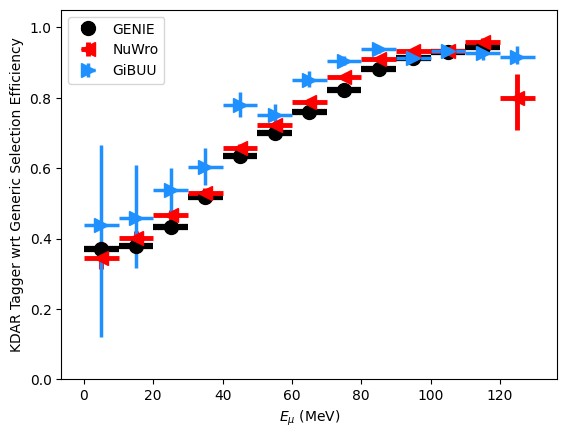

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.42it/s]


[[0.04891684591176659, 0.022545072052927995, 0.013529957496558498, 0.015536197933821438, 0.013296459762143442, 0.015579485008634375, 0.016177305760092353, 0.026260082540284335, 0.02647672328270745], [0.05198109149932861, 0.02005772711450049, 0.014767463764851607, 0.013184488620122004, 0.015353087224947992, 0.015742099872002258, 0.01850308591898009, 0.026142474929089388, 0.031495043662828515]]


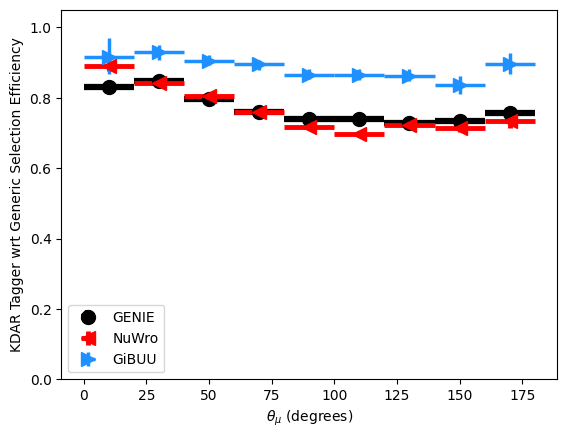

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.44it/s]


[[0.006939057141238991, 0.013465825702184131, 0.016950358565572143, 0.025093178811751327, 0.04059097125298161, 0.05553156834064088, 0.09153473487664093, 0.09780676166216534, 0.12531383633613585, 0.3314970135688782, 0.4714808464050293, 0.040762655436992645, 0.0555555559694767], [0.0064328444217005565, 0.015913203866628534, 0.015946575788358452, 0.018567321137281434, 0.04309906337572178, 0.05203526752218779, 0.07926613092422485, 0.11431445045904676, 0.12923161820931867, 0.33516965309778846, 0.5285191535949707, 0, 0]]


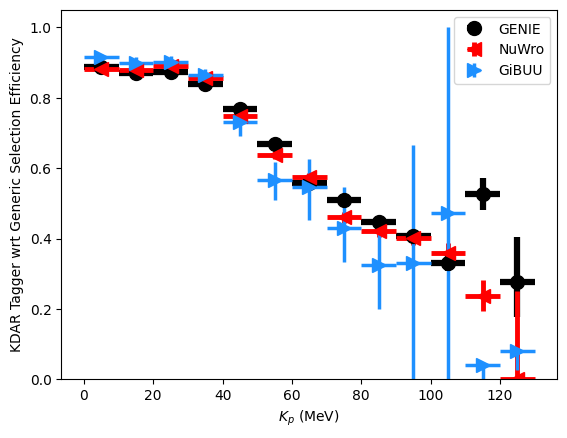

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:54<00:00,  5.56it/s]


[[0.03915288293848551, 0.023880906579355043, 0.025238678835016293, 0.023039921940725017, 0.025175403227899906, 0.026581679524630197, 0.02407639793874017, 0.044495440047720214, 0.06825089371638737], [0.03676176126872266, 0.023834745639710886, 0.016849857213003694, 0.023584219925768424, 0.023001098632812522, 0.026770179920229342, 0.02721882799397346, 0.04227392513748207, 0.08624303340911865]]


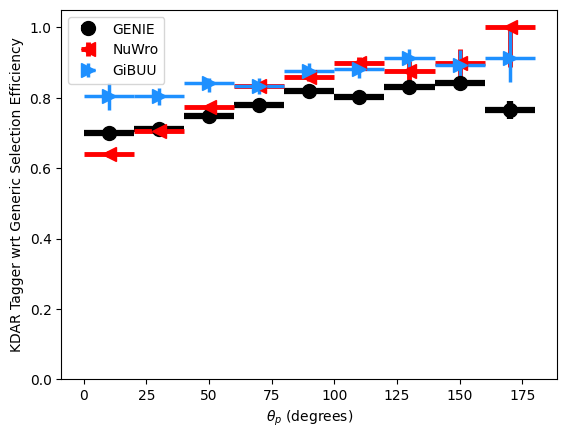

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:54<00:00,  5.52it/s]


[[0.09386769930521643, 0.043246573362594964, 0.018718329988417826, 0.012547160843377703, 0.0152525093018262, 0.012858925097126495, 0.014549447621913347, 0.019038064902242136, 0.03263545310022442, 0.04846311138387316, 0.06747732051213584, 0.07816173349108013], [0.0727989673614502, 0.03659025647423486, 0.019946565261992566, 0.014526661655657969, 0.01462294065324865, 0.016014745090872307, 0.01818512003576389, 0.0204195589043622, 0.03756471477378254, 0.057655805818635386, 0.07159985518572953, 0.08755255222320557]]


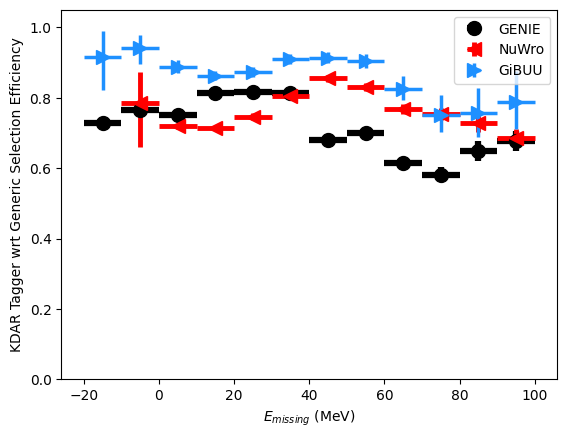

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.45it/s]


[[0.057694236098469576, 0.026222925660836727, 0.02013446970103161, 0.01787641303229881, 0.015627279726770693, 0.01741143006293655, 0.015225716445726123, 0.013617649103390583, 0.017139418048174315, 0.03837645109962018], [0.058479590075356636, 0.026446757597081816, 0.019934038071035887, 0.020304824832424462, 0.01818023222376819, 0.017010527005366094, 0.01592637605147995, 0.013481180514058777, 0.018363260085999422, 0.021035313606262207]]


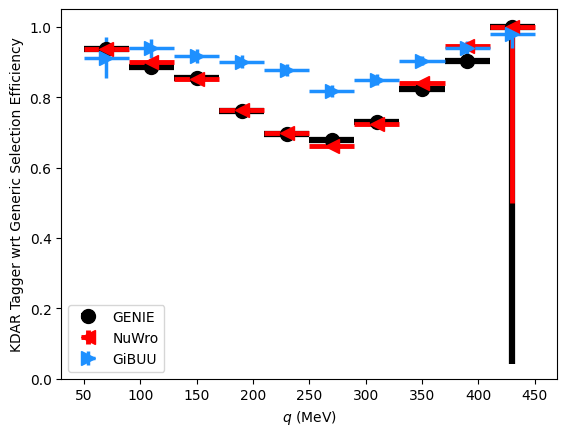

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.44it/s]


[[0.9382439851760864, 0.08621102029627015, 0.037845480826593225, 0.023835837360189682, 0.017356570718631614, 0.01957055107557215, 0.020205143841609985, 0.018512109827493517, 0.015389179782867468, 0.015317848620370444, 0.017625960466312374, 0.0173410882128312, 0.9883803129196167], [0.061756014823913574, 0.09560716152191162, 0.034285544207657614, 0.02467864489448124, 0.02223926415810218, 0.022205578628712863, 0.016737870907277297, 0.015064961604808302, 0.01669655706503037, 0.01681013805732179, 0.01515741546604421, 0.019112877297314035, 0.0116196870803833]]


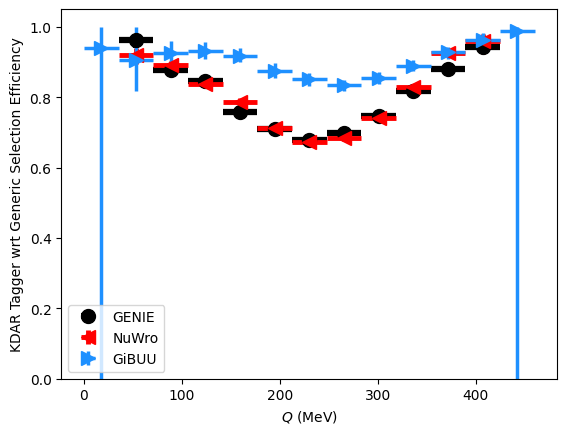

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.40it/s]


[[0.025925886154174793, 0.016337459995633075, 0.012184761924829979, 0.012897793711592276, 0.010815581935372909, 0.01418220278635196, 0.01997237115785122, 0.028342322631740746, 0.03935458184649798, 0.05879816316398234, 0.065961447088342, 0.14231260356150177, 0.4413478374481201], [0.02103346343932111, 0.016437265279092172, 0.010913723413278786, 0.012028861719966644, 0.013300155848015471, 0.014493124622435904, 0.02250489623941243, 0.03328850336798861, 0.034234912872314505, 0.05512416990179769, 0.07215230503389913, 0.1252312560876211, 0.2253188292185465]]


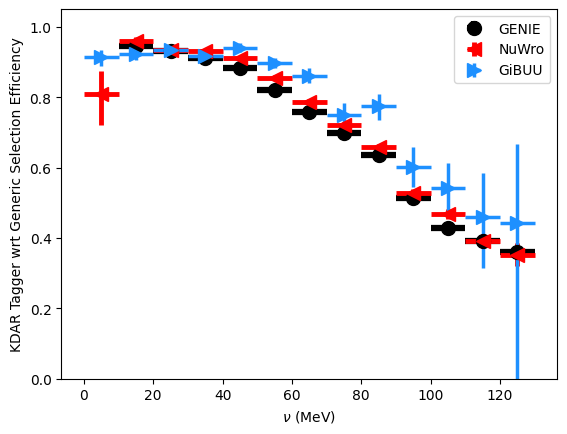

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:54<00:00,  5.49it/s]


[[0, 0.03651683330535893, 0.015794239713457392, 0.024632284258403914, 0.027223751480796143, 0.020415535097932924, 0.026868788706830182, 0.023351526350157026, 0.027375113964080766, 0.02080456119669727, 0.02895297956839571, 0.022916320182235217, 0.023362521777080425, 0.02493668342727462, 0.016512178595900595, 0.024160557293440243, 0.025038182288052546, 0.023300533766274945, 0.03286096742504929, 0.05652406862046988], [0.009182155132293701, 0.013483166694641113, 0.019155144691467285, 0.02419670059389456, 0.030218779713499733, 0.022672810360020446, 0.024132483223832435, 0.02249648376952773, 0.021613882799673245, 0.018956117356522473, 0.02651208230241453, 0.023434406336510172, 0.02362949360916944, 0.02639864098946776, 0.019704119725660885, 0.02333133926077957, 0.024414535931178483, 0.024611554145812953, 0.032516081755278536, 0.05488333878693752]]


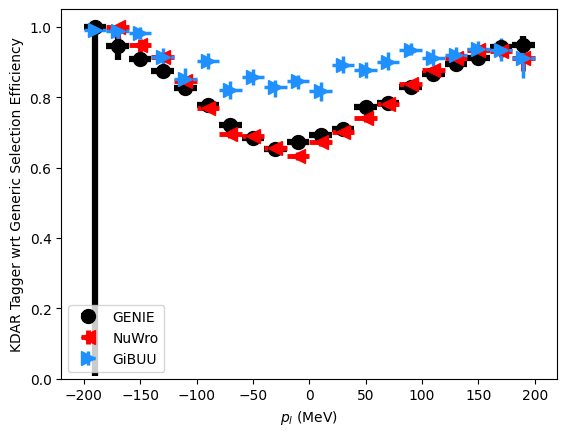

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:54<00:00,  5.51it/s]


[[0.07114205629594861, 0.0466822350726408, 0.03473389230693569, 0.031204728906020995, 0.02677214749315948, 0.01812268281594298, 0.011861527878450073, 0.012588393721794211, 0.01113876495927446, 0.021522978606320797], [0.07632338149206974, 0.046185010186118425, 0.031298260402395583, 0.031084439610900128, 0.021790257522038003, 0.017418808963172494, 0.013770789074621592, 0.012783567031036891, 0.011587014476072466, 0.02274686098098755]]


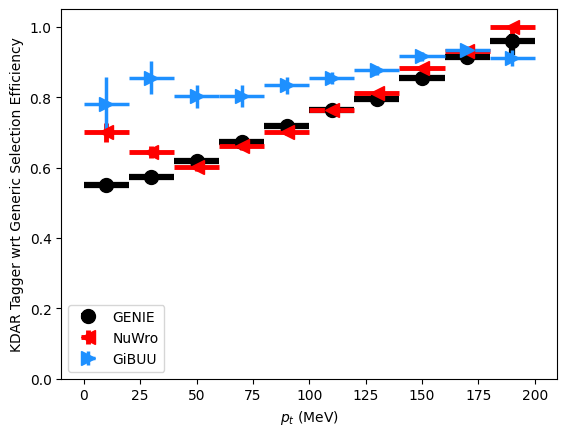

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.36it/s]


[[0.46309930086135864, 0.688090980052948, 0.15523499250411987, 0.078908432388472, 0.05897670292613477, 0.04610329412917902, 0.031206225560716394, 0.015960048103697888, 0.014270541714386353, 0.014322862063987696, 0.015536905183449745, 0.014196270524317267, 0.020931374280230175, 0.04538625962025411, 0.09683338801066077], [0, 0.311909019947052, 0.21976500749588013, 0.08428804354416697, 0.07095025900082708, 0.043354478208642244, 0.03490947691862245, 0.016046808117314404, 0.015802498071614268, 0.014861097527218425, 0.012413279736490757, 0.011940856486716944, 0.02116797441354945, 0.03580861946936187, 0.06983327865600586]]


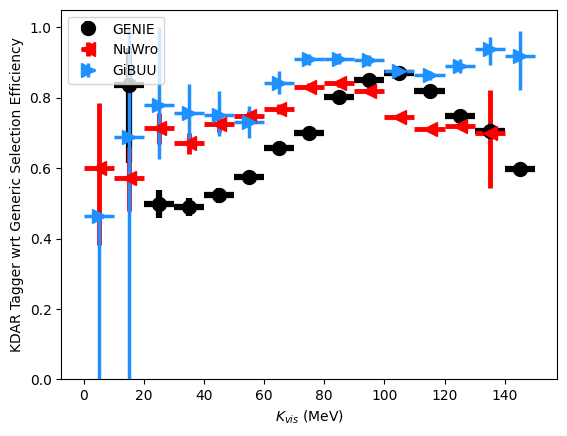

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:54<00:00,  5.49it/s]


[[0.005288439555185986], [0.005905160456458836]]


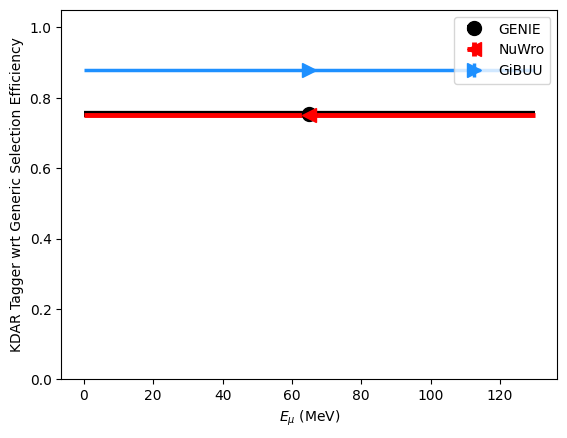

In [180]:
this_truth_vars = ["truth_Emuon","true_angle_deg","truth_prim_p_energy","true_angle_P_deg","true_Em","true_q","true_sqrtQ2","true_nu","true_pl","true_pt","true_KE","truth_Emuon"]
this_xlabels = [f"$E_\mu$ (MeV)","$\\theta_\mu$ (degrees)",f"$K_p$ (MeV)","$\\theta_p$ (degrees)","$E_{missing}$ (MeV)","$q$ (MeV)","$Q$ (MeV)","$\\nu$ (MeV)","$p_l$ (MeV)","$p_t$ (MeV)","$K_{vis}$ (MeV)",f"$E_\mu$ (MeV)"]

this_bins_list = []
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(0,180,10))
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(0,180,10))
this_bins_list.append(np.linspace(-20,100,13))
this_bins_list.append(np.linspace(50,450,11))
this_bins_list.append(np.linspace(0,460,14))
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(-200,200,21))
this_bins_list.append(np.linspace(0,200,11))
this_bins_list.append(np.linspace(0,150,16))
this_bins_list.append(np.linspace(0,130,2))

this_sig_query = "is_KDAR==1 and ssm_kine_reco_Enu>0"
this_sel_query = "ssm_kine_energy>0 and ssm_kine_reco_Enu>0"

plot_eff(this_truth_vars,this_sig_query,this_sel_query,this_bins_list,xlabels=this_xlabels,ylabel="KDAR Tagger wrt Generic Selection Efficiency")

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:54<00:00,  5.46it/s]


[[0.06419514119625092, 0.037130441735772526, 0.03178481628065524, 0.025468217557642864, 0.020239472583100993, 0.02110357719277875, 0.01980889719424822, 0.02277482959452848, 0.0193212628364563, 0.01946271444397296, 0.022296915773270365, 0.023840660446965367, 0.03828059113887178], [0.051189474188364475, 0.034006503160763146, 0.030176005506253517, 0.026573760072570035, 0.025194706138105816, 0.018012071548903275, 0.020864813739182586, 0.019775021856357378, 0.01928559892153081, 0.018693281552289664, 0.021739241642093066, 0.02607925539782563, 0.03519264317094267]]


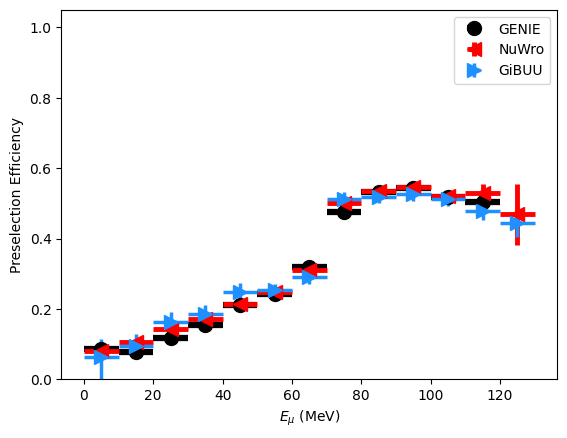

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:56<00:00,  5.30it/s]


[[0.0785420272085402, 0.025488591867622645, 0.019119735025174, 0.01825183703043065, 0.016288102593016773, 0.01439408427030181, 0.018524084453678258, 0.02326658621611888, 0.03681589059501639], [0.07761730193192096, 0.027620620077092983, 0.02088623845581261, 0.019654521653058366, 0.01691989494919821, 0.015292080576164546, 0.01878610713179507, 0.023838066061378838, 0.03436541960305173]]


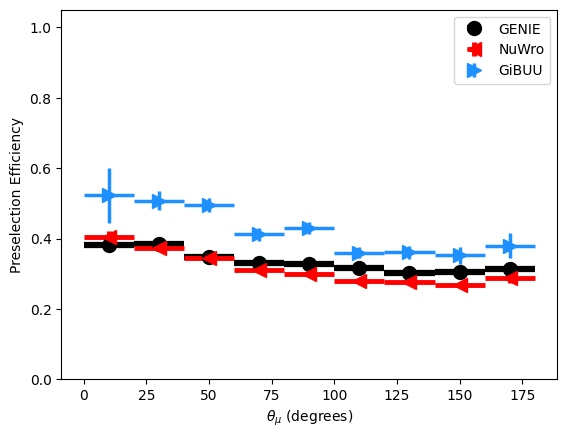

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:56<00:00,  5.34it/s]


[[0.011814759181332013, 0.015842146246849764, 0.019626847364145883, 0.025657379707064887, 0.030780149656429612, 0.027691729093852813, 0.03361558710273943, 0.04116984698762759, 0.05840496059121757, 0.08667376637458801, 0.24774160981178284, 0.010654490441083908, 0.013888888992369175], [0.009327869401864253, 0.017708167468800273, 0.019122393189605402, 0.02579861527834182, 0.027669657118905566, 0.025566355877611996, 0.038620347561507395, 0.04853601814631897, 0.06286824895785406, 0.07999290029207864, 0.25225839018821716, 0, 0]]


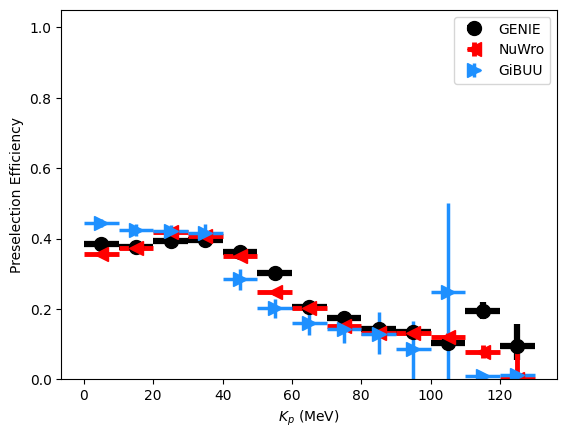

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.42it/s]


[[0.026309127388748466, 0.01986774820252024, 0.01859739415714784, 0.02192294145999152, 0.026889097809756013, 0.02775374324842428, 0.038110818704096605, 0.055088579654693604, 0.0798487663269043], [0.02614485844712261, 0.02133570580931793, 0.02002960249633623, 0.025354144704783255, 0.023763679729161657, 0.029794149471882192, 0.034591337471541694, 0.045307816741702756, 0.0764012336730957]]


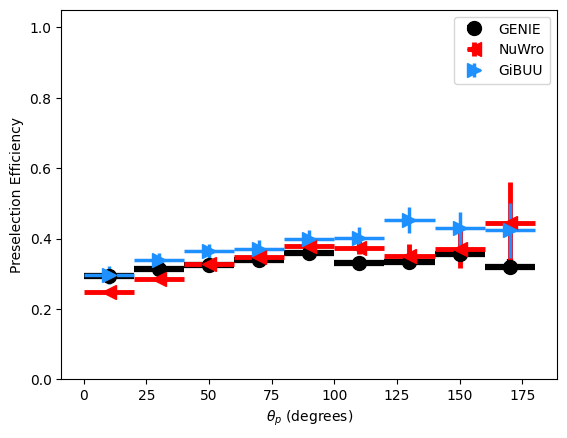

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:56<00:00,  5.31it/s]


[[0.15565105794656153, 0.06426843942380422, 0.023398790827833693, 0.013571228405705793, 0.016222767643128688, 0.01872882702348949, 0.022604259632887702, 0.019613144634176516, 0.02096322599253725, 0.028474890638622352, 0.03670987849242335, 0.05299398180556625], [0.1691974269019233, 0.06439293374073896, 0.02363130886515885, 0.01420916724867849, 0.01707082240076435, 0.0202510453704422, 0.018982596650254813, 0.026486407387789346, 0.022548672965203242, 0.03073588859853038, 0.034113681421560405, 0.05762245655059817]]


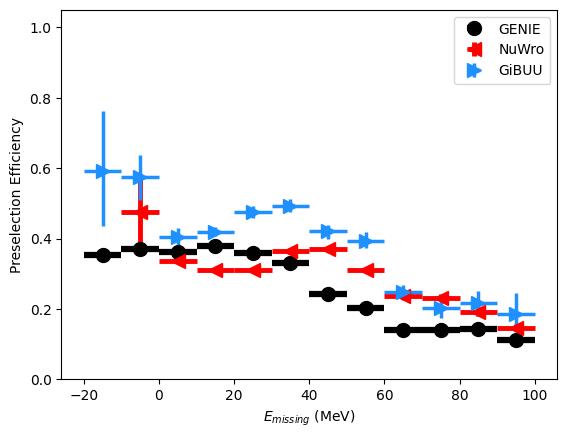

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.37it/s]


[[0.06850311142840282, 0.0406522585152192, 0.03872450325998633, 0.024220061933659665, 0.017402407805067577, 0.017101252162948555, 0.014233799598114272, 0.014930763277940018, 0.029884471510823962, 0.10603244536962264], [0.0751257103130597, 0.04723090583627876, 0.030996907732516288, 0.021260519448716098, 0.0205875778368117, 0.011935697179981497, 0.014382622539901191, 0.019750574895547046, 0.028860178059513686, 0.11715243992052582]]


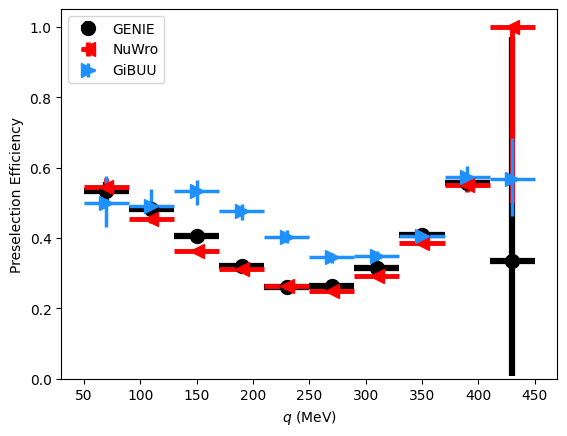

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.44it/s]


[[0.522438645362854, 0.10920826126547423, 0.05491503211569809, 0.041580826492798595, 0.031684865119813777, 0.02170881451889045, 0.01985420642180058, 0.014112740418679048, 0.01741363863066059, 0.016903305262195023, 0.024501235302887947, 0.04003701988019437, 0.47289785742759705], [0.477561354637146, 0.10402703285217285, 0.058962714312827735, 0.04024959062063349, 0.031923995966531726, 0.021629192352548232, 0.017132006749123574, 0.015595499020929049, 0.014494306375444077, 0.01971029474132907, 0.023898594964176456, 0.04537488096252984, 0.35910214257240236]]


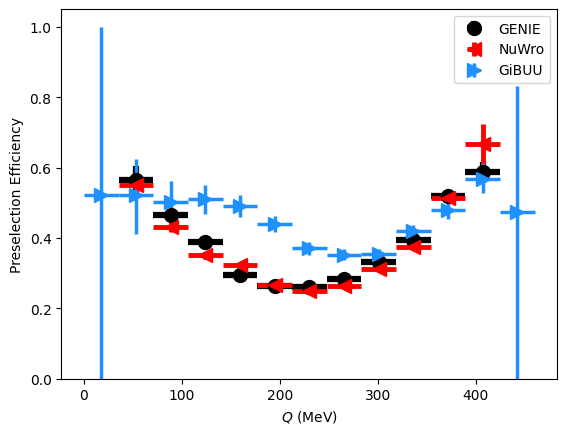

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:56<00:00,  5.34it/s]


[[0.036200492167139275, 0.0266130769252777, 0.02100409747383908, 0.017508216078108263, 0.020363577057631532, 0.018741033215311564, 0.01837650925930384, 0.019535690459873994, 0.023689680575411903, 0.024953084151325217, 0.029064499457364334, 0.034874436523345057, 0.035218192978065554], [0.03546176630714298, 0.02588692307472229, 0.01881523266149987, 0.02242878448831742, 0.017813741632544455, 0.020215304709455206, 0.020320834921082442, 0.018708753174829063, 0.020769294841716746, 0.02722988554947811, 0.028538120727933047, 0.031912541174681064, 0.04328227387534246]]


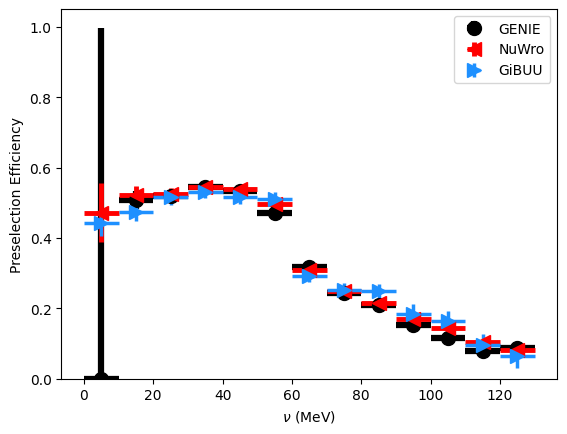

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:56<00:00,  5.27it/s]


[[0.14037295288509788, 0.1048391915984776, 0.0495227664067065, 0.03369160307204261, 0.027847677253305225, 0.024458419251574215, 0.02122595679785294, 0.021376062998768153, 0.019017679311967906, 0.022935180816251177, 0.025709491642034676, 0.028480935803850416, 0.0294802928588207, 0.033247825245581564, 0.029572192579456147, 0.03631708069545464, 0.03621953839087205, 0.04398279740892608, 0.056103292264436444, 0.06541056408843454], [0.13157149155934655, 0.09989019709063651, 0.04330472650355344, 0.0359926297935374, 0.026354572557267697, 0.025836028104007702, 0.02215334244967493, 0.022630399120530664, 0.02128089555558027, 0.022010157169794597, 0.022205084867212233, 0.02729460245393983, 0.02685933897664755, 0.03524483010847579, 0.03788718912336564, 0.03398065119849736, 0.04464212168817938, 0.0411228546522614, 0.04565591548008341, 0.07708986832189935]]


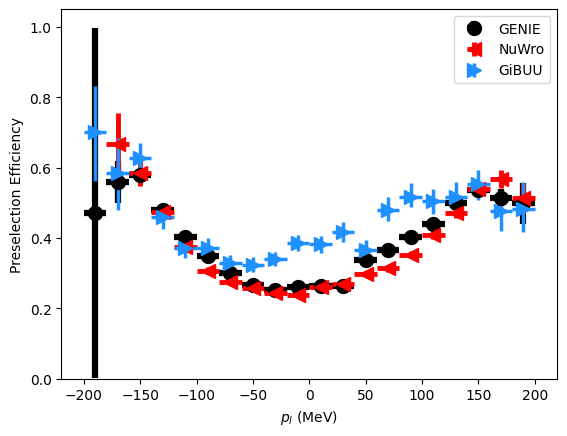

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.37it/s]


[[0.04700295480007821, 0.035693953814626755, 0.026709359533646504, 0.024285159034878157, 0.021021623841313897, 0.016644030168733837, 0.016782448391971627, 0.016384854807405924, 0.018848587166555353, 0.0271970655641825], [0.043673747467743385, 0.038258994166185, 0.029689268394284873, 0.025593808426391362, 0.021037834913305853, 0.017988860367771142, 0.015117724652195963, 0.014896646827703142, 0.017253052210310482, 0.03807037755746334]]


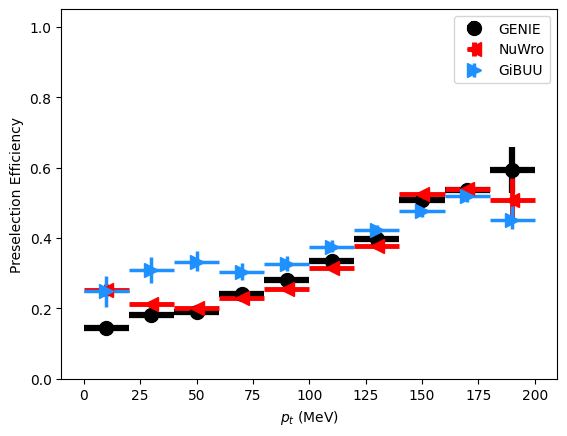

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.43it/s]


[[0.027735581621527672, 0.055527929216623306, 0.06139640478784052, 0.047360157703867506, 0.030867065570151148, 0.028201178167420654, 0.0178938752672754, 0.02093675367169784, 0.02154536185308803, 0.017991408651040985, 0.01664867692955857, 0.016656738397418658, 0.022440601268233773, 0.0685137584060696, 0.16820517513487077], [0, 0.07780540411671003, 0.07307416968273395, 0.04767910633460587, 0.042690212638289815, 0.02437899454676523, 0.026081310350112963, 0.026454967359080706, 0.020925378049109933, 0.02222679902915836, 0.017739832502132513, 0.014918729454927948, 0.025358744994760152, 0.06780987674907102, 0.1651281581984626]]


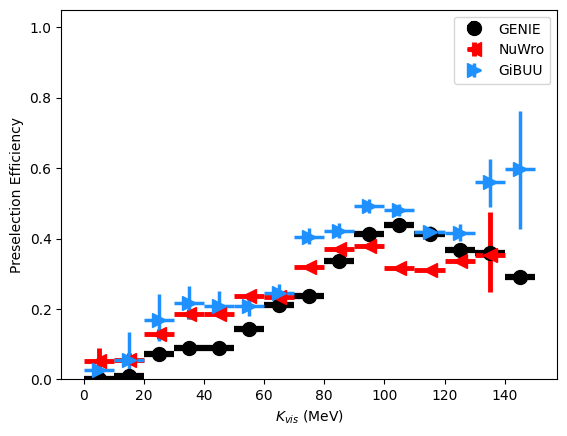

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:56<00:00,  5.32it/s]


[[0.006779749556927395], [0.007311842249896838]]


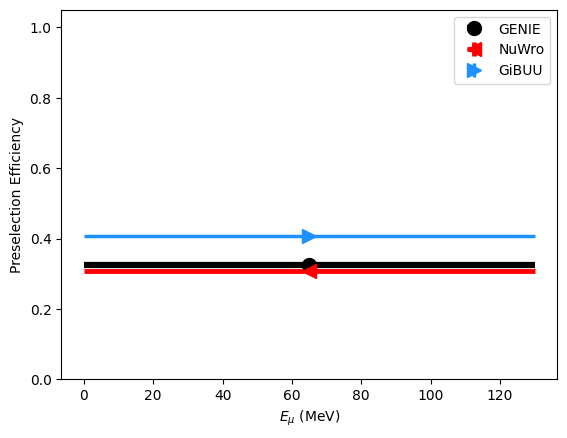

In [181]:
this_truth_vars = ["truth_Emuon","true_angle_deg","truth_prim_p_energy","true_angle_P_deg","true_Em","true_q","true_sqrtQ2","true_nu","true_pl","true_pt","true_KE","truth_Emuon"]
this_xlabels = [f"$E_\mu$ (MeV)","$\\theta_\mu$ (degrees)",f"$K_p$ (MeV)","$\\theta_p$ (degrees)","$E_{missing}$ (MeV)","$q$ (MeV)","$Q$ (MeV)","$\\nu$ (MeV)","$p_l$ (MeV)","$p_t$ (MeV)","$K_{vis}$ (MeV)",f"$E_\mu$ (MeV)"]

this_bins_list = []
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(0,180,10))
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(0,180,10))
this_bins_list.append(np.linspace(-20,100,13))
this_bins_list.append(np.linspace(50,450,11))
this_bins_list.append(np.linspace(0,460,14))
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(-200,200,21))
this_bins_list.append(np.linspace(0,200,11))
this_bins_list.append(np.linspace(0,150,16))
this_bins_list.append(np.linspace(0,130,2))

this_sig_query = "is_KDAR==1"
this_sel_query = kdar.presel_query

plot_eff(this_truth_vars,this_sig_query,this_sel_query,this_bins_list,xlabels=this_xlabels,ylabel="Preselection Efficiency")

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.39it/s]


[[0.37806347012519836, 0.1363762617111206, 0.06940612237721205, 0.05449208884130152, 0.03985389370954673, 0.033949003653855336, 0.028084191737844266, 0.020897604931574554, 0.020494821278945308, 0.023564551070496265, 0.023317282406797313, 0.02564881437818778, 0.035435177902470194], [0.2219365298748016, 0.1136237382888794, 0.08175697922706604, 0.05168133023534338, 0.044210991786636455, 0.03500874851519109, 0.03293619014470961, 0.021450535690963446, 0.01736995924945084, 0.022667397324620087, 0.02465270292805688, 0.02401402102285255, 0.04279855056783932]]


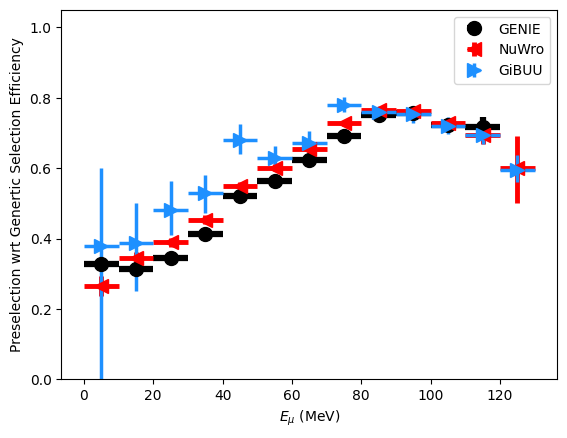

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:54<00:00,  5.49it/s]


[[0.07282221979565096, 0.03134523234524578, 0.020185072463046683, 0.02276797052742774, 0.018506788940288676, 0.024538855709935747, 0.02571433562036407, 0.029925912408267696, 0.047886475413698615], [0.07562609312074708, 0.036032297617853204, 0.021540463348911243, 0.02272937835910449, 0.01802284261835929, 0.02076235329735221, 0.023835448135748782, 0.0389052523942679, 0.03214342119819236]]


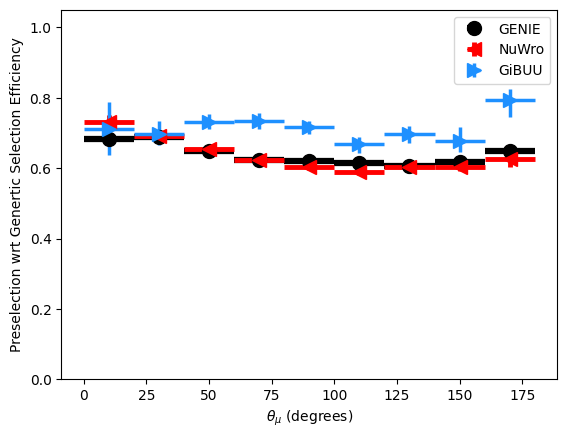

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.42it/s]


[[0.011862505829301373, 0.021916152393243293, 0.025011323761428006, 0.028701525549583162, 0.05388628280254282, 0.044677127467261435, 0.08088505623846776, 0.1122149837017059, 0.15579461199896677, 0.2919290065765381, 0.43090832233428955, 0.03681788221001625, 0.02777777798473835], [0.011907115877663466, 0.01841553697152387, 0.02008593211943399, 0.03152507543563843, 0.04587341979553139, 0.05656218877205477, 0.08052529634967931, 0.08604588586351147, 0.1558936996893449, 0.20807099342346191, 0.5690916776657104, 0, 0]]


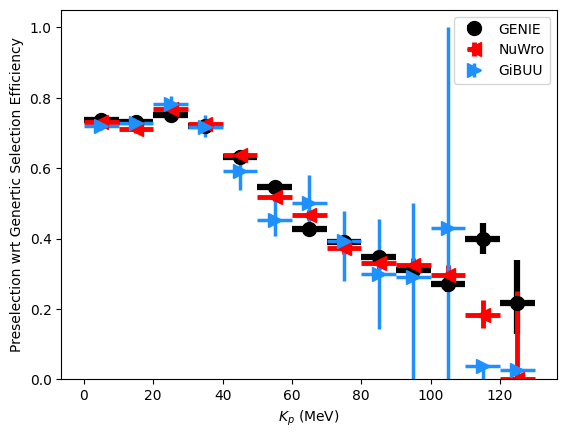

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:54<00:00,  5.53it/s]


[[0.0488490261424851, 0.02716165794231018, 0.023281260594440578, 0.02746484310424635, 0.03653864622195968, 0.04370907554974934, 0.04522136774829033, 0.062146829449723606, 0.1021981605922474], [0.043249885241190555, 0.02863186441159893, 0.023692750575293964, 0.026728464681965547, 0.026410335274779984, 0.03354714023388494, 0.045750742241487674, 0.05363723098186024, 0.10952732960383094]]


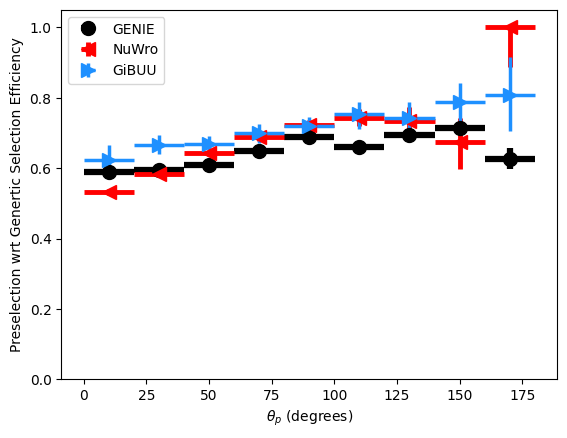

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:53<00:00,  5.58it/s]


[[0.13177818059921265, 0.043802511692047075, 0.027970817521628666, 0.0185443607129816, 0.02010456396452731, 0.0209639258587897, 0.025031805424920894, 0.031460021306917274, 0.04159304985633261, 0.051615360664994725, 0.08949008120430846, 0.08684643507003786], [0.1321107082896762, 0.06119748830795291, 0.02546946693967267, 0.021938402013680358, 0.019686741472810576, 0.020346741888475184, 0.027902353622829668, 0.03294196954545903, 0.047868767951242064, 0.053407470385233524, 0.06198889777467054, 0.0957622605821361]]


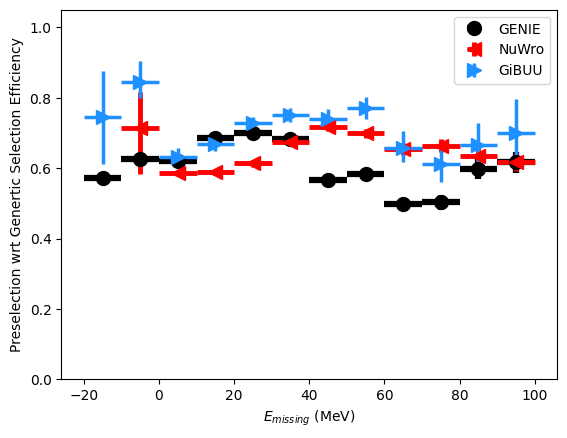

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:54<00:00,  5.55it/s]


[[0.08778675054681717, 0.04422243303006834, 0.032030729821166615, 0.023448641080966004, 0.021496431567738727, 0.021116298908846032, 0.019099534384189987, 0.022505943877668355, 0.026217416593831366, 0.10715885957082116], [0.08484773221180353, 0.054436481006241544, 0.03227391026236792, 0.022443551857951327, 0.023041269936649456, 0.020085119092713266, 0.01825898582467489, 0.0193350896256399, 0.024018543907719847, 0.10852741493898277]]


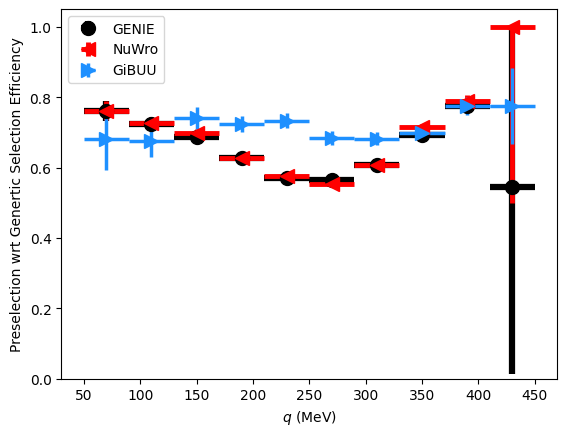

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:54<00:00,  5.51it/s]


[[0.7738834619522095, 0.10492041110992434, 0.06378220656709199, 0.04122228840040176, 0.031868177563154854, 0.027404665927229233, 0.021401465007741094, 0.02428278198296019, 0.019398176873657635, 0.024795241313545602, 0.028031234204102362, 0.03602361112337815, 0.5785744786262512], [0.22611653804779053, 0.12841292222340905, 0.0693314751857469, 0.0477973989466457, 0.03517326994368297, 0.025002008155084465, 0.026283113650103496, 0.022249838363532115, 0.020364645099966938, 0.02206215781431098, 0.02837320460213555, 0.046082583142913025, 0.4214255213737488]]


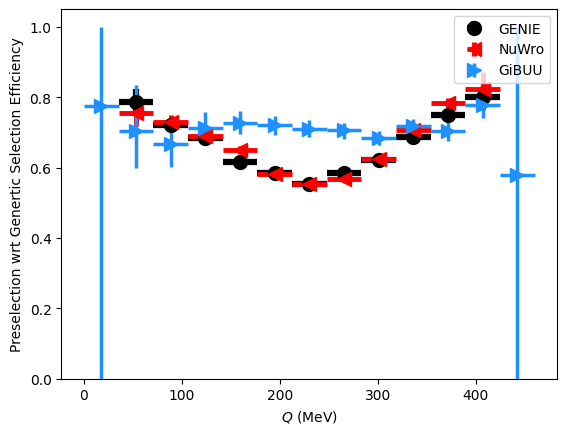

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:54<00:00,  5.50it/s]


[[0.03821650587994119, 0.031585282551225724, 0.02046516400123566, 0.022138219252682778, 0.01904545617583886, 0.01913090758774738, 0.030316871211434004, 0.03682984414066892, 0.042769208377152035, 0.05320199669861214, 0.07470731427765342, 0.10851175917519462, 0.3817045986652374], [0.05294175498962406, 0.024640957098711058, 0.02504370359643182, 0.020078520642829556, 0.02057321654658617, 0.021225798130035445, 0.032825123994781435, 0.03703229807927111, 0.03817672295226726, 0.05195343850165135, 0.0683896124362946, 0.14374967873330213, 0.24996206800142906]]


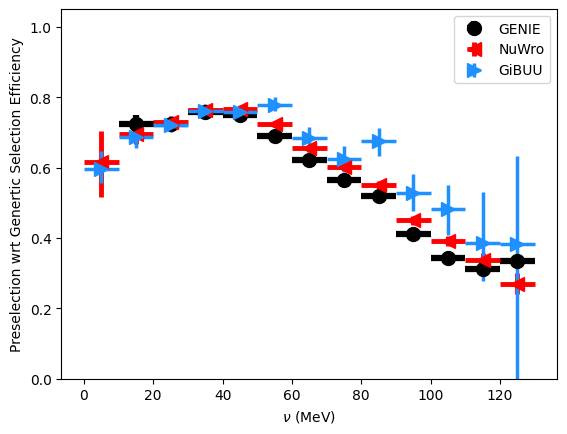

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.41it/s]


[[0.11132071673268018, 0.09200920427546777, 0.033398378356124914, 0.04210332325060073, 0.033010821803753476, 0.03379808592951006, 0.032641134460065446, 0.0297804986832797, 0.030934321809921617, 0.03449573787539284, 0.03512789408421868, 0.03183156539412557, 0.03997493663915508, 0.035721229208194205, 0.03270967304027761, 0.03950276717408663, 0.044186979483601285, 0.044856383253675025, 0.05676910145562675, 0.08147117069789345], [0.09621463680267339, 0.09684528488861888, 0.03297146185334909, 0.043646230054938284, 0.03954384508682873, 0.02770728974843839, 0.034468279977928784, 0.036499503844249936, 0.02933375122196491, 0.02901200329173692, 0.036764601701977595, 0.037270882900167224, 0.03670458527777687, 0.03054442424570525, 0.02864347132865952, 0.038309669471113694, 0.046410716540181696, 0.03803545934608188, 0.05647107093564929, 0.06823720877792783]]


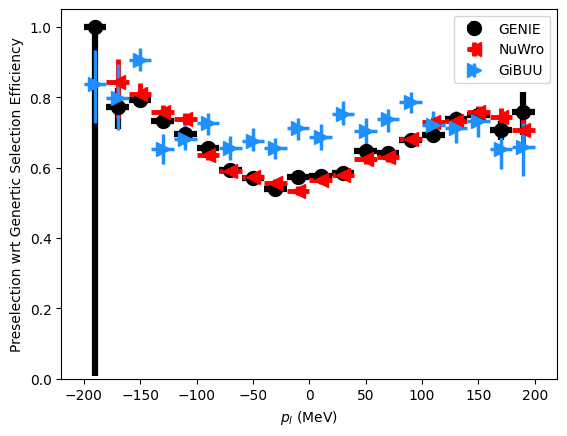

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:55<00:00,  5.43it/s]


[[0.07619870341790691, 0.052225046006863396, 0.04012195747794833, 0.04185834708244973, 0.030506901018982013, 0.021513232985358566, 0.017889080099234955, 0.01867458786035303, 0.024689133056525647, 0.03463076936966414], [0.08509859387939045, 0.058425256277059634, 0.03356625240846978, 0.037444465104949254, 0.029002237365981287, 0.025588960199405597, 0.017840007170466077, 0.01858251750301021, 0.023170765516748237, 0.03722074089116145]]


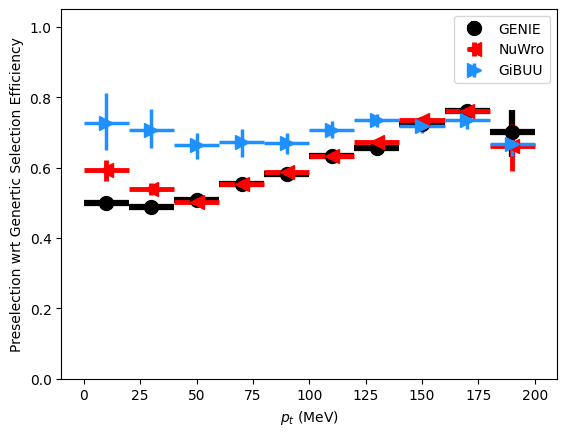

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:57<00:00,  5.24it/s]


[[0.3815661370754242, 0.6393996477127075, 0.18152048852708602, 0.09272297791072304, 0.07865838117377699, 0.046846792269288784, 0.04265659680004008, 0.0267663519540412, 0.022281262726375872, 0.02246383176621458, 0.020946495236529583, 0.019440281759674494, 0.027871557697210947, 0.06786407415683449, 0.16107037067413332], [0, 0.3606003522872925, 0.2629239559173584, 0.09446914031587794, 0.0708655945668748, 0.05802212158838904, 0.04566360675371606, 0.029090210490756552, 0.025007511403845273, 0.020056898188012928, 0.018432019511911424, 0.017902347210478675, 0.028566134452819858, 0.05227452598176552, 0.2389296293258667]]


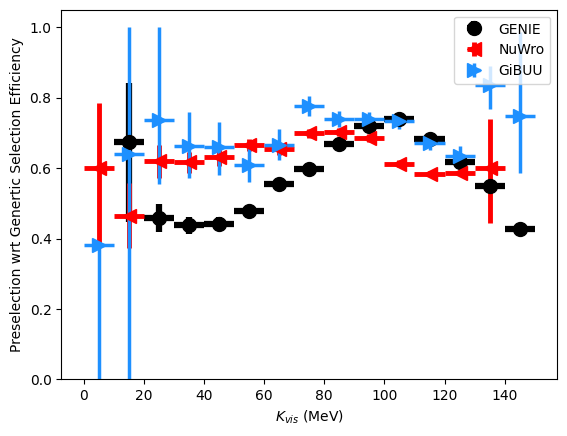

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:54<00:00,  5.48it/s]


[[0.008821433325931771], [0.007890676720460177]]


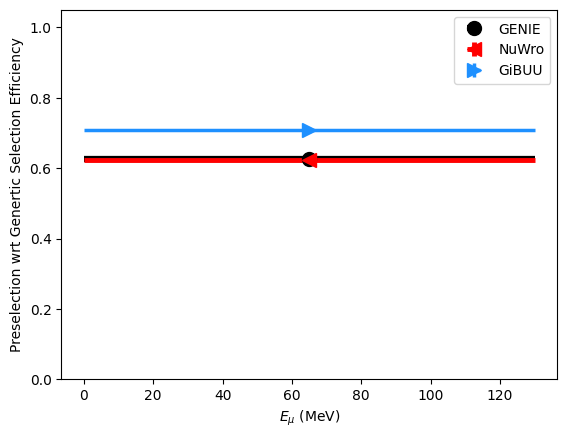

In [182]:
this_truth_vars = ["truth_Emuon","true_angle_deg","truth_prim_p_energy","true_angle_P_deg","true_Em","true_q","true_sqrtQ2","true_nu","true_pl","true_pt","true_KE","truth_Emuon"]
this_xlabels = [f"$E_\mu$ (MeV)","$\\theta_\mu$ (degrees)",f"$K_p$ (MeV)","$\\theta_p$ (degrees)","$E_{missing}$ (MeV)","$q$ (MeV)","$Q$ (MeV)","$\\nu$ (MeV)","$p_l$ (MeV)","$p_t$ (MeV)","$K_{vis}$ (MeV)",f"$E_\mu$ (MeV)"]

this_bins_list = []
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(0,180,10))
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(0,180,10))
this_bins_list.append(np.linspace(-20,100,13))
this_bins_list.append(np.linspace(50,450,11))
this_bins_list.append(np.linspace(0,460,14))
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(-200,200,21))
this_bins_list.append(np.linspace(0,200,11))
this_bins_list.append(np.linspace(0,150,16))
this_bins_list.append(np.linspace(0,130,2))

this_sig_query = "is_KDAR==1 and ssm_kine_reco_Enu>0"
this_sel_query = kdar.presel_query

plot_eff(this_truth_vars,this_sig_query,this_sel_query,this_bins_list,xlabels=this_xlabels,ylabel="Preselection wrt Genertic Selection Efficiency")

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:53<00:00,  5.64it/s]


[[0.8620424866676331, 0.1439034223556519, 0.054342126513040157, 0.047349750601412, 0.03594518311505246, 0.027793364811179444, 0.034556023652213, 0.019259205904107124, 0.018837158413312904, 0.01810577782494638, 0.022403370056898186, 0.030329427633627448, 0.04204687731897738], [0.13795751333236694, 0.15609657764434814, 0.06433015025180322, 0.047585846118207265, 0.03231023095688734, 0.030899404799993646, 0.02917419682806277, 0.021064235785650864, 0.01921358046218813, 0.018631855730322555, 0.02015563833652745, 0.025177753724971774, 0.046374257102157146]]


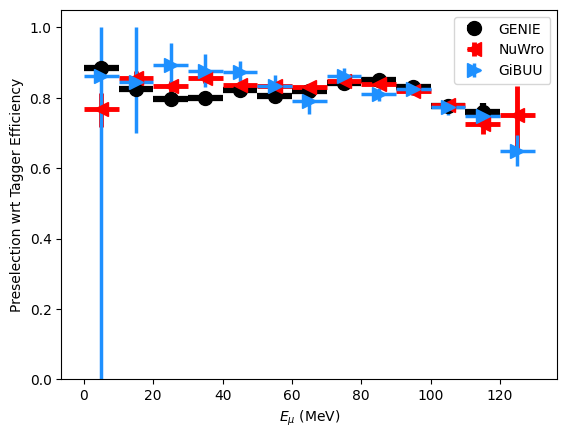

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:52<00:00,  5.77it/s]


[[0.06593503149336988, 0.030913595706879682, 0.020096122596024446, 0.016748050619396215, 0.016952508113138975, 0.01788939942415535, 0.019010764811535297, 0.02646551073336012, 0.03730302981319977], [0.08599422536299894, 0.03114991514801646, 0.021911991456417756, 0.02157956143054862, 0.015438400718768452, 0.01989980388137147, 0.024959069616116714, 0.03016295378808509, 0.039118158817291304]]


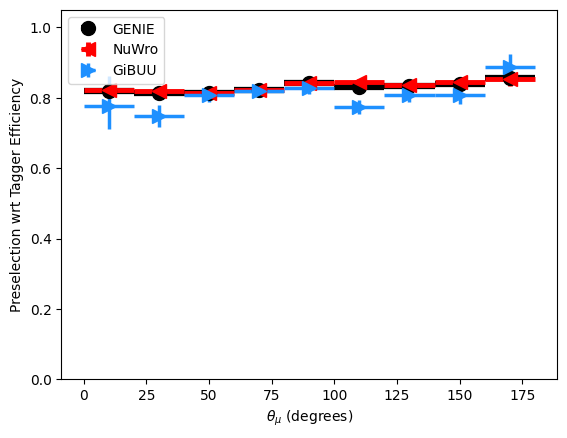

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:52<00:00,  5.72it/s]


[[0.011284680995605867, 0.018922129149487432, 0.01884389758721383, 0.02908383529198355, 0.038817622444846434, 0.058476689069167476, 0.04141712188720703, 0.1097158312797546, 0.11804194450378414, 0.8806383609771729, 0.9139465689659119, 0.9032257795333862, 0.5], [0.011308650163744605, 0.021366158928075585, 0.0160240545617375, 0.027629689543772096, 0.03854705885086929, 0.05655954281489051, 0.08358287811279297, 0.09028416872024536, 0.08195805549621582, 0.11936163902282715, 0.08605343103408813, 0, 0]]


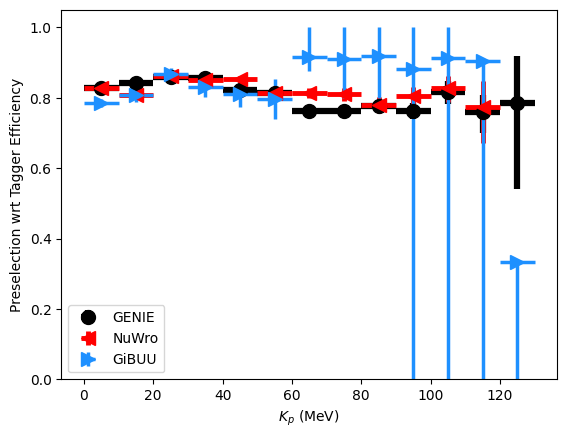

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:51<00:00,  5.81it/s]


[[0.04875150329307798, 0.025206251404502167, 0.023093259998324678, 0.022273045595122776, 0.025594299996805514, 0.026681328210237054, 0.03542213120012205, 0.046093124516156214, 0.0833195567131042], [0.04204690894522811, 0.023399809201558486, 0.019644838434090817, 0.0251139423667347, 0.028422932710431836, 0.0299889014515623, 0.041808398865459506, 0.04024910468321585, 0.11668044328689575]]


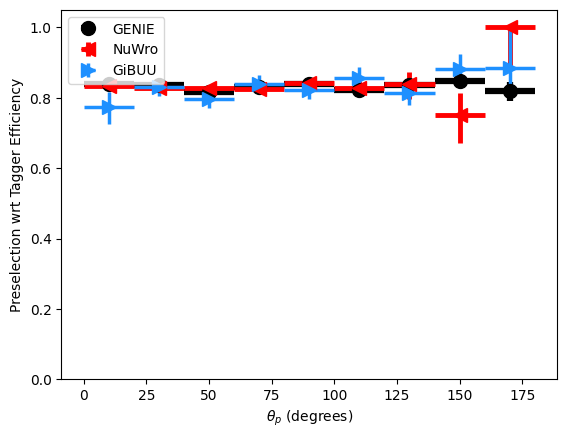

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:52<00:00,  5.67it/s]


[[0.149529774983724, 0.04611736501531394, 0.025412094972773525, 0.015099873727968172, 0.016607788876660923, 0.01773869257572991, 0.023634452943995243, 0.02042602218989753, 0.04220060576086515, 0.058182561839068336, 0.05487516214107646, 0.0810263582638332], [0.18380355834960938, 0.047433462407853844, 0.030997718119359252, 0.017417860222521897, 0.015099711673458693, 0.019309033867661696, 0.024320810646205726, 0.02569196547303243, 0.04361094283585498, 0.05212339629297669, 0.05721777534739858, 0.07770380046632552]]


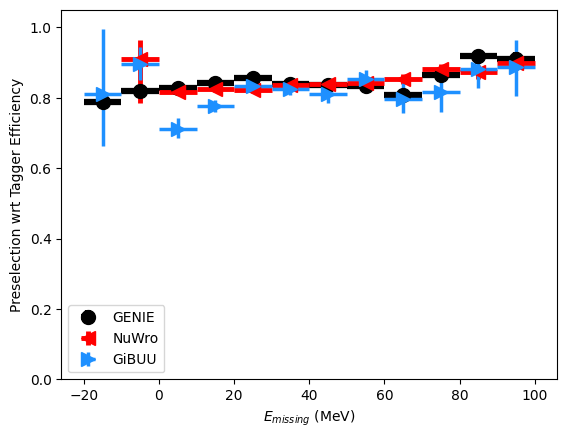

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:52<00:00,  5.70it/s]


[[0.08890914300392416, 0.04866280510455745, 0.02874941958321464, 0.025233961519410375, 0.02494831999645386, 0.017381830608513393, 0.0191959190040476, 0.01917169527168261, 0.02551289646363697, 0.12378629048665368], [0.09462812062232728, 0.048029111005065794, 0.02887874984916461, 0.024081801760909904, 0.021563581057957193, 0.01884766513364522, 0.017278346941713818, 0.020628758576050066, 0.025991223741311353, 0.09189998402315025]]


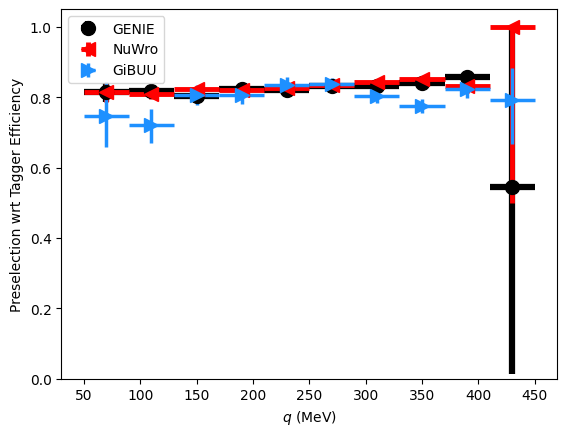

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:53<00:00,  5.66it/s]


[[0.8248211741447449, 0.11277379592259729, 0.06728550143863843, 0.03821034886376773, 0.029391607311820556, 0.025305301943479686, 0.021434936363368462, 0.020845400201834674, 0.020882420896672915, 0.01842345816658586, 0.028085401030092827, 0.0467130917367482, 0.5853763222694397], [0.17517882585525513, 0.10291247858720665, 0.053405079514452725, 0.04083158223603223, 0.03273610069336319, 0.022291475867435073, 0.024175756523403646, 0.016657025926375302, 0.021219959988633352, 0.019924015191184363, 0.02672265839312793, 0.03981938066706714, 0.4146236777305603]]


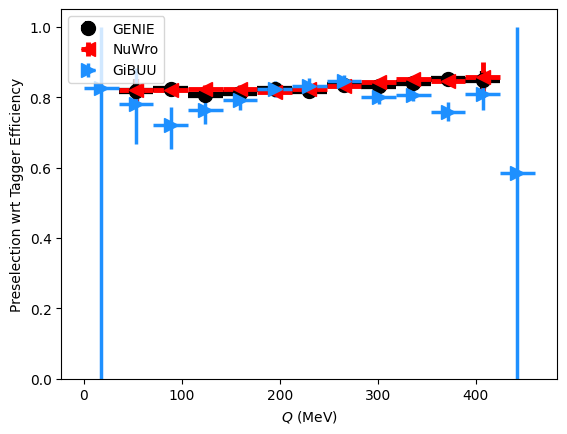

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:52<00:00,  5.67it/s]


[[0.04574156662092266, 0.028404542210798245, 0.020840091459770727, 0.015633251711039686, 0.018811980539794493, 0.016323620227171376, 0.025223142056940318, 0.02624373458185647, 0.036717097983005376, 0.05037879485350394, 0.051922892370531604, 0.1312390093803405, 0.8648611903190613], [0.04294070198544464, 0.026816270568154055, 0.022322768070658694, 0.022049989197599373, 0.018995277834955027, 0.018987287576711198, 0.026089572719691922, 0.03449659396624338, 0.03563599568415465, 0.04577505130034232, 0.0677007635434469, 0.15676099061965942, 0.13513880968093872]]


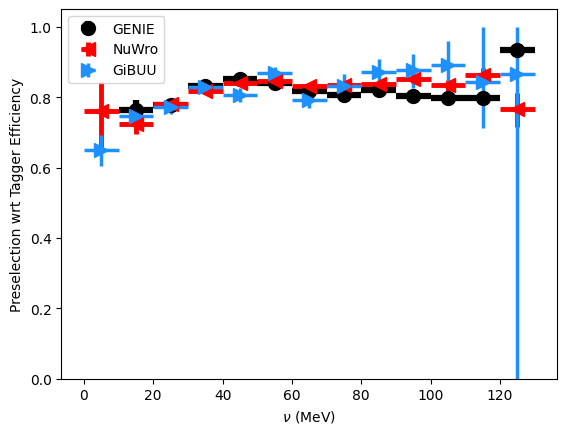

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:53<00:00,  5.57it/s]


[[0.12035453982167421, 0.08152397654273291, 0.027437588747809882, 0.039780175586141886, 0.033891599646785786, 0.02818725996608884, 0.0313884220802676, 0.03300938540334286, 0.03147197826551462, 0.02460806901663104, 0.029476383288848274, 0.028329997421460473, 0.041770285065494406, 0.030667808468371915, 0.03475548432782405, 0.03916759881298104, 0.03288439725694203, 0.03690107247645402, 0.05654475603463516, 0.08741060369893128], [0.1544506549835205, 0.08678224355296082, 0.029049204896302472, 0.04008086441970904, 0.036426825524122686, 0.026751547361441363, 0.029234946840660858, 0.03453810438767324, 0.02748710542716659, 0.026391557939760002, 0.030222907506754826, 0.026733434258194966, 0.03437630009601611, 0.028478297495072913, 0.03298938662855777, 0.040620011806488, 0.04957447720193242, 0.046362745692882124, 0.068363448046738, 0.09582526374746247]]


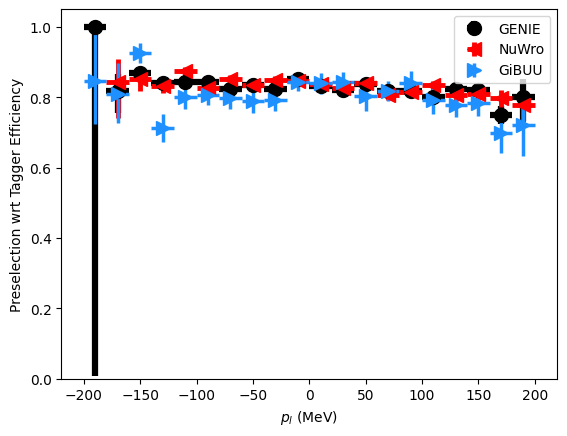

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:52<00:00,  5.67it/s]


[[0.060668483948362106, 0.04898126257790458, 0.03453290117673635, 0.03161586636196856, 0.02470496439964731, 0.019438991699211483, 0.017046294080491742, 0.015048223175455955, 0.021687265440869852, 0.03442341286073425], [0.042686207127152764, 0.05079198005248087, 0.0362513674838959, 0.032125625345442055, 0.026218373723523314, 0.019408737791011155, 0.017016184839709125, 0.016727673961034917, 0.020224190185342605, 0.03441333391651602]]


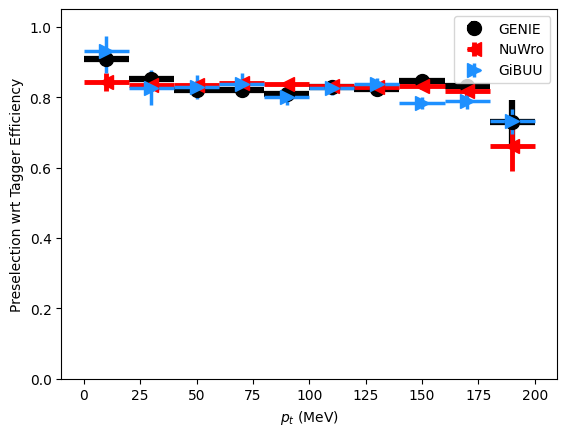

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:53<00:00,  5.64it/s]


[[0.8239401578903198, 0.9292370676994324, 0.11135135094324744, 0.06642688217617221, 0.05915668181010658, 0.04593084539685932, 0.03816616344104906, 0.02914174861672747, 0.025073855115263277, 0.021651116979267027, 0.016874012055568044, 0.018684626449249953, 0.030561565238738764, 0.05311248064041141, 0.15154190858205163], [0, 0.07076293230056763, 0.05531531572341919, 0.07154930830001827, 0.05691474676132202, 0.05297025350423956, 0.03552938958633045, 0.020337760513544745, 0.023613507039976667, 0.01887951597241866, 0.017812362593463305, 0.01656604215214763, 0.02784616181040489, 0.052833465305534566, 0.18179142475128174]]


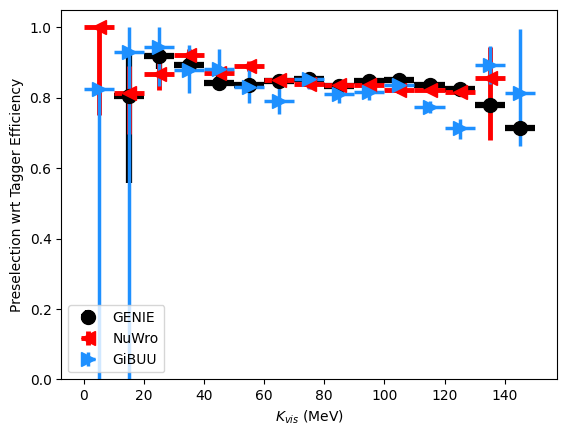

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:53<00:00,  5.57it/s]


[[0.009509898470862588], [0.008425341897065008]]


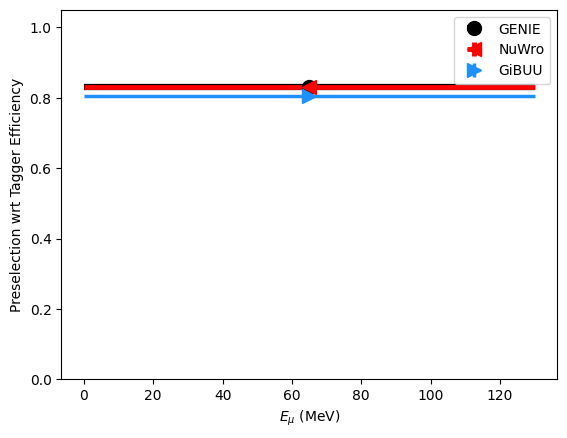

In [17]:
this_truth_vars = ["truth_Emuon","true_angle_deg","truth_prim_p_energy","true_angle_P_deg","true_Em","true_q","true_sqrtQ2","true_nu","true_pl","true_pt","true_KE","truth_Emuon"]
this_xlabels = [f"$E_\mu$ (MeV)","$\\theta_\mu$ (degrees)",f"$K_p$ (MeV)","$\\theta_p$ (degrees)","$E_{missing}$ (MeV)","$q$ (MeV)","$Q$ (MeV)","$\\nu$ (MeV)","$p_l$ (MeV)","$p_t$ (MeV)","$K_{vis}$ (MeV)",f"$E_\mu$ (MeV)"]

this_bins_list = []
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(0,180,10))
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(0,180,10))
this_bins_list.append(np.linspace(-20,100,13))
this_bins_list.append(np.linspace(50,450,11))
this_bins_list.append(np.linspace(0,460,14))
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(-200,200,21))
this_bins_list.append(np.linspace(0,200,11))
this_bins_list.append(np.linspace(0,150,16))
this_bins_list.append(np.linspace(0,130,2))

this_sig_query = "is_KDAR==1 and ssm_kine_reco_Enu>0 and ssm_kine_energy>0"
this_sel_query = kdar.presel_query

plot_eff(this_truth_vars,this_sig_query,this_sel_query,this_bins_list,xlabels=this_xlabels,ylabel="Preselection wrt Tagger Efficiency")

In [36]:
if(0):
    genie_train_event_list = ""
    kdar_overlay_df = kdar.label_train(kdar_overlay_df,genie_train_event_list)
    
    nuwro_train_event_list = ""
    nuwro_df = kdar.label_train(nuwro_df,nuwro_train_event_list)
    
    gibuu_train_event_list = ""
    gibuu_df = kdar.label_train(gibuu_df,gibuu_train_event_list)

print("GENIE",kdar_overlay_df.shape[0])
print("NuWro",nuwro_df.shape[0])
print("GiBUU",gibuu_df.shape[0])
if(1):
    kdar_overlay_df = kdar_overlay_df.query("event%10>=4")#.reset_index()
    nuwro_df = nuwro_df.query("event%10>=5")#.reset_index()
    gibuu_df = gibuu_df.query("event%10>=5")#.reset_index()
print("")
print("GENIE",kdar_overlay_df.shape[0])
print("NuWro",nuwro_df.shape[0])
print("GiBUU",gibuu_df.shape[0])

GENIE 84722
NuWro 37514
GiBUU 191392

GENIE 50734
NuWro 18833
GiBUU 95495


Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:52<00:00,  5.76it/s]


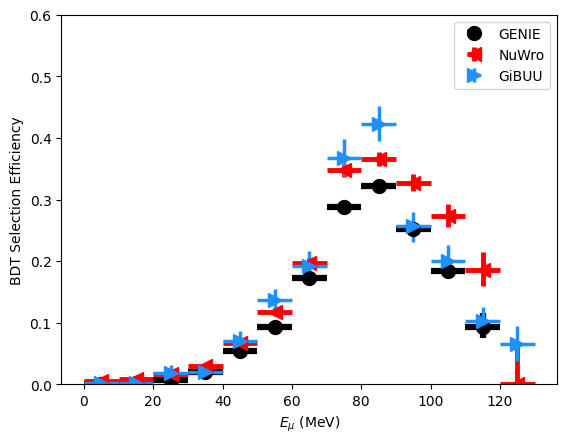

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:49<00:00,  6.01it/s]


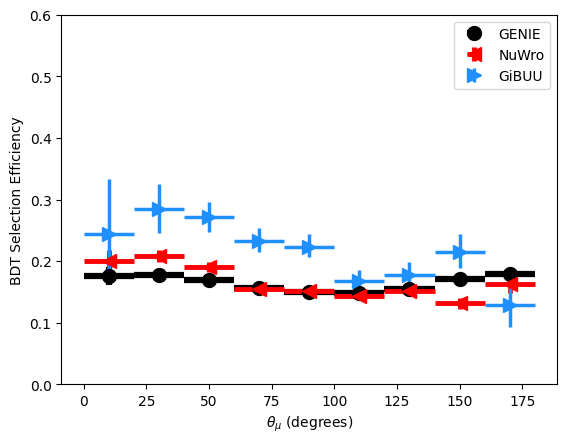

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:49<00:00,  6.07it/s]


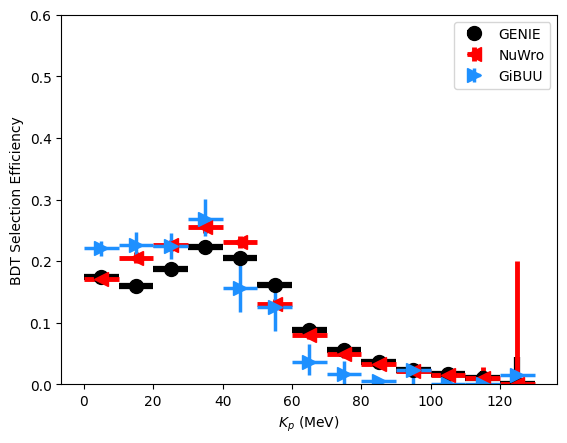

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:49<00:00,  6.03it/s]


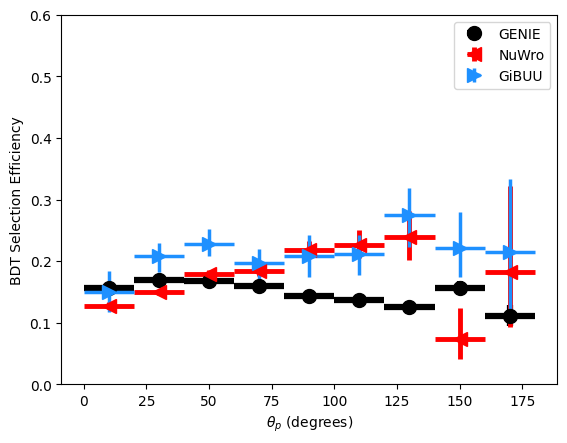

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:49<00:00,  6.07it/s]


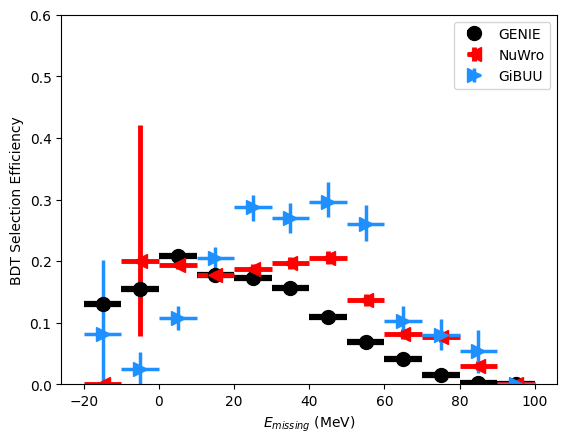

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:52<00:00,  5.70it/s]


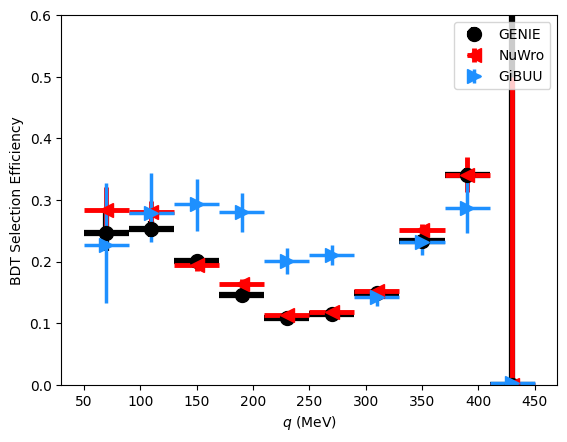

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:51<00:00,  5.82it/s]


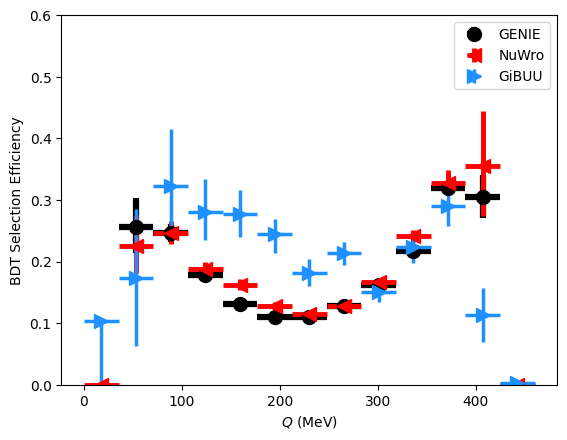

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:52<00:00,  5.73it/s]


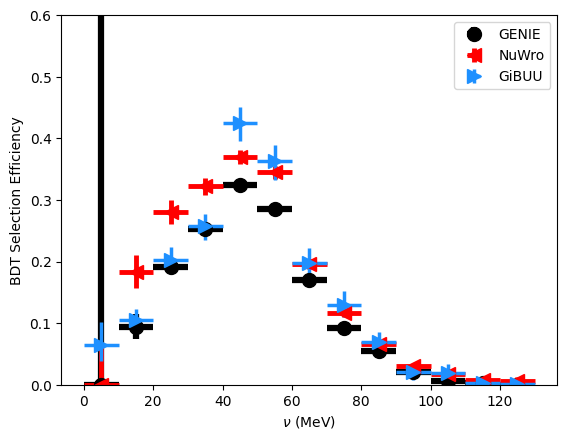

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:50<00:00,  5.98it/s]


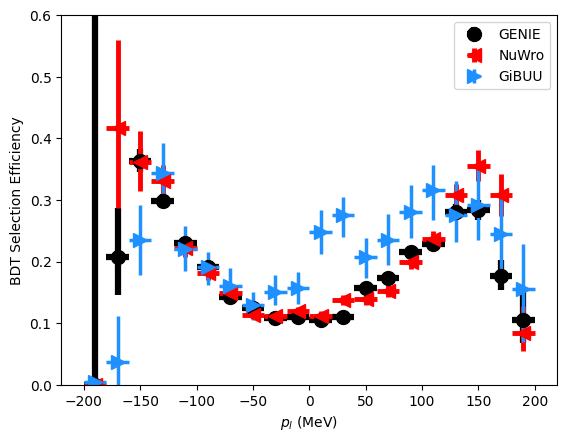

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:49<00:00,  6.04it/s]


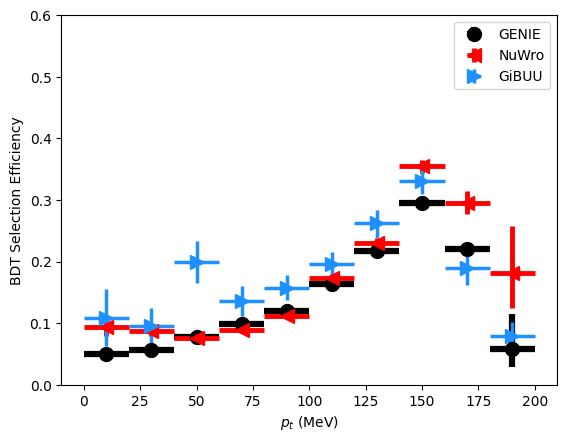

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:50<00:00,  5.90it/s]


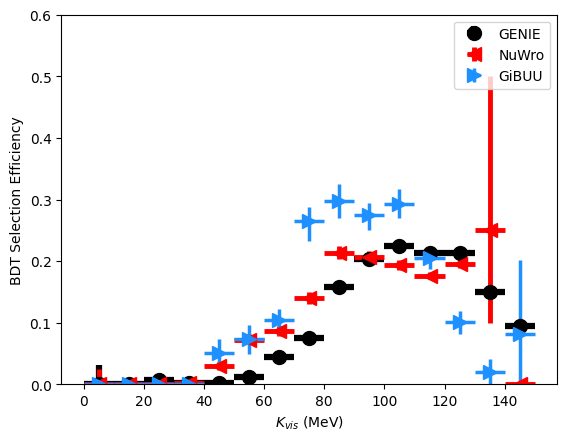

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:51<00:00,  5.86it/s]


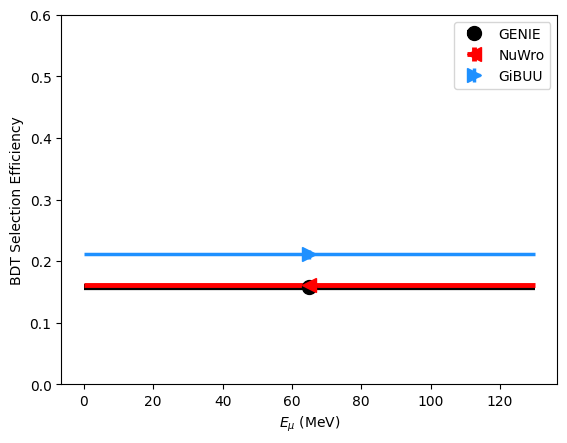

In [45]:
this_truth_vars = ["truth_Emuon","true_angle_deg","truth_prim_p_energy","true_angle_P_deg","true_Em","true_q","true_sqrtQ2","true_nu","true_pl","true_pt","true_KE","truth_Emuon"]
this_xlabels = [f"$E_\mu$ (MeV)","$\\theta_\mu$ (degrees)",f"$K_p$ (MeV)","$\\theta_p$ (degrees)","$E_{missing}$ (MeV)","$q$ (MeV)","$Q$ (MeV)","$\\nu$ (MeV)","$p_l$ (MeV)","$p_t$ (MeV)","$K_{vis}$ (MeV)",f"$E_\mu$ (MeV)"]

this_bins_list = []
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(0,180,10))
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(0,180,10))
this_bins_list.append(np.linspace(-20,100,13))
this_bins_list.append(np.linspace(50,450,11))
this_bins_list.append(np.linspace(0,460,14))
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(-200,200,21))
this_bins_list.append(np.linspace(0,200,11))
this_bins_list.append(np.linspace(0,150,16))
this_bins_list.append(np.linspace(0,130,2))

lowE_cut = 0.8
hiE_cut = 0.9
this_sig_query = "is_KDAR==1"
this_sel_query = f"kdar_score_hiE>{hiE_cut} and kdar_score_lowE>{lowE_cut}"

plot_eff(this_truth_vars,this_sig_query,this_sel_query,this_bins_list,xlabels=this_xlabels,ylabel="BDT Selection Efficiency",adjusty=0.6)

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:52<00:00,  5.76it/s]


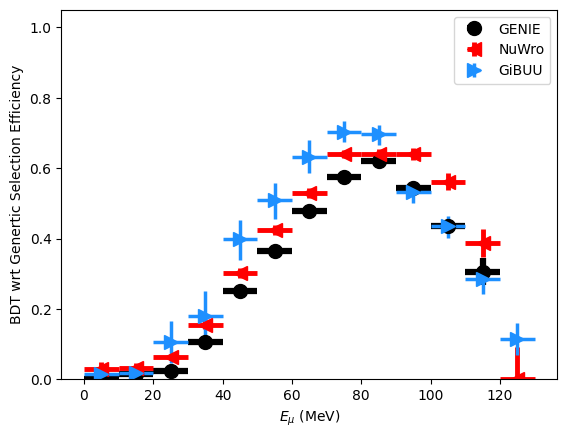

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:51<00:00,  5.79it/s]


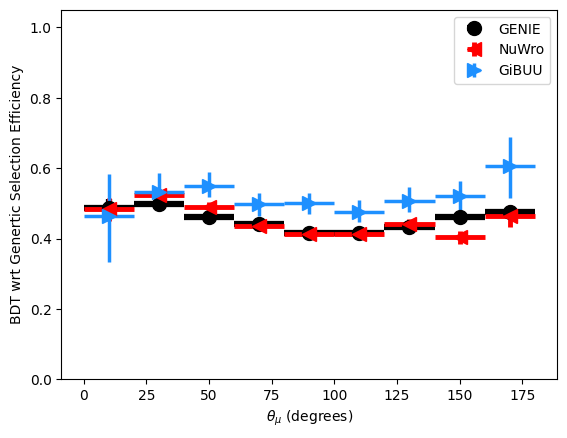

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:52<00:00,  5.77it/s]


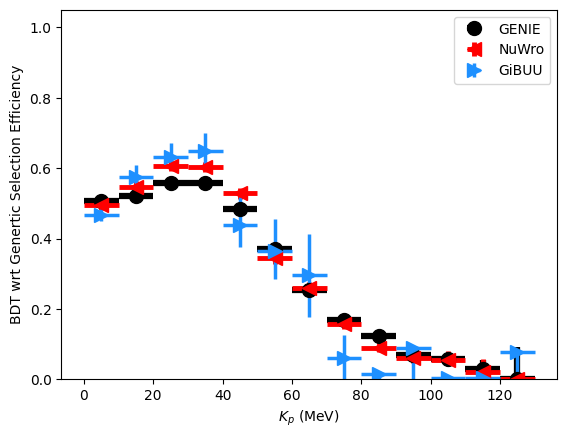

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:53<00:00,  5.59it/s]


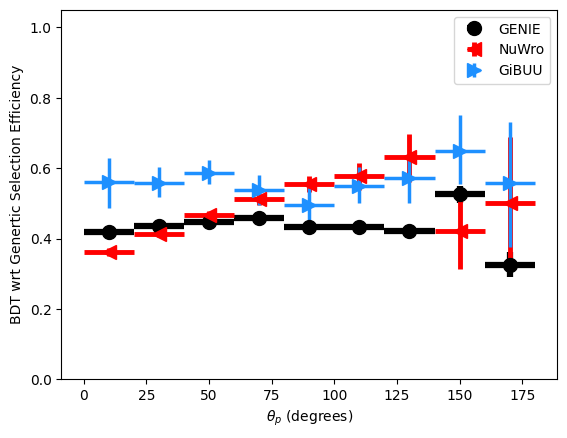

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:53<00:00,  5.65it/s]


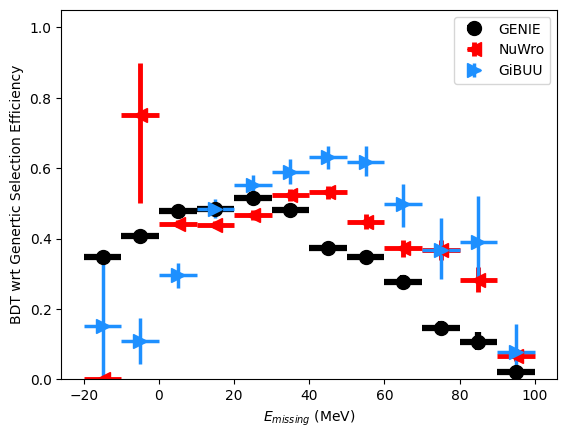

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:51<00:00,  5.81it/s]


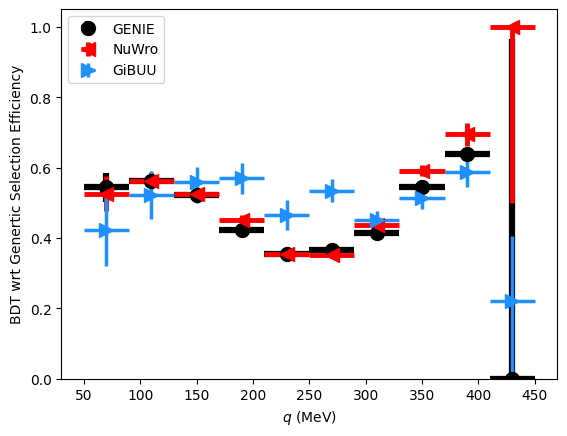

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:52<00:00,  5.75it/s]


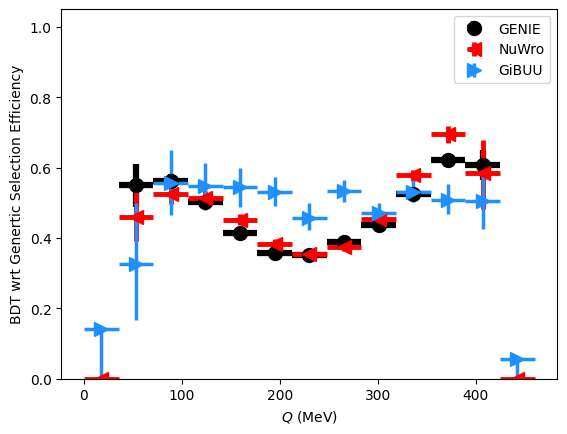

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:51<00:00,  5.79it/s]


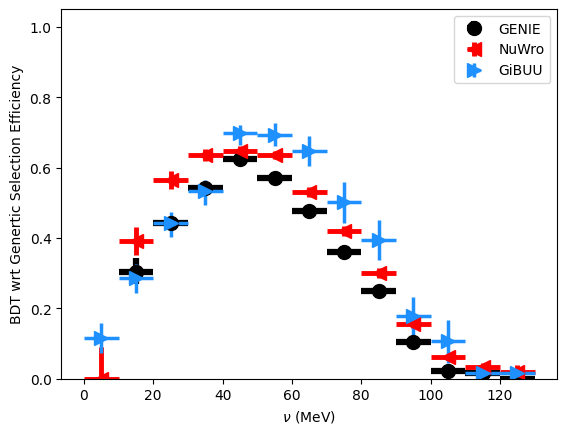

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:50<00:00,  5.99it/s]


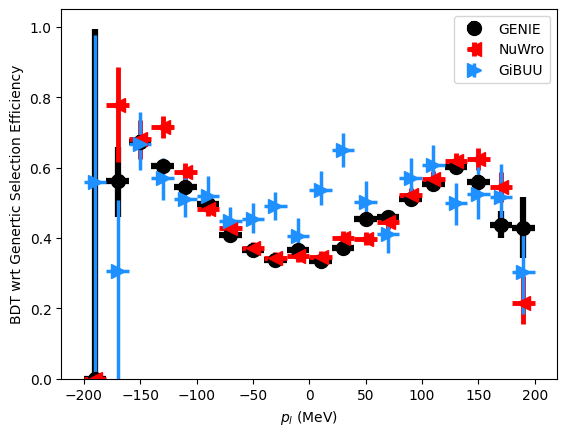

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:49<00:00,  6.04it/s]


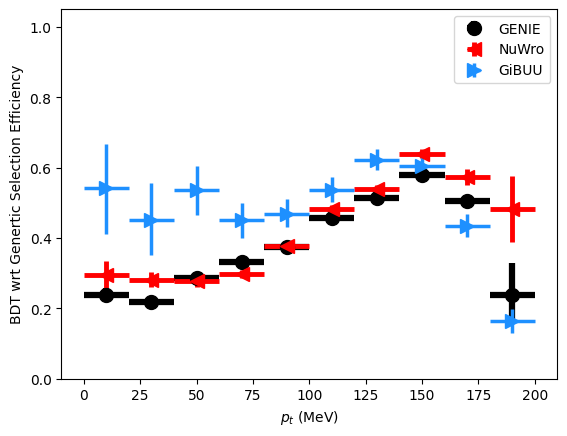

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:49<00:00,  6.03it/s]


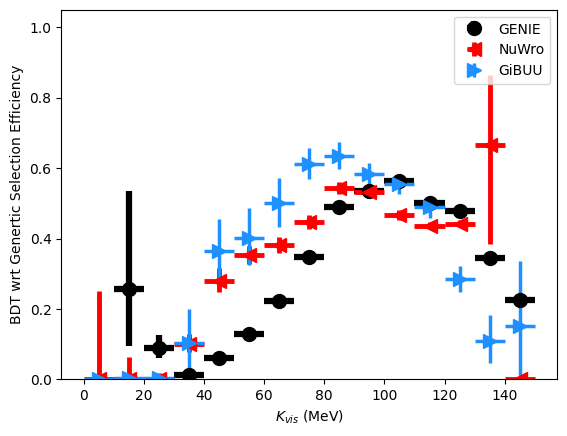

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:50<00:00,  5.97it/s]


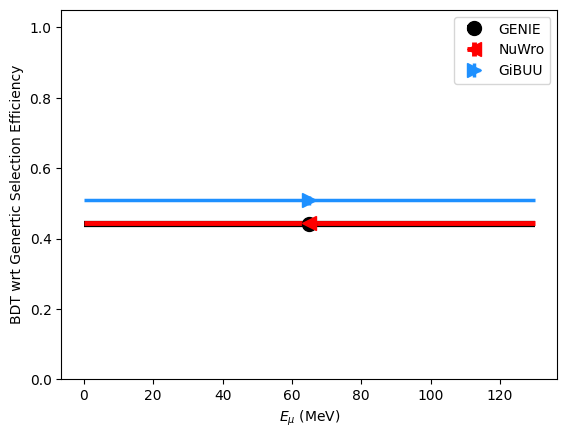

In [46]:
this_truth_vars = ["truth_Emuon","true_angle_deg","truth_prim_p_energy","true_angle_P_deg","true_Em","true_q","true_sqrtQ2","true_nu","true_pl","true_pt","true_KE","truth_Emuon"]
this_xlabels = [f"$E_\mu$ (MeV)","$\\theta_\mu$ (degrees)",f"$K_p$ (MeV)","$\\theta_p$ (degrees)","$E_{missing}$ (MeV)","$q$ (MeV)","$Q$ (MeV)","$\\nu$ (MeV)","$p_l$ (MeV)","$p_t$ (MeV)","$K_{vis}$ (MeV)",f"$E_\mu$ (MeV)"]

this_bins_list = []
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(0,180,10))
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(0,180,10))
this_bins_list.append(np.linspace(-20,100,13))
this_bins_list.append(np.linspace(50,450,11))
this_bins_list.append(np.linspace(0,460,14))
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(-200,200,21))
this_bins_list.append(np.linspace(0,200,11))
this_bins_list.append(np.linspace(0,150,16))
this_bins_list.append(np.linspace(0,130,2))

lowE_cut = 0.7
hiE_cut = 0.9
this_sig_query = "is_KDAR==1 and ssm_kine_reco_Enu>0"
this_sel_query = f"kdar_score_hiE>{hiE_cut} and kdar_score_lowE>{lowE_cut}"

plot_eff(this_truth_vars,this_sig_query,this_sel_query,this_bins_list,xlabels=this_xlabels,ylabel="BDT wrt Genertic Selection Efficiency")

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:51<00:00,  5.77it/s]


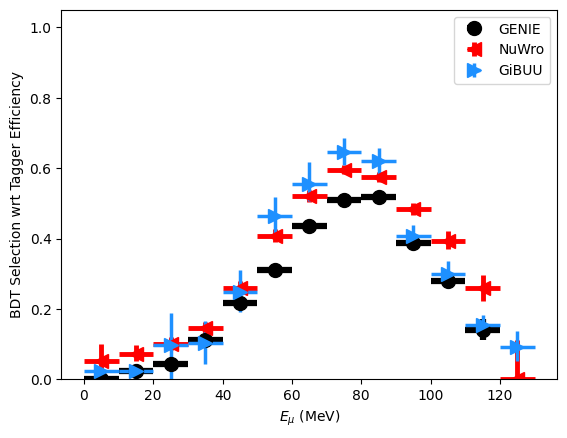

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:52<00:00,  5.77it/s]


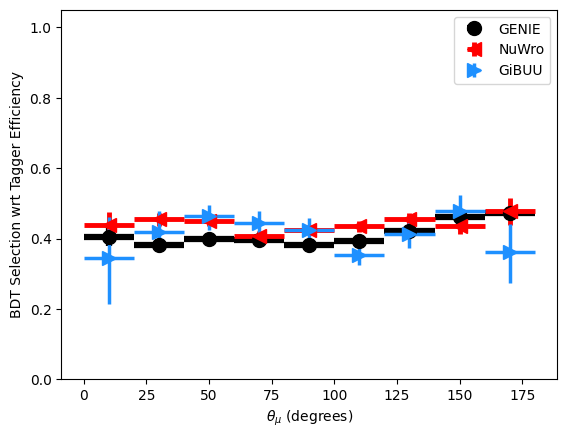

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:52<00:00,  5.70it/s]


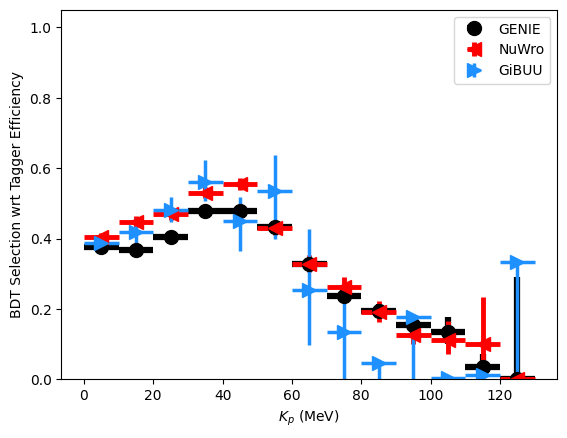

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:51<00:00,  5.83it/s]


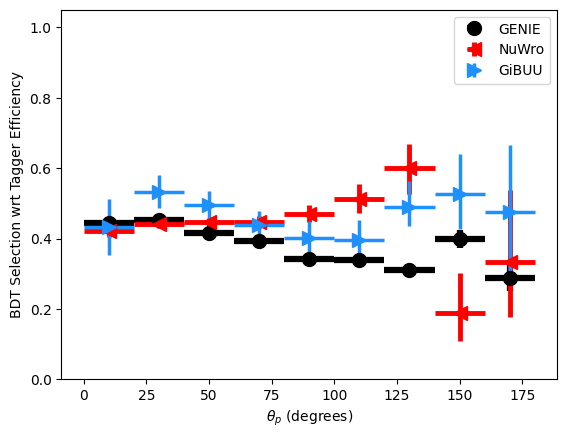

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:51<00:00,  5.83it/s]


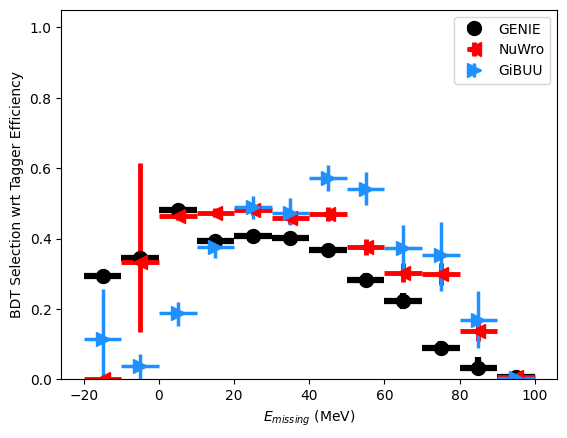

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:52<00:00,  5.74it/s]


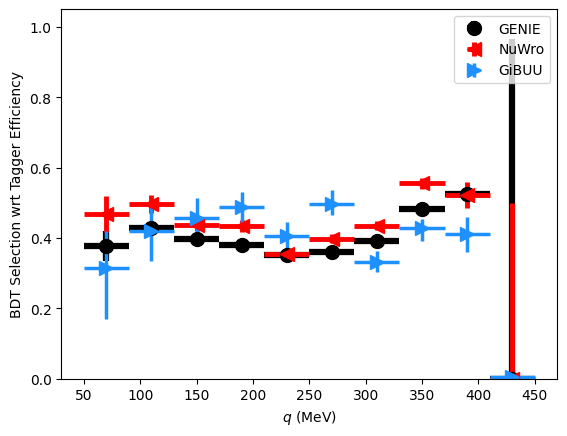

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:52<00:00,  5.74it/s]


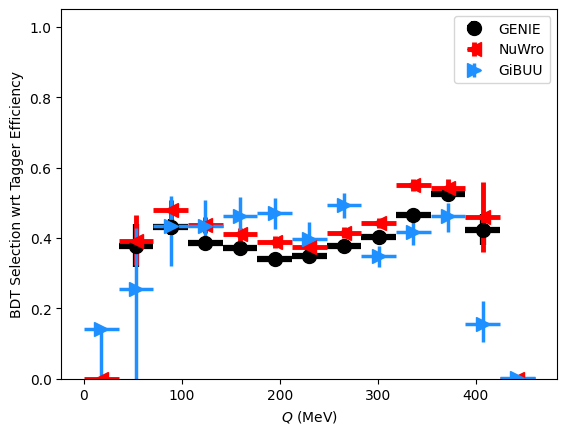

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:53<00:00,  5.63it/s]


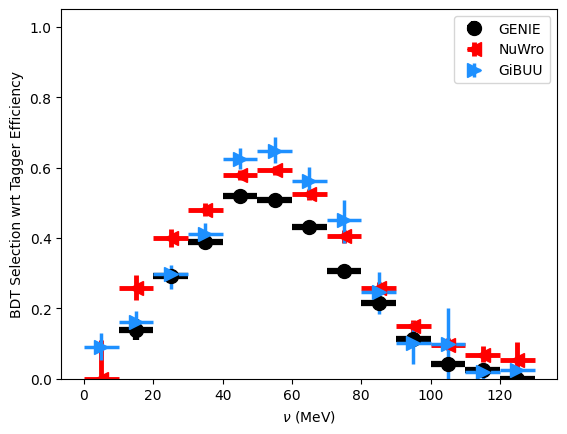

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:50<00:00,  5.94it/s]


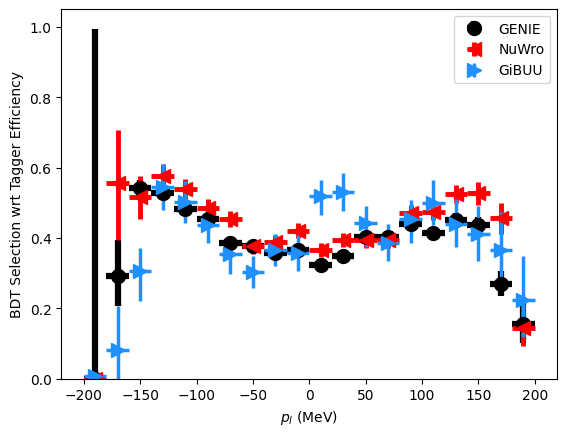

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:50<00:00,  5.93it/s]


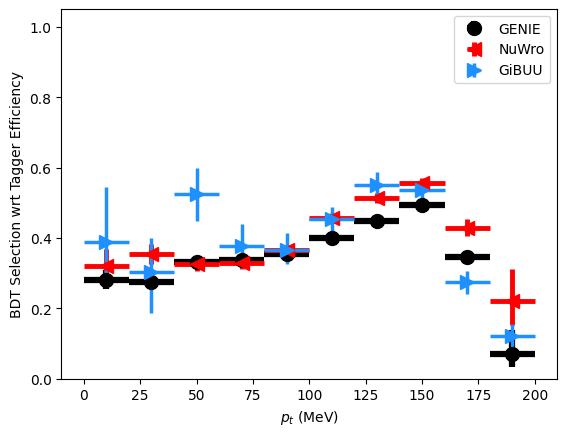

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:50<00:00,  5.95it/s]


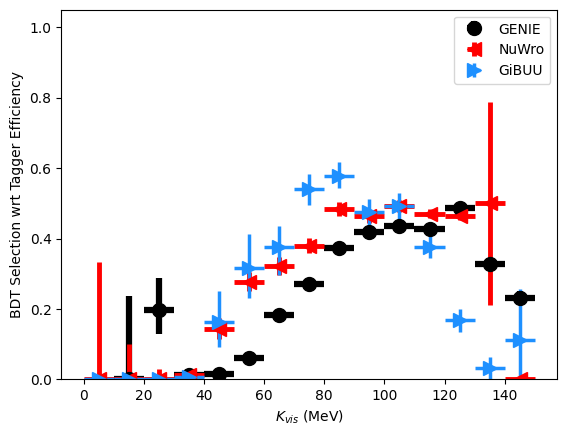

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:50<00:00,  5.90it/s]


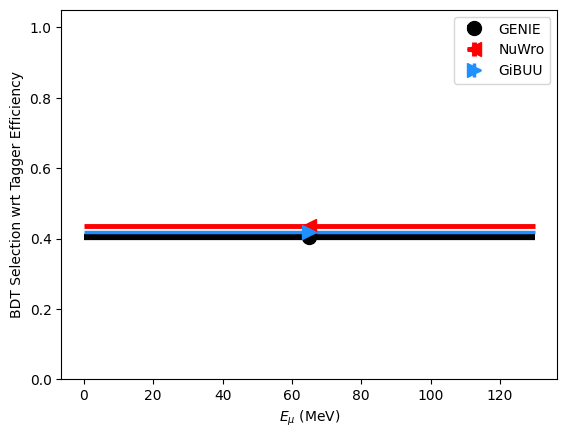

In [47]:
this_truth_vars = ["truth_Emuon","true_angle_deg","truth_prim_p_energy","true_angle_P_deg","true_Em","true_q","true_sqrtQ2","true_nu","true_pl","true_pt","true_KE","truth_Emuon"]
this_xlabels = [f"$E_\mu$ (MeV)","$\\theta_\mu$ (degrees)",f"$K_p$ (MeV)","$\\theta_p$ (degrees)","$E_{missing}$ (MeV)","$q$ (MeV)","$Q$ (MeV)","$\\nu$ (MeV)","$p_l$ (MeV)","$p_t$ (MeV)","$K_{vis}$ (MeV)",f"$E_\mu$ (MeV)"]

this_bins_list = []
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(0,180,10))
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(0,180,10))
this_bins_list.append(np.linspace(-20,100,13))
this_bins_list.append(np.linspace(50,450,11))
this_bins_list.append(np.linspace(0,460,14))
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(-200,200,21))
this_bins_list.append(np.linspace(0,200,11))
this_bins_list.append(np.linspace(0,150,16))
this_bins_list.append(np.linspace(0,130,2))

lowE_cut = 0.8
hiE_cut = 0.9
this_sig_query = "is_KDAR==1 and ssm_kine_energy>0 and ssm_kine_reco_Enu>0"
this_sel_query = f"kdar_score_hiE>{hiE_cut} and kdar_score_lowE>{lowE_cut}"

plot_eff(this_truth_vars,this_sig_query,this_sel_query,this_bins_list,xlabels=this_xlabels,ylabel="BDT Selection wrt Tagger Efficiency")

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:50<00:00,  5.95it/s]


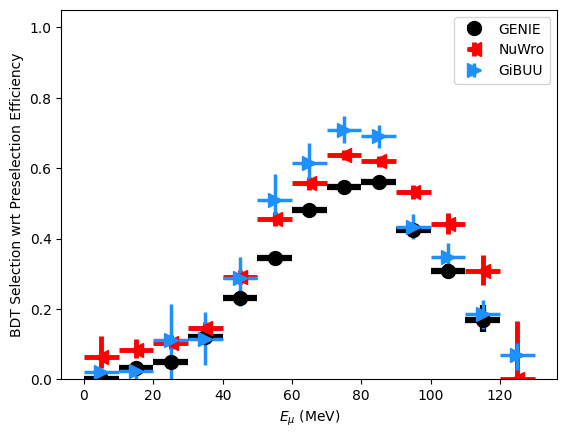

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:50<00:00,  5.94it/s]


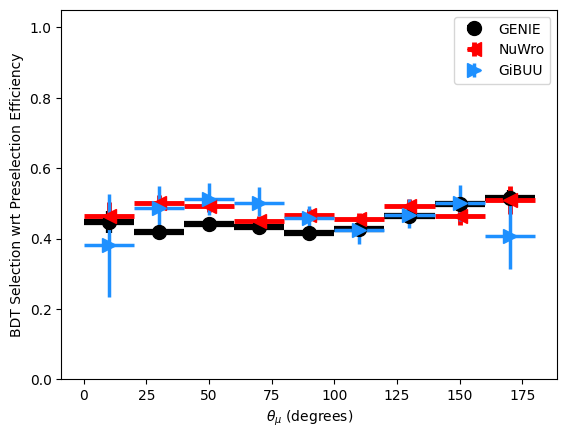

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:50<00:00,  5.96it/s]


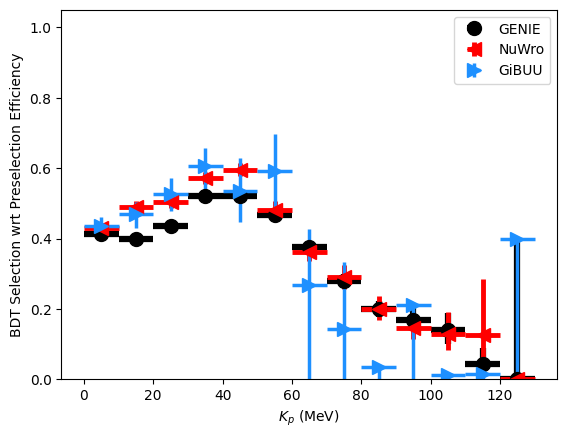

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:50<00:00,  5.99it/s]


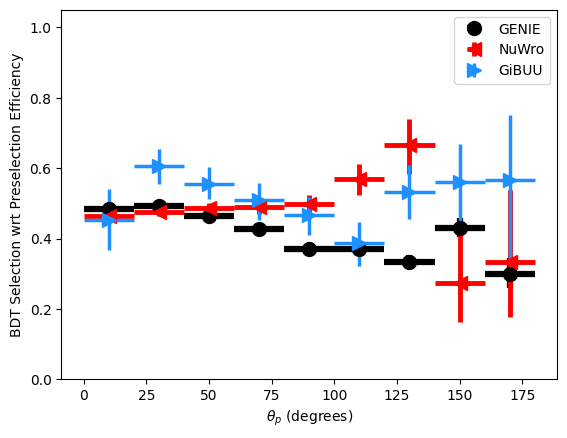

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:50<00:00,  5.95it/s]


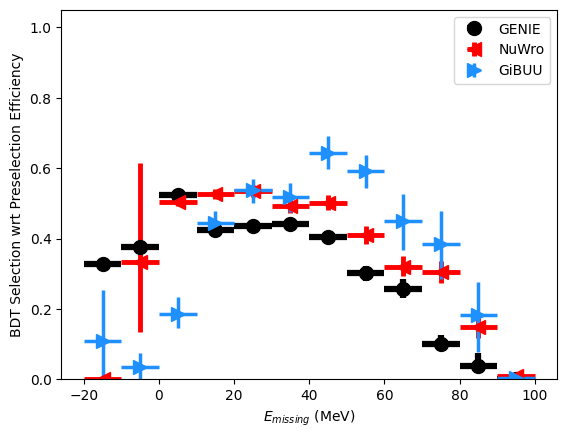

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:50<00:00,  5.89it/s]


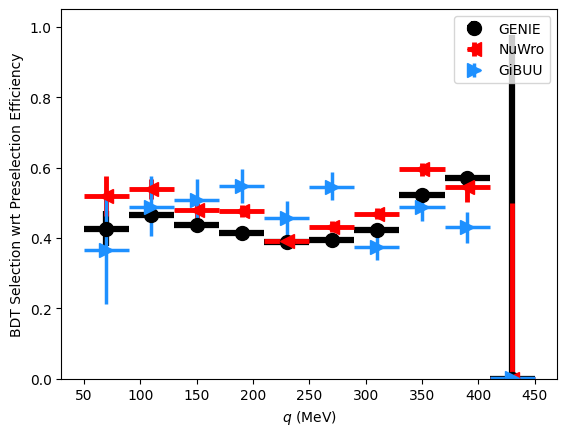

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:51<00:00,  5.84it/s]


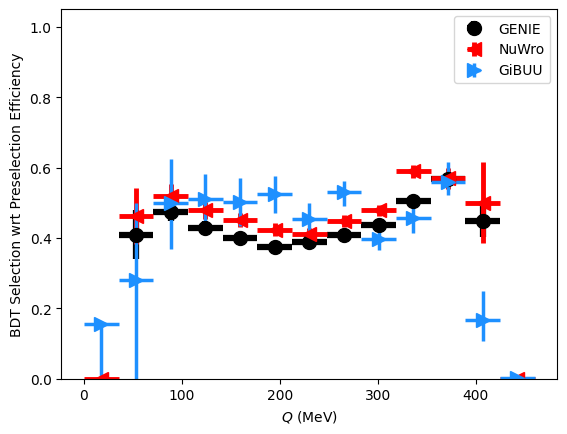

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:50<00:00,  5.95it/s]


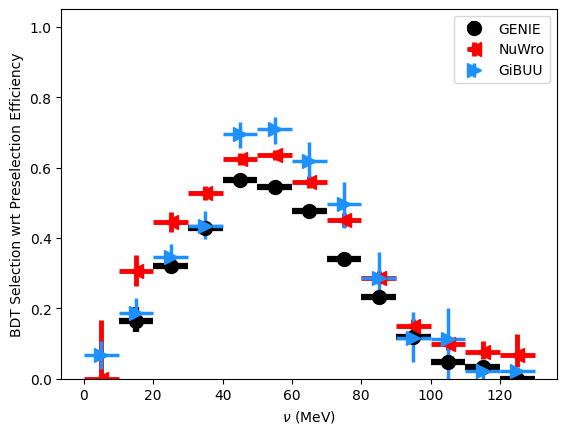

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:50<00:00,  5.99it/s]


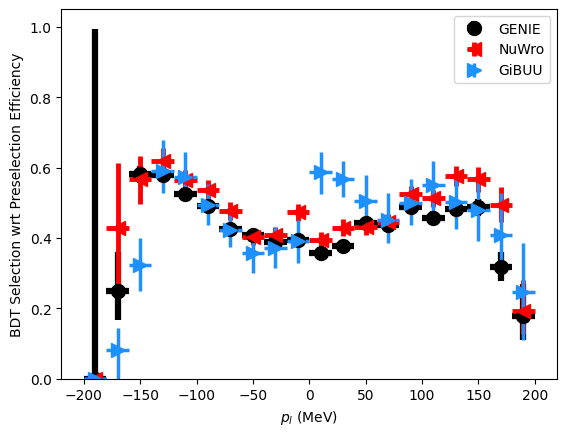

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:50<00:00,  5.94it/s]


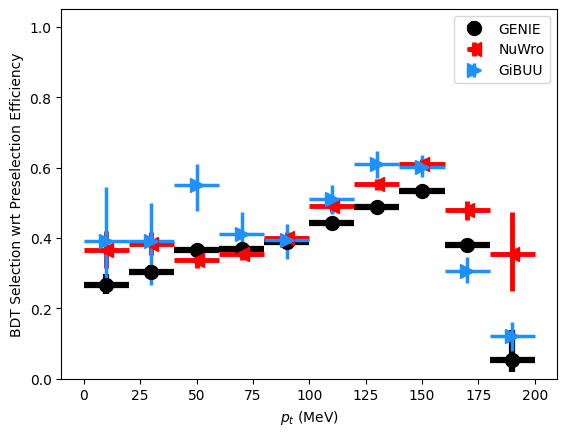

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:50<00:00,  5.99it/s]


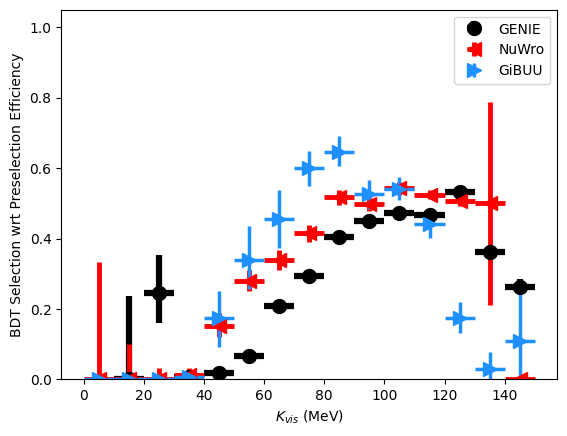

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:50<00:00,  5.90it/s]


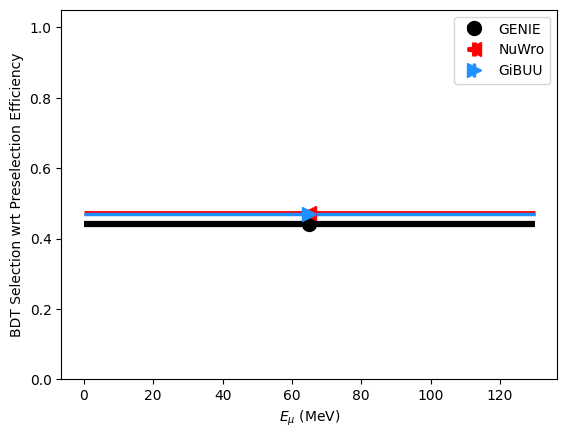

In [48]:
this_truth_vars = ["truth_Emuon","true_angle_deg","truth_prim_p_energy","true_angle_P_deg","true_Em","true_q","true_sqrtQ2","true_nu","true_pl","true_pt","true_KE","truth_Emuon"]
this_xlabels = [f"$E_\mu$ (MeV)","$\\theta_\mu$ (degrees)",f"$K_p$ (MeV)","$\\theta_p$ (degrees)","$E_{missing}$ (MeV)","$q$ (MeV)","$Q$ (MeV)","$\\nu$ (MeV)","$p_l$ (MeV)","$p_t$ (MeV)","$K_{vis}$ (MeV)",f"$E_\mu$ (MeV)"]

this_bins_list = []
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(0,180,10))
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(0,180,10))
this_bins_list.append(np.linspace(-20,100,13))
this_bins_list.append(np.linspace(50,450,11))
this_bins_list.append(np.linspace(0,460,14))
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(-200,200,21))
this_bins_list.append(np.linspace(0,200,11))
this_bins_list.append(np.linspace(0,150,16))
this_bins_list.append(np.linspace(0,130,2))

lowE_cut = 0.8
hiE_cut = 0.9
this_sig_query = "is_KDAR==1 and " + kdar.presel_query
this_sel_query = f"kdar_score_hiE>{hiE_cut} and kdar_score_lowE>{lowE_cut}"

plot_eff(this_truth_vars,this_sig_query,this_sel_query,this_bins_list,xlabels=this_xlabels,ylabel="BDT Selection wrt Preselection Efficiency")

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:50<00:00,  5.98it/s]


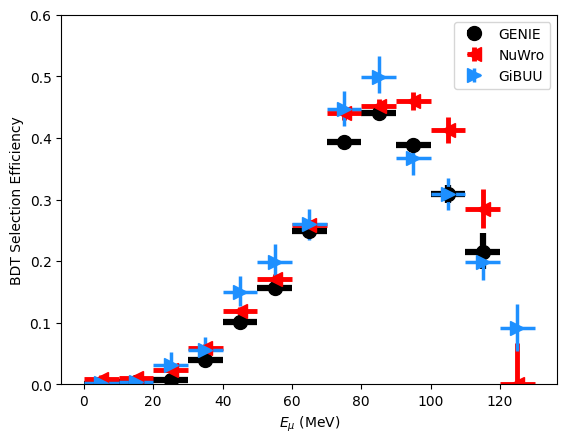

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:51<00:00,  5.85it/s]


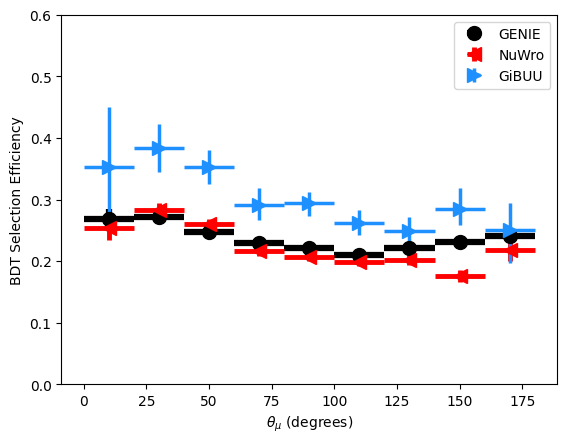

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:49<00:00,  6.03it/s]


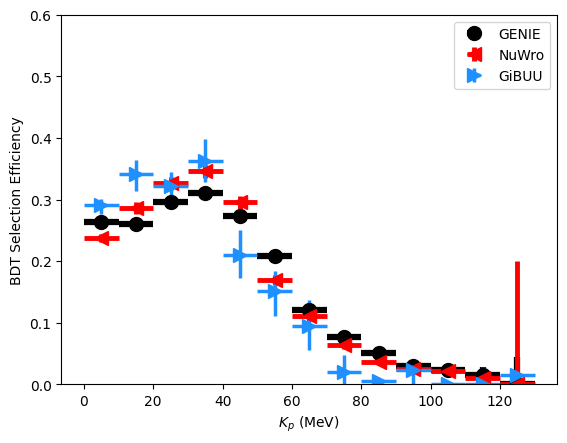

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:48<00:00,  6.12it/s]


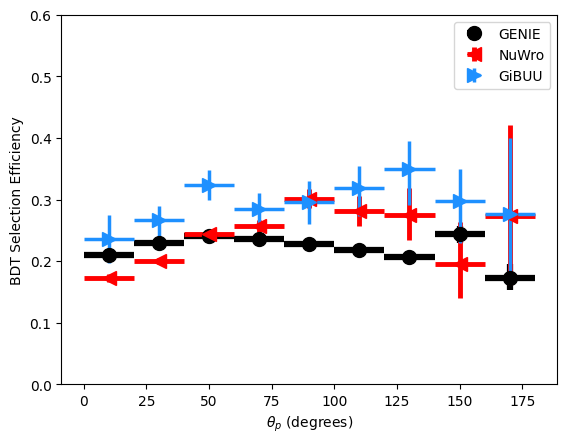

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:52<00:00,  5.71it/s]


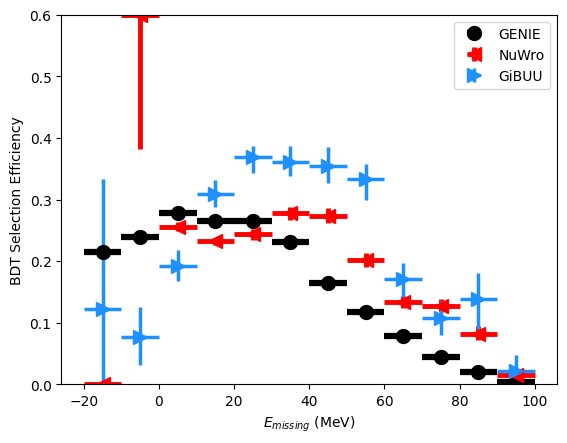

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:53<00:00,  5.56it/s]


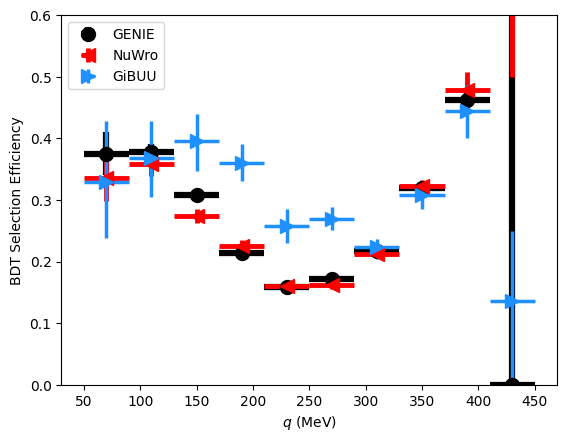

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:50<00:00,  5.91it/s]


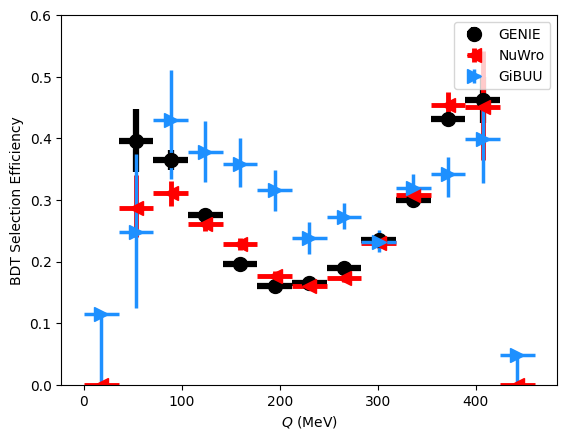

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:50<00:00,  5.93it/s]


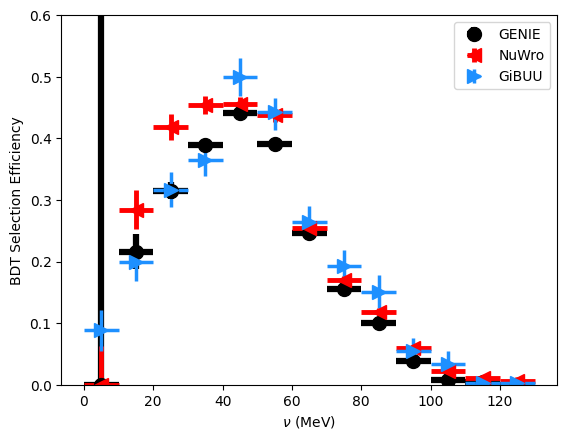

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:50<00:00,  5.97it/s]


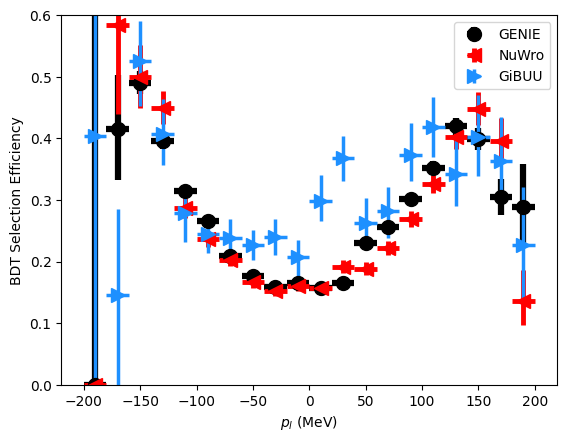

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:50<00:00,  5.89it/s]


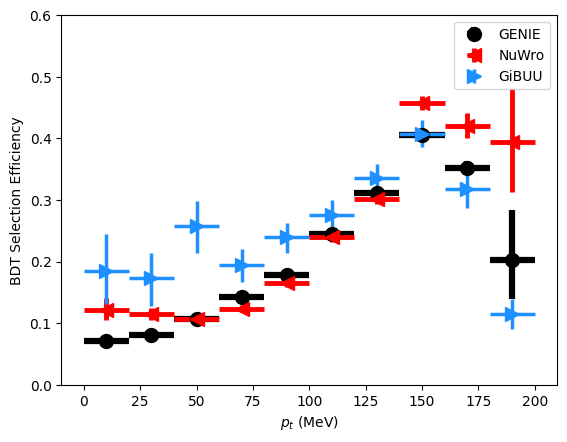

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:50<00:00,  5.91it/s]


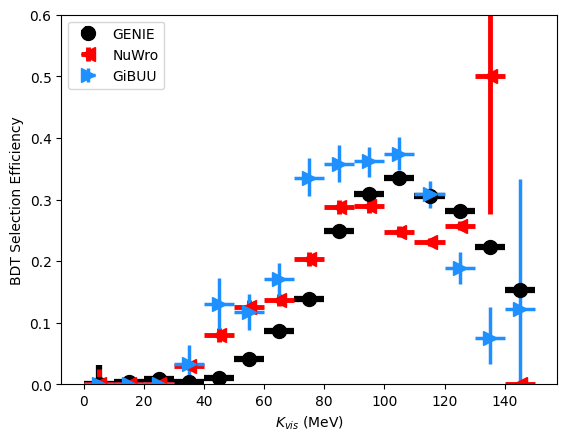

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:50<00:00,  5.88it/s]


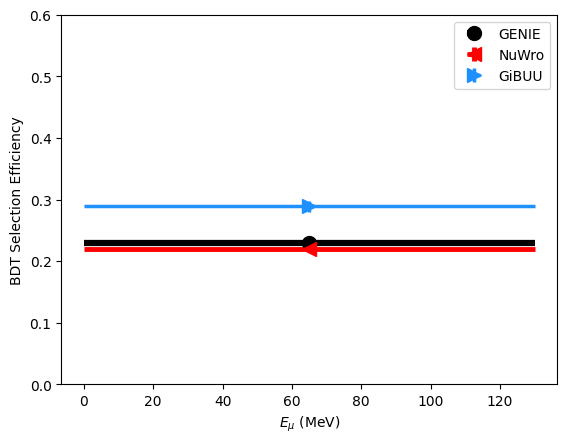

In [51]:
this_truth_vars = ["truth_Emuon","true_angle_deg","truth_prim_p_energy","true_angle_P_deg","true_Em","true_q","true_sqrtQ2","true_nu","true_pl","true_pt","true_KE","truth_Emuon"]
this_xlabels = [f"$E_\mu$ (MeV)","$\\theta_\mu$ (degrees)",f"$K_p$ (MeV)","$\\theta_p$ (degrees)","$E_{missing}$ (MeV)","$q$ (MeV)","$Q$ (MeV)","$\\nu$ (MeV)","$p_l$ (MeV)","$p_t$ (MeV)","$K_{vis}$ (MeV)",f"$E_\mu$ (MeV)"]

this_bins_list = []
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(0,180,10))
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(0,180,10))
this_bins_list.append(np.linspace(-20,100,13))
this_bins_list.append(np.linspace(50,450,11))
this_bins_list.append(np.linspace(0,460,14))
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(-200,200,21))
this_bins_list.append(np.linspace(0,200,11))
this_bins_list.append(np.linspace(0,150,16))
this_bins_list.append(np.linspace(0,130,2))

lowE_cut = 0.7
hiE_cut = 0.9
this_sig_query = "is_KDAR==1"
this_sel_query = f"kdar_score_hiE>{hiE_cut} and kdar_score_lowE>{lowE_cut}"

plot_eff(this_truth_vars,this_sig_query,this_sel_query,this_bins_list,xlabels=this_xlabels,ylabel="BDT Selection Efficiency",adjusty=0.6)

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:51<00:00,  5.79it/s]


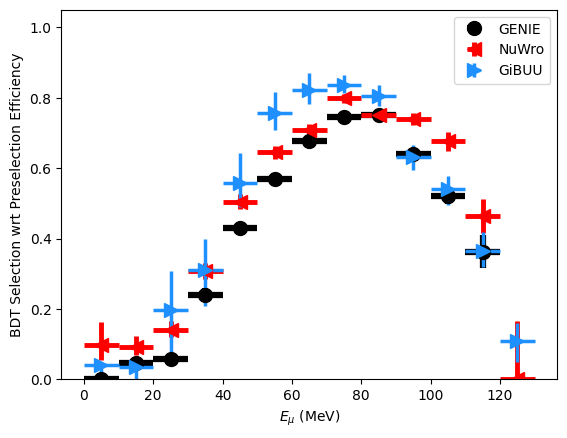

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:51<00:00,  5.88it/s]


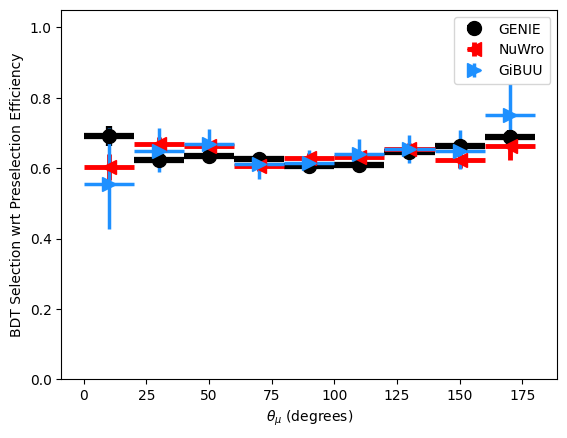

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:51<00:00,  5.79it/s]


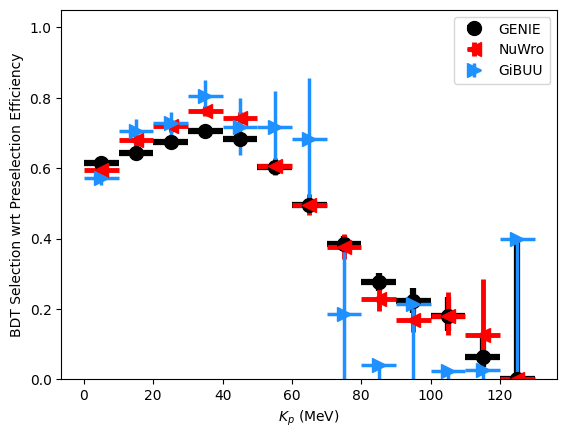

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:52<00:00,  5.73it/s]


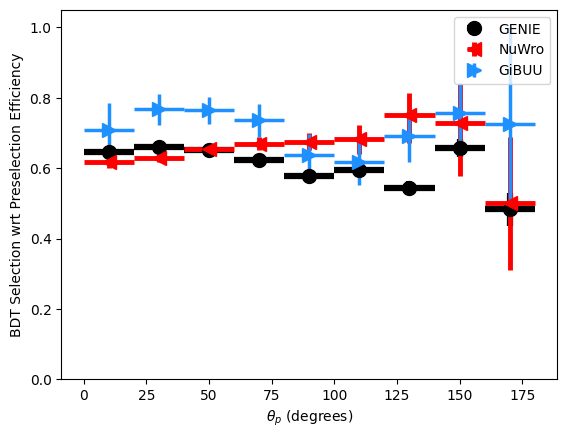

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:51<00:00,  5.79it/s]


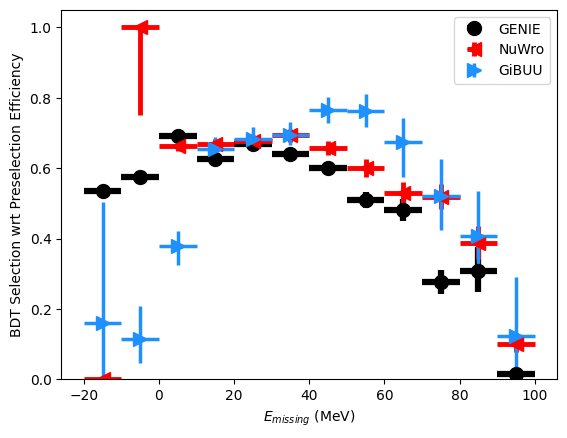

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:49<00:00,  6.10it/s]


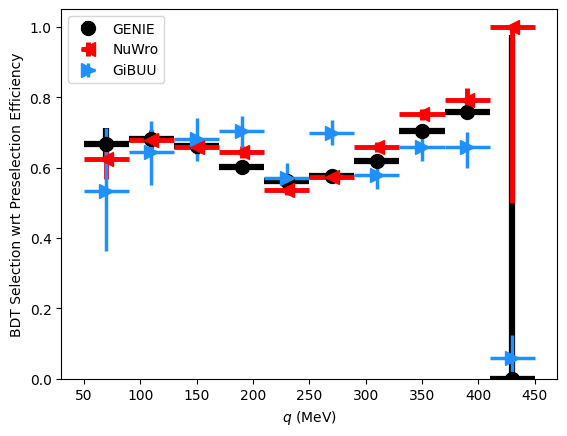

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:49<00:00,  6.12it/s]


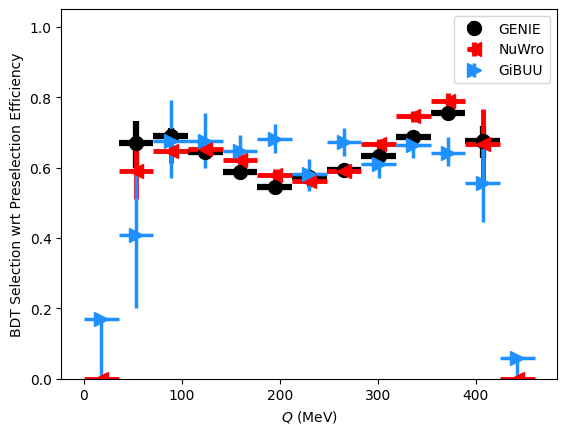

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:49<00:00,  6.05it/s]


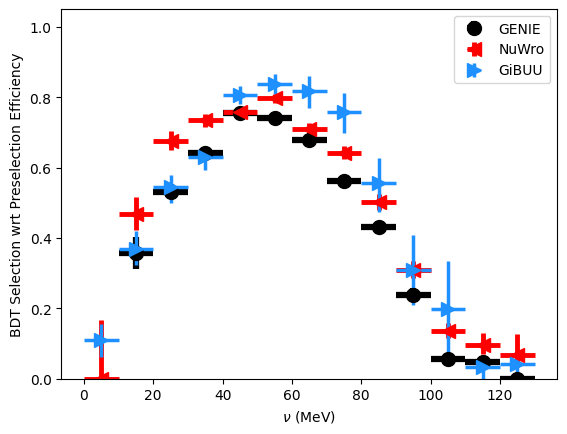

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:50<00:00,  5.92it/s]


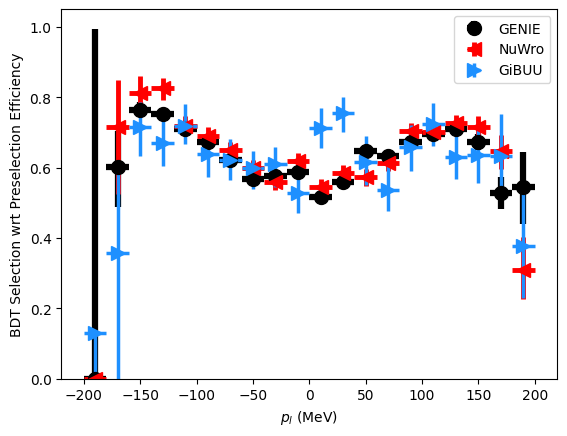

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:49<00:00,  6.02it/s]


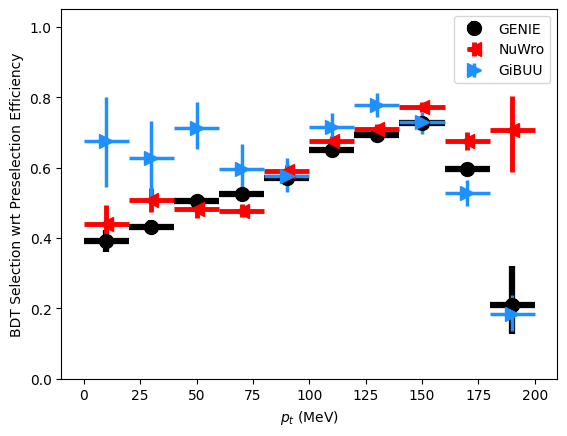

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:49<00:00,  6.02it/s]


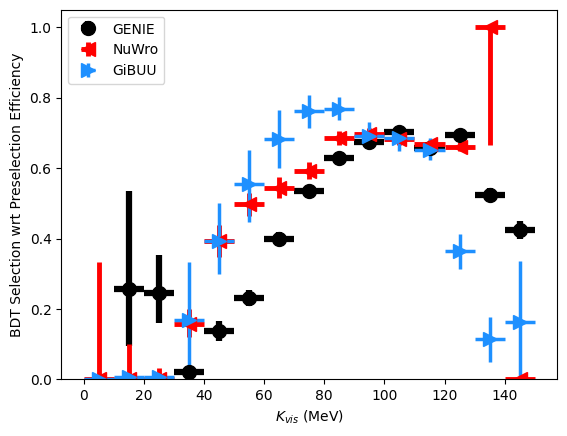

Starting Bootstrap


100%|█████████████████████████████████████████| 300/300 [00:50<00:00,  5.99it/s]


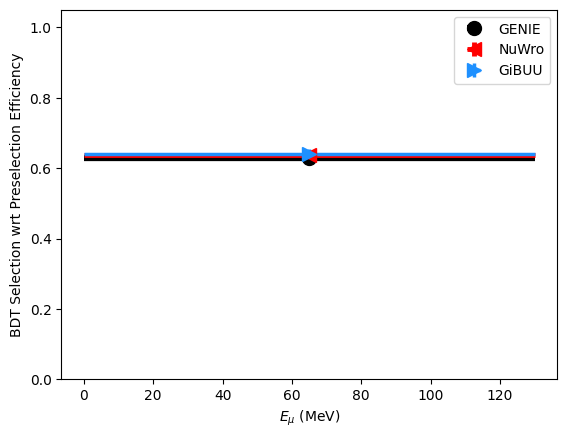

In [52]:
this_truth_vars = ["truth_Emuon","true_angle_deg","truth_prim_p_energy","true_angle_P_deg","true_Em","true_q","true_sqrtQ2","true_nu","true_pl","true_pt","true_KE","truth_Emuon"]
this_xlabels = [f"$E_\mu$ (MeV)","$\\theta_\mu$ (degrees)",f"$K_p$ (MeV)","$\\theta_p$ (degrees)","$E_{missing}$ (MeV)","$q$ (MeV)","$Q$ (MeV)","$\\nu$ (MeV)","$p_l$ (MeV)","$p_t$ (MeV)","$K_{vis}$ (MeV)",f"$E_\mu$ (MeV)"]

this_bins_list = []
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(0,180,10))
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(0,180,10))
this_bins_list.append(np.linspace(-20,100,13))
this_bins_list.append(np.linspace(50,450,11))
this_bins_list.append(np.linspace(0,460,14))
this_bins_list.append(np.linspace(0,130,14))
this_bins_list.append(np.linspace(-200,200,21))
this_bins_list.append(np.linspace(0,200,11))
this_bins_list.append(np.linspace(0,150,16))
this_bins_list.append(np.linspace(0,130,2))

lowE_cut = 0.7
hiE_cut = 0.9
this_sig_query = "is_KDAR==1 and " + kdar.presel_query
this_sel_query = f"kdar_score_hiE>{hiE_cut} and kdar_score_lowE>{lowE_cut}"

plot_eff(this_truth_vars,this_sig_query,this_sel_query,this_bins_list,xlabels=this_xlabels,ylabel="BDT Selection wrt Preselection Efficiency")